<a href="https://colab.research.google.com/github/AndresMontesDeOca/Deep_Learning/blob/main/MONTESDEOCA-ANDRES-DL-TP2-Co24_REDUCED.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Universidad de Buenos Aires
# Aprendizaje Profundo - TP2
# Cohorte 24 - 2do bimestre 2026

El segundo TP comienza la semana de la clase 4 y la ventana de entrega estará abierta hasta las **23:59 hs del viernes 5 de junio (hora de Argentina)**. La resolución del TP es **individual**. Pueden utilizar tanto los contenidos vistos en clase, como otra bibliografía externa. Si se toman ideas de fuentes externas deben ser correctamente citadas incluyendo el correspondiente link o página de libro.

ESTE TP2 EQUIVALE A UN TERCIO DE SU NOTA FINAL.

El formato de entrega debe ser un link a un notebook de google colab. Importante permitir acceso a gvilcamiza.ext@fi.uba.ar y **habilitar los comentarios, para poder darles el feedback**. Si no lo hacen así no se podrá dar el feedback respectivo por cada pregunta.

El envío **se realizará en el siguiente link de google forms: [link](https://forms.gle/6yGAsYUywfSshnik9)**. Tanto los resultados, gráficas, como el código y las explicaciones deben quedar guardados y visualizables en el colab.

**NO SE VALIDARÁN ENVÍOS POR CORREO, EL MÉTODO DE ENTREGA ES SOLO POR EL FORMS.**

**Consideraciones a tener en cuenta:**
- Se entregará 1 solo colab para este TP2.
- Renombrar el archivo de la siguiente manera: **APELLIDO-NOMBRE-DL-TP2-Co24.ipynb**
- Los códigos deben poder ejecutarse.
- **IMPORTANTE:** Los resultados, cómo el código, los gráficos, los prints y las explicaciones deben quedar guardados y visualizables en el mismo notebook.
- **Prestar mucha atención a cada consigna, responder las preguntas justo debajo del enunciado que corresponda.**
- Solo se revisarán los trabajos que hayan sido enviados por el forms.

# CASO: Adult Census Income

El objetivo del trabajo es construir un modelo de clasificación binaria que, a partir de los datos censales de diferentes hogares, determine si un individuo pertenece al grupo de mayores o de menores ingresos. Para ello, se empleará un conjunto de variables demográficas, laborales y socioeconómicas que describen las características de cada persona. El estudio debe incluir el análisis exploratorio del dataset, la selección y justificación de las transformaciones más adecuadas para cada variable, la construcción de modelos basados tanto en técnicas de codificación tradicionales como también en representaciones avanzadas mediante embeddings, y la comparación final del desempeño obtenido por cada enfoque.

**Para este caso de estudio, consideraremos como variable de alta cardinalidad a las que tengan 10 o más valores únicos.**


**Encontrarán el dataset en el siguiente enlace de drive: [link](https://drive.google.com/drive/folders/1S-usUXkJP6OdzUS0zdC5CW-XqegiXzln?usp=sharing)**

Está compuesto por los siguientes features:
- **age**: Edad del individuo expresada en años.

- **workclass**: Tipo de empleador o relación laboral del individuo. Describe si trabaja en el sector privado, gobierno estatal, local, federal, por cuenta propia, sin remuneración, etc.

- **education**: Nivel educativo alcanzado. Incluye categorías como secundaria completada, licenciatura, maestría, doctorado, etc.

- **marital-status**: Estado civil (casado, nunca casado, divorciado, viudo, etc.).

- **occupation**: Tipo de ocupación o área laboral, donde se incluye ventas, servicios de protección, técnicos, gerencia ejecutiva, fuerzas armadas, etc.

- **relationship**: Relación del individuo con el jefe del hogar como esposo, esposa, hijo propio, pariente, no familiar, etc.

- **race**: Autoidentificación racial como blanca, negra, indígena, asiática, isleños del Pacífico, entre otras.

- **sex**: Sexo biológico del individuo (masculino o femenino).

- **capital-gain**: Ingresos obtenidos por ganancia de capital (por ejemplo, venta de acciones o propiedades).

- **capital-loss**: Pérdidas declaradas por capital.

- **hours-per-week**: Cantidad de horas trabajadas por semana.

- **skill-profile**: Habilidad principal o conocmiento técnico adquirido que podría aplicar en el trabajo.

- **native-country**: País de nacimiento del individuo. Incluye Estados Unidos y una lista amplia de países del mundo.

- **income (target)**: Clasificación binaria que indica si el ingreso anual del individuo es menor o igual a 50K o mayor a 50K.

## Data Load

In [ ]:
# Librerias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import gdown
import copy

from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, OrdinalEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, f1_score
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', 1000)

custom_palette = {'<=50K': '#ff9999', '>50K': '#add8e6'}

In [ ]:
# Enlace a la carpeta de Google Drive
folder_url = 'https://drive.google.com/drive/folders/1S-usUXkJP6OdzUS0zdC5CW-XqegiXzln'

# Descargar la carpeta completa en un directorio específico llamado 'dataset'
print("Descargando archivos desde Google Drive...")
gdown.download_folder(folder_url, output='dataset', quiet=True, use_cookies=False)

# Cargar los archivos directamente en las variables train y test
train = pd.read_csv('dataset/adult_train.csv')
test = pd.read_csv('dataset/adult_val.csv')

# Lista de Series transofrmadas, listas para entrenar
variables_transformadas_train = []
variables_transformadas_test  = []

Descargando archivos desde Google Drive...


## a) Análisis exploratorio de los datasets (2 puntos)

- Realizar un EDA apoyado en gráficas adecuadas y coherentes para el caso de estudio.
- Analizar detalladamente los valores únicos de cada variable categórica e identificar su nivel de cardinalidad.
- Justificar de manera detallada el tipo de transformación que se le asignará a cada variable, en especial a las categóricas. **Dependiendo de su cardinalidad, su contexto y/o lógica interna de orden**, podrán transformarse mediante label/ordinal encoding, one-hot encoding o mediante una capa de embeddings dentro del modelo.
- No es necesario aplicar la misma transformación para todas las variables categóricas. El dataset puede (y debe) incluir diferentes tipos de transformaciones según las características de cada variable.
- Redactar explícitamente la decisión final adoptada para cada variable y su justificación correspondiente.

In [ ]:
# Train

print(train.info())
display(train.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30162 entries, 0 to 30161
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             30162 non-null  int64 
 1   workclass       30162 non-null  object
 2   education       30162 non-null  object
 3   marital-status  30162 non-null  object
 4   occupation      30162 non-null  object
 5   relationship    30162 non-null  object
 6   race            30162 non-null  object
 7   sex             30162 non-null  object
 8   capital-gain    30162 non-null  int64 
 9   capital-loss    30162 non-null  int64 
 10  hours-per-week  30162 non-null  int64 
 11  skill-profile   30162 non-null  object
 12  native-country  30162 non-null  object
 13  income          30162 non-null  object
dtypes: int64(4), object(10)
memory usage: 3.2+ MB
None


,age,workclass,education,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,skill-profile,native-country,income
0,39,State-gov,Bachelors,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,manufacturing_assembly,United-States,<=50K
1,50,Self-emp-not-inc,Bachelors,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,accounting_bookkeeping,United-States,<=50K
2,38,Private,HS-grad,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,agriculture_field_work,United-States,<=50K
3,53,Private,11th,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,office_data_entry_basic,United-States,<=50K
4,28,Private,Bachelors,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,tech_programming_advanced,Cuba,<=50K


In [ ]:
# Test

print(test.info())
display(test.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15060 entries, 0 to 15059
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             15060 non-null  int64 
 1   workclass       15060 non-null  object
 2   education       15060 non-null  object
 3   marital-status  15060 non-null  object
 4   occupation      15060 non-null  object
 5   relationship    15060 non-null  object
 6   race            15060 non-null  object
 7   sex             15060 non-null  object
 8   capital-gain    15060 non-null  int64 
 9   capital-loss    15060 non-null  int64 
 10  hours-per-week  15060 non-null  int64 
 11  skill-profile   15060 non-null  object
 12  native-country  15060 non-null  object
 13  income          15060 non-null  object
dtypes: int64(4), object(10)
memory usage: 1.6+ MB
None


,age,workclass,education,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,skill-profile,native-country,income
0,25,Private,11th,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,logistics_warehouse_basic,United-States,<=50K
1,38,Private,HS-grad,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,security_patrol_basic,United-States,<=50K
2,28,Local-gov,Assoc-acdm,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,trade_cnc_operation,United-States,>50K
3,44,Private,Some-college,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,transport_commercial_driving,United-States,>50K
4,34,Private,10th,Never-married,Other-service,Not-in-family,White,Male,0,0,30,personal_care_assistance,United-States,<=50K


- 30K registros en Train y 15K resitros en Test
- No hay nulos

### Income (Target)
Clasificación binaria que indica si el ingreso anual del individuo es menor o igual a 50K o mayor a 50K.

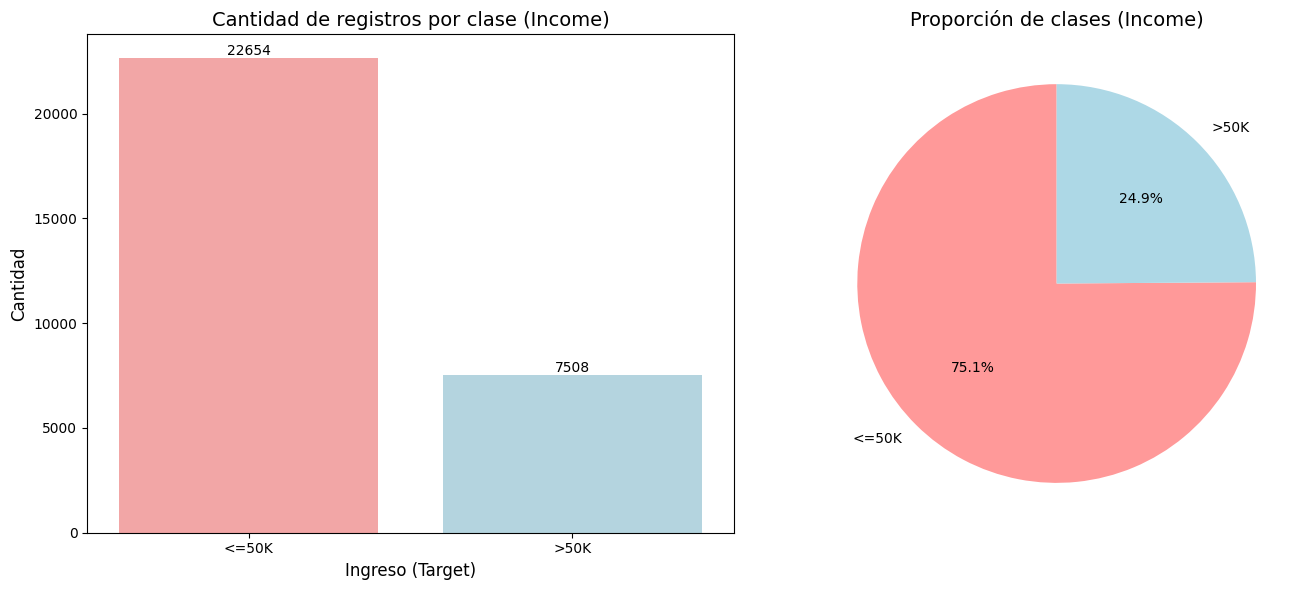

In [ ]:
# Configurar la figura con dos subgráficos
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Gráfico de barras (Countplot)
# Se agrega hue='income' y legend=False para evitar el FutureWarning de Seaborn
sns.countplot(data=train, x='income', ax=axes[0], hue='income', palette=custom_palette, legend=False)
axes[0].set_title('Cantidad de registros por clase (Income)', fontsize=14)
axes[0].set_xlabel('Ingreso (Target)', fontsize=12)
axes[0].set_ylabel('Cantidad', fontsize=12)

# Agregar los valores exactos sobre las barras
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center', xytext=(0, 5), textcoords='offset points')

# 2. Gráfico de torta (Pie chart)
income_counts = train['income'].value_counts()
# Mapeamos los colores desde custom_palette respetando el orden del índice
pie_colors = [custom_palette[val] for val in income_counts.index]
axes[1].pie(income_counts, labels=income_counts.index, autopct='%1.1f%%', startangle=90, colors=pie_colors)
axes[1].set_title('Proporción de clases (Income)', fontsize=14)

plt.tight_layout()
plt.show()

- Defino la Clase Positiva como >50K
- Un poco desbalanceada 25%

In [ ]:
# 1. Transformación Variable Target (Income) -> BOOL_Income

target_mapping = {'<=50K': 0, '>50K': 1}

BOOL_Income_train = train['income'].map(target_mapping).astype(int)
BOOL_Income_test = test['income'].map(target_mapping).astype(int)

# Asignamos el nombre a la serie para consistencia
BOOL_Income_train.name = 'BOOL_Income'
BOOL_Income_test.name = 'BOOL_Income'


- Transformo el Target a INT 0/1 para el entrenamiento del modelo
- BOOL_Income

### Age
Edad del individuo expresada en años.

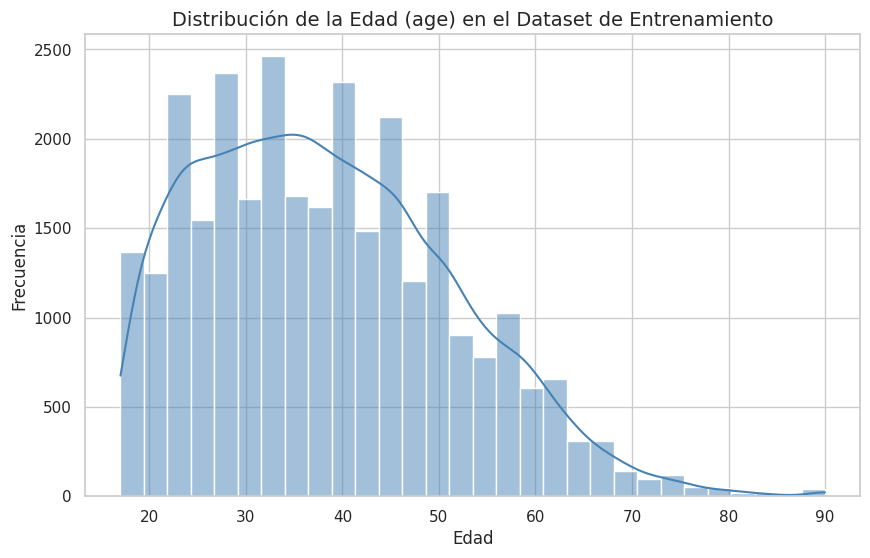


Estadísticas descriptivas de la variable 'age':


,age
count,30162.000000
mean,38.437902
std,13.134665
min,17.000000
25%,28.000000
50%,37.000000
75%,47.000000
max,90.000000


In [ ]:
# Configurar el estilo de los gráficos
sns.set_theme(style="whitegrid")

# Crear el histograma para la variable 'age'
plt.figure(figsize=(10, 6))
sns.histplot(data=train, x='age', bins=30, kde=True, color='steelblue')
plt.title('Distribución de la Edad (age) en el Dataset de Entrenamiento', fontsize=14)
plt.xlabel('Edad', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.show()

# Mostrar estadísticas descriptivas de la variable 'age'
print("\nEstadísticas descriptivas de la variable 'age':")
display(train['age'].describe())

- Distribucion bastante simetrica centrada en 38/37 años (media/mediana)
- Arranca en 17 y termina en 90. Talvez se pueda capear los valores maximos?

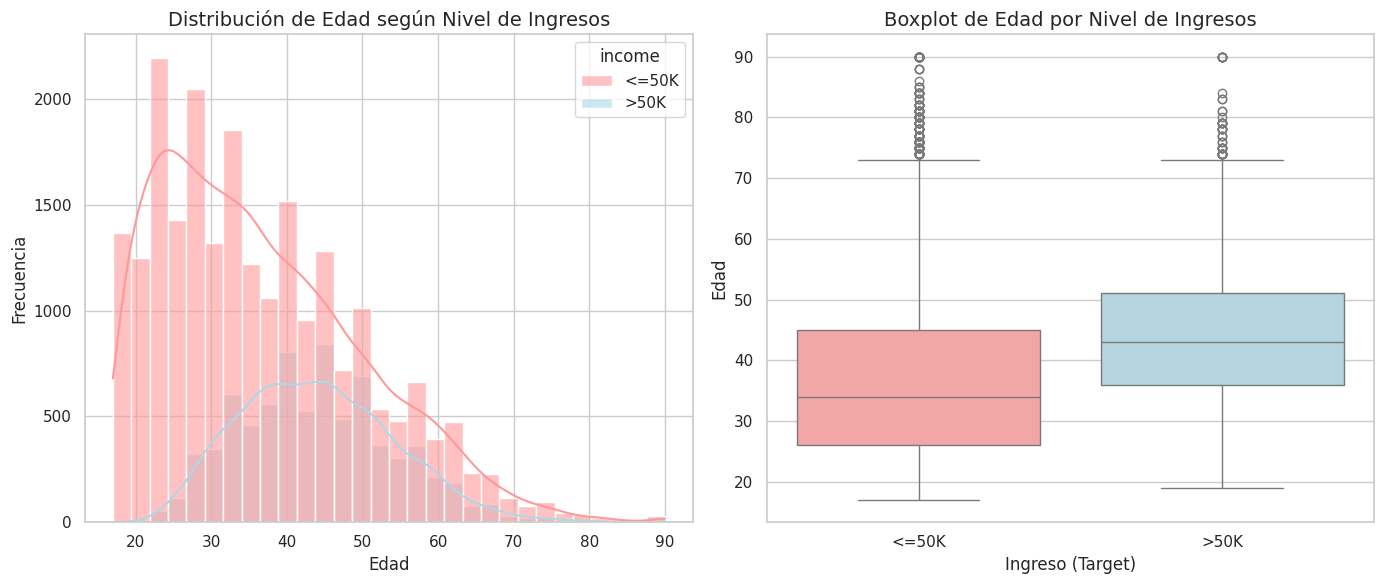

,count,mean,std,min,25%,50%,75%,max
income,,,,,,,,
<=50K,22654.0,36.60806,13.464631,17.0,26.0,34.0,45.0,90.0
>50K,7508.0,43.95911,10.269633,19.0,36.0,43.0,51.0,90.0


In [ ]:
# Configurar la figura con dos subgráficos
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Histograma superpuesto por clase (Income)
sns.histplot(data=train, x='age', hue='income', bins=30, kde=True, ax=axes[0], palette=custom_palette, alpha=0.6)
axes[0].set_title('Distribución de Edad según Nivel de Ingresos', fontsize=14)
axes[0].set_xlabel('Edad', fontsize=12)
axes[0].set_ylabel('Frecuencia', fontsize=12)

# 2. Boxplot de Edad por clase (Income)
# Se asigna hue='income' y legend=False para evitar warnings de seaborn
sns.boxplot(data=train, x='income', y='age', hue='income', ax=axes[1], palette=custom_palette, legend=False)
axes[1].set_title('Boxplot de Edad por Nivel de Ingresos', fontsize=14)
axes[1].set_xlabel('Ingreso (Target)', fontsize=12)
axes[1].set_ylabel('Edad', fontsize=12)

plt.tight_layout()
plt.show()

display(train.groupby('income')['age'].describe())

- Se observa como la distribucion de la edad para el segmento de mayores ingresos es mas simetrica y centrada en 43 años, considerablmente mayor a la distribucion del Universo

In [ ]:
# 2. Transformación Age -> SCA_age
upper_limit = train['age'].quantile(0.99)

# Aplicamos clipping
age_train_clipped = train['age'].clip(upper=upper_limit).values.reshape(-1, 1)
age_test_clipped = test['age'].clip(upper=upper_limit).values.reshape(-1, 1)

scaler_age = MinMaxScaler()

# Guardamos como Series independientes con el nuevo nombre SCA_age
SCA_age_train = pd.Series(scaler_age.fit_transform(age_train_clipped).flatten(), index=train.index, name='SCA_age')
SCA_age_test = pd.Series(scaler_age.transform(age_test_clipped).flatten(), index=test.index, name='SCA_age')

# Agregamos a las listas de variables transformadas
variables_transformadas_train.append(SCA_age_train)
variables_transformadas_test.append(SCA_age_test)

display(SCA_age_train.describe())


,SCA_age
count,30162.000000
mean,0.388678
std,0.235509
min,0.000000
25%,0.200000
50%,0.363636
75%,0.545455
max,1.000000


- Capeamos al percentil 99 para limitar el impacto que puedan ocacionar los registros con valores extremos (gente de 90 años)
- Ya que la idea es utilizar una Red Neuronal, y que sabemos que no hay valores exteremos, Escalamos los datos entre 0 y 1 utilizando MinMax Scaler
- SCA_age

### Workclass
Tipo de empleador o relación laboral del individuo. Describe si trabaja en el sector privado, gobierno estatal, local, federal, por cuenta propia, sin remuneración, etc.

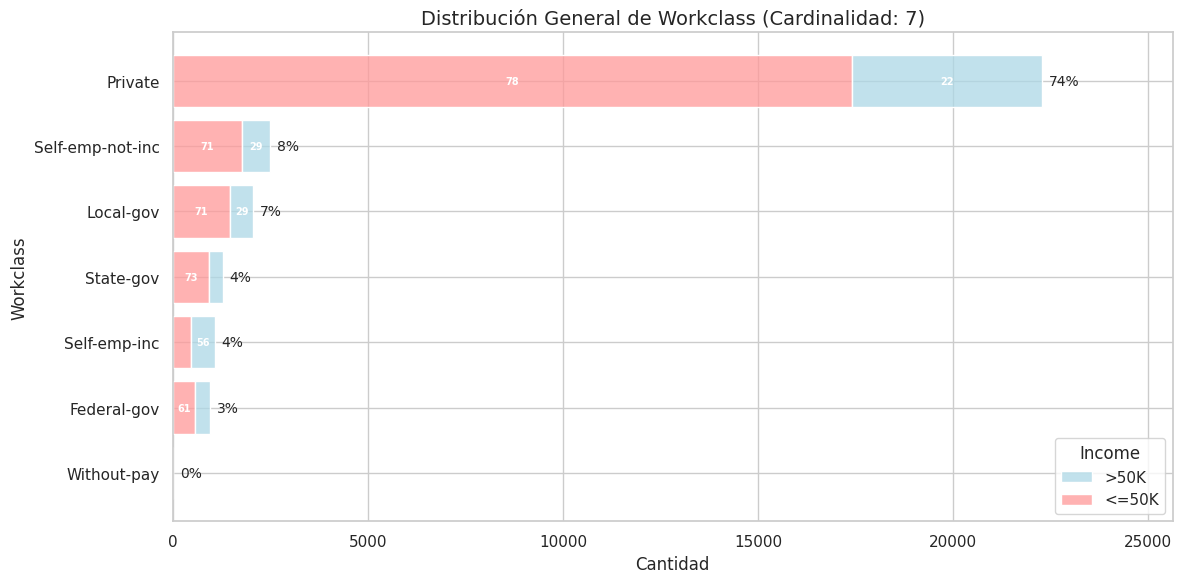

In [ ]:
cardinalidad_workclass = train['workclass'].nunique()
conteo_workclass = train['workclass'].value_counts()

fig, ax = plt.subplots(figsize=(12, 6))
# Ordenamos temporalmente para el gráfico
train['workclass'] = pd.Categorical(train['workclass'], categories=conteo_workclass.index, ordered=True)

sns.histplot(data=train, y='workclass', hue='income', multiple='stack', ax=ax, palette=custom_palette, shrink=0.8, hue_order=['>50K', '<=50K'])
ax.set_title(f'Distribución General de Workclass (Cardinalidad: {cardinalidad_workclass})', fontsize=14)
ax.set_xlabel('Cantidad', fontsize=12)
ax.set_ylabel('Workclass', fontsize=12)

# Leyenda abajo a la derecha
sns.move_legend(ax, "lower right", title='Income')

# Porcentajes totales al final de cada barra
ax.set_xlim(0, conteo_workclass.max() * 1.15)
total_len = len(train)
for i, width in enumerate(conteo_workclass):
    percentage = f'{100 * width / total_len:.0f}%'
    ax.annotate(percentage, (width, i), ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontsize=10)

# Etiquetas internas (proporción por barra) con el umbral del 2%
threshold = 0.02 * ax.get_xlim()[1]
for p in ax.patches:
    w = p.get_width()
    if w > threshold:
        y_center = p.get_y() + p.get_height() / 2
        idx = int(round(y_center))
        total_bar = conteo_workclass.iloc[idx]
        pct = 100 * w / total_bar
        ax.annotate(f'{pct:.0f}', (p.get_x() + w / 2, y_center), ha='center', va='center', color='white', fontsize=7, fontweight='bold')

# Restaurar tipo
train['workclass'] = train['workclass'].astype(object)
plt.tight_layout()
plt.show()

- Carnilaidad de 7: Probar one-hot y embeddings
- La gran mayoría de las personas trabajan en el sector privado
- Proporcionalmente, los trabajadores independientes registrados y los federales, son los que tienen un mayor salario
- Creamos categoria Others???? Que hacemos con "Without-pay"???

In [ ]:
# 3. Transformación Workclass -> OHE_workclass
# Instanciamos el encoder
ohe_workclass = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Ajustamos con train y transformamos ambos
workclass_ohe_train_raw = ohe_workclass.fit_transform(train[['workclass']])
workclass_ohe_test_raw = ohe_workclass.transform(test[['workclass']])

# Obtenemos las categorías originales para nombrar las columnas con el prefijo OHE_WORKCLASS_
categories = [cat.replace(' ', '_') for cat in ohe_workclass.categories_[0]]
columns_ohe = [f"OHE_WORKCLASS_{cat}" for cat in categories]

# Creamos los DataFrames resultantes
OHE_workclass_train = pd.DataFrame(workclass_ohe_train_raw, columns=columns_ohe, index=train.index)
OHE_workclass_test = pd.DataFrame(workclass_ohe_test_raw, columns=columns_ohe, index=test.index)

# Agregamos a las listas de variables transformadas
variables_transformadas_train.append(OHE_workclass_train)
variables_transformadas_test.append(OHE_workclass_test)


- Cardinlaidad baja y no ordinal, transformamos con One-Hot encoding
- OHE_WORKCLASS_xxx


### Education
Nivel educativo alcanzado del individuo.

In [ ]:
# Renombramos para que incluya el valor ordinal de cada categoria, para simplicar la comprension en las visualizaciones

education_order = ['Preschool', '1st-4th', '5th-6th', '7th-8th', '9th', '10th', '11th', '12th', 'HS-grad', 'Some-college', 'Assoc-voc', 'Assoc-acdm', 'Bachelors', 'Masters', 'Prof-school', 'Doctorate']
education_mapping = {edu: f'{i+1:02d}-{edu}' for i, edu in enumerate(education_order)}

# Aplicamos el mapeo ordinal
train['education'] = train['education'].map(education_mapping)
test['education'] = test['education'].map(education_mapping)

# Definimos el orden para los graficos basado en los nuevos strings
order_edu = sorted(train['education'].unique())
cardinalidad_edu = train['education'].nunique()

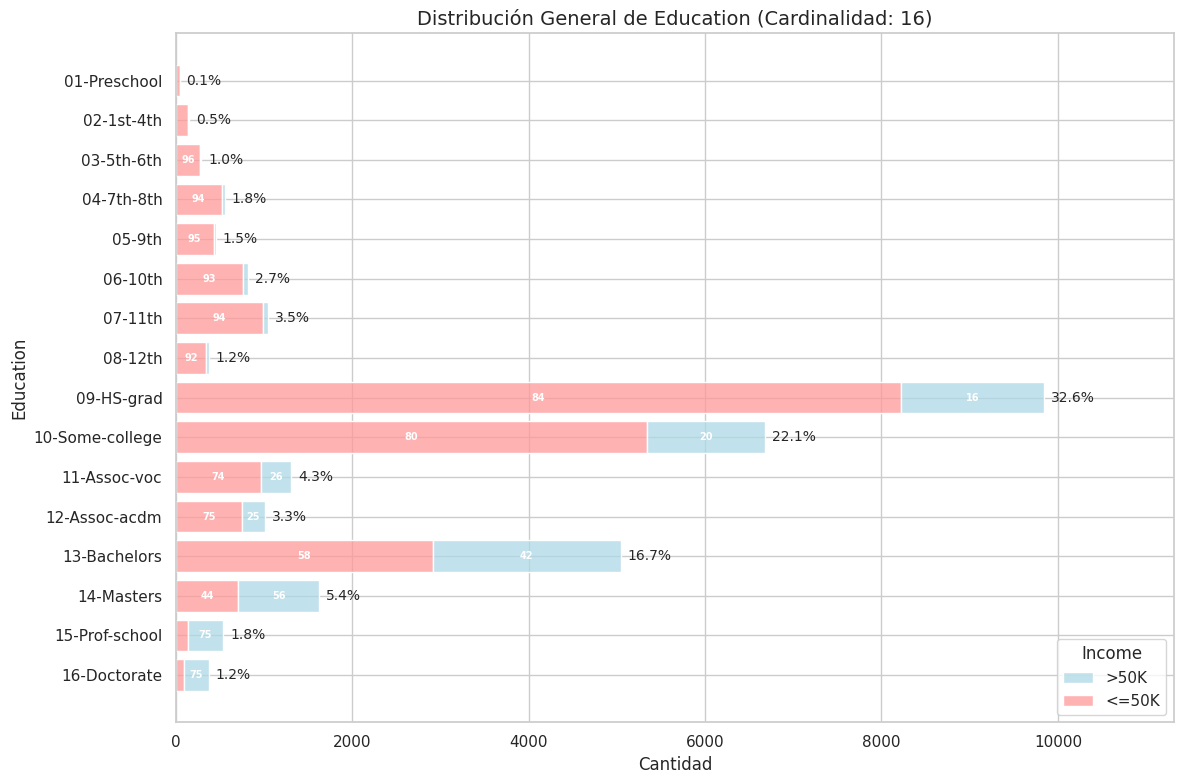

In [ ]:
# Ploteo

conteo_education = train['education'].value_counts().reindex(order_edu)
fig, ax = plt.subplots(figsize=(12, 8))
train['education'] = pd.Categorical(train['education'], categories=order_edu, ordered=True)

sns.histplot(data=train, y='education', hue='income', multiple='stack', ax=ax, palette=custom_palette, shrink=0.8, hue_order=['>50K', '<=50K'])
ax.set_title(f'Distribución General de Education (Cardinalidad: {cardinalidad_edu})', fontsize=14)
ax.set_xlabel('Cantidad', fontsize=12)
ax.set_ylabel('Education', fontsize=12)

sns.move_legend(ax, 'lower right', title='Income')

# Anotaciones externas (% del total)
ax.set_xlim(0, conteo_education.max() * 1.15)
total_records = len(train)
for i, width in enumerate(conteo_education):
    percentage = f'{100 * width / total_records:.1f}%'
    ax.annotate(percentage, (width, i), ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontsize=10)

# Anotaciones internas (% de la categoría)
threshold = 0.02 * ax.get_xlim()[1]
for p in ax.patches:
    w = p.get_width()
    if w > threshold:
        y_center = p.get_y() + p.get_height() / 2
        idx = int(round(y_center))
        if idx < len(conteo_education):
            total_bar = conteo_education.iloc[idx]
            pct = 100 * w / total_bar
            ax.annotate(f'{pct:.0f}', (p.get_x() + w / 2, y_center), ha='center', va='center', color='white', fontsize=7, fontweight='bold')

train['education'] = train['education'].astype(object)
plt.tight_layout()
plt.show()

- Cardinlaidad de 16: Podemos usar Embeddings o agruparlas y usar Ordinal
- Se ve claramente que los profesionales con titulo universitario tienen una mayor distribucion de ingresos

In [ ]:
# Agrupamos y Transoformamos

# Reagrupamos las categorías de education según lo solicitado (cubriendo ambas opciones)
group_mapping = {
    'Preschool': '01 - Primary',
    '1st-4th': '01 - Primary',
    '5th-6th': '01 - Primary',
    '7th-8th': '01 - Primary',
    '9th': '02 - HighSchool Incomplete',
    '10th': '02 - HighSchool Incomplete',
    '11th': '02 - HighSchool Incomplete',
    '12th': '02 - HighSchool Incomplete',
    'HS-grad': '03 - HighSchool Complete',
    'Some-college': '04 - Bachelors Incomplete',
    'Assoc-voc': '05 - Associate Complete',
    'Assoc-acdm': '05 - Associate Complete',
    'Bachelors': '06 - Bachelors Complete',
    'Masters': '07 - Masters Complete',
    'Prof-school': '08 - Prof/PhD Complete',
    'Doctorate': '08 - Prof/PhD Complete',
    '01-Preschool': '01 - Primary',
    '02-1st-4th': '01 - Primary',
    '03-5th-6th': '01 - Primary',
    '04-7th-8th': '01 - Primary',
    '05-9th': '02 - HighSchool Incomplete',
    '06-10th': '02 - HighSchool Incomplete',
    '07-11th': '02 - HighSchool Incomplete',
    '08-12th': '02 - HighSchool Incomplete',
    '09-HS-grad': '03 - HighSchool Complete',
    '10-Some-college': '04 - Bachelors Incomplete',
    '11-Assoc-voc': '05 - Associate Complete',
    '12-Assoc-acdm': '05 - Associate Complete',
    '13-Bachelors': '06 - Bachelors Complete',
    '14-Masters': '07 - Masters Complete',
    '15-Prof-school': '08 - Prof/PhD Complete',
    '16-Doctorate': '08 - Prof/PhD Complete'
}

# Aplicamos la agrupación limpiando espacios extras
train['education_grouped'] = train['education'].str.strip().map(group_mapping)
test['education_grouped'] = test['education'].str.strip().map(group_mapping)

# Definimos el nuevo orden
new_order = [
    '01 - Primary',
    '02 - HighSchool Incomplete',
    '03 - HighSchool Complete',
    '04 - Bachelors Incomplete',
    '05 - Associate Complete',
    '06 - Bachelors Complete',
    '07 - Masters Complete',
    '08 - Prof/PhD Complete'
]

# Creamos un mapeo inverso a enteros (0 a 7)
ord_mapping = {val: i for i, val in enumerate(new_order)}

# Aplicamos el ordinal encoding a los grupos
ORD_education_train = train['education_grouped'].map(ord_mapping).astype(int)
ORD_education_test = test['education_grouped'].map(ord_mapping).astype(int)

# Asignamos nombre para consistencia
ORD_education_train.name = 'ORD_education'
ORD_education_test.name = 'ORD_education'

# Agregamos a las listas de variables transformadas
variables_transformadas_train.append(ORD_education_train)
variables_transformadas_test.append(ORD_education_test)


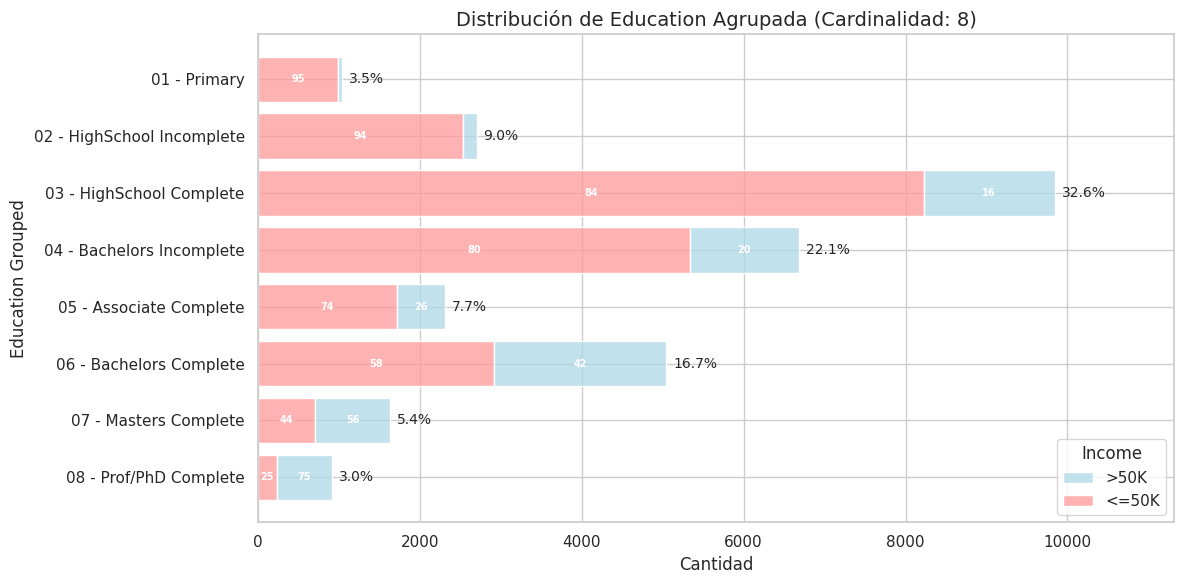

In [ ]:
# Ploteamos

cardinalidad_edu_grouped = train['education_grouped'].nunique()
conteo_edu_grouped = train['education_grouped'].value_counts().reindex(new_order)

fig, ax = plt.subplots(figsize=(12, 6))
# Ordenamos para el gráfico respetando el ordinal
train['education_grouped'] = pd.Categorical(train['education_grouped'], categories=new_order, ordered=True)

sns.histplot(data=train, y='education_grouped', hue='income', multiple='stack', ax=ax, palette=custom_palette, shrink=0.8, hue_order=['>50K', '<=50K'])
ax.set_title(f'Distribución de Education Agrupada (Cardinalidad: {cardinalidad_edu_grouped})', fontsize=14)
ax.set_xlabel('Cantidad', fontsize=12)
ax.set_ylabel('Education Grouped', fontsize=12)

# Leyenda abajo a la derecha
sns.move_legend(ax, "lower right", title='Income')

# Porcentajes totales al final de cada barra
ax.set_xlim(0, conteo_edu_grouped.max() * 1.15)
total_len = len(train)
for i, width in enumerate(conteo_edu_grouped):
    percentage = f'{100 * width / total_len:.1f}%'
    ax.annotate(percentage, (width, i), ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontsize=10)

# Etiquetas internas (proporción por barra)
threshold = 0.02 * ax.get_xlim()[1]
for p in ax.patches:
    w = p.get_width()
    if w > threshold:
        y_center = p.get_y() + p.get_height() / 2
        idx = int(round(y_center))
        if idx < len(conteo_edu_grouped):
            total_bar = conteo_edu_grouped.iloc[idx]
            pct = 100 * w / total_bar
            ax.annotate(f'{pct:.0f}', (p.get_x() + w / 2, y_center), ha='center', va='center', color='white', fontsize=7, fontweight='bold')

# Restaurar tipo
train['education_grouped'] = train['education_grouped'].astype(object)
plt.tight_layout()
plt.show()

- Reagrupando reducimos la cardinalidada a 8 para usar Ordinal Encoder. Igualmente probaremos con Embeddings con la categorias originales
- ORD_education

### Marital-status
Estado civil del individuo.

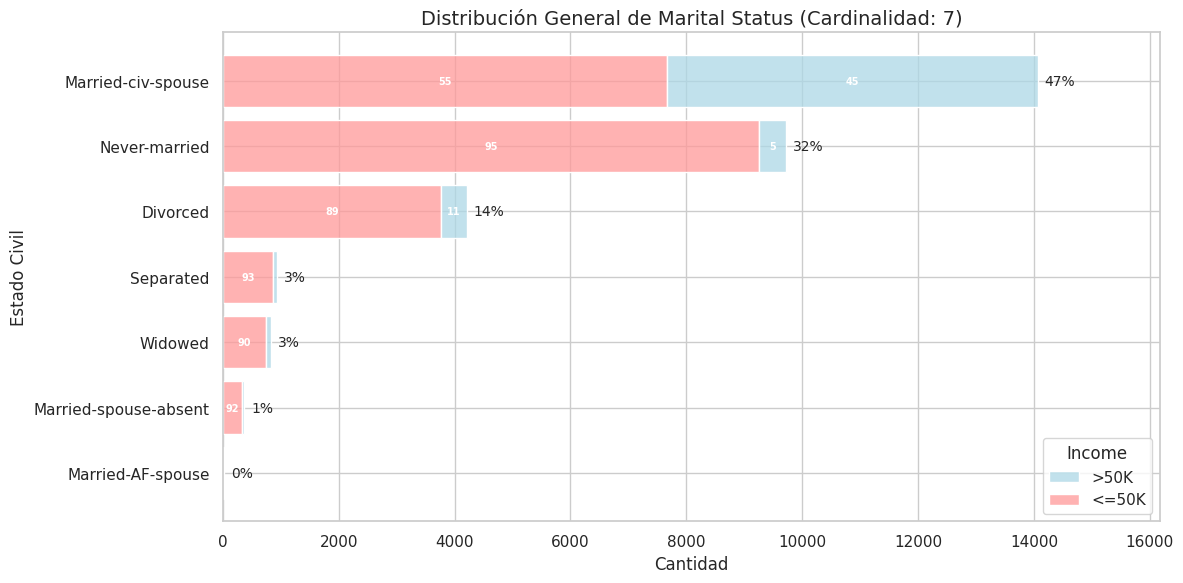

In [ ]:
cardinalidad_marital = train['marital-status'].nunique()
conteo_marital = train['marital-status'].value_counts()

fig, ax = plt.subplots(figsize=(12, 6))
# Ordenamos temporalmente para el gráfico
train['marital-status'] = pd.Categorical(train['marital-status'], categories=conteo_marital.index, ordered=True)

sns.histplot(data=train, y='marital-status', hue='income', multiple='stack', ax=ax, palette=custom_palette, shrink=0.8, hue_order=['>50K', '<=50K'])
ax.set_title(f'Distribución General de Marital Status (Cardinalidad: {cardinalidad_marital})', fontsize=14)
ax.set_xlabel('Cantidad', fontsize=12)
ax.set_ylabel('Estado Civil', fontsize=12)

# Leyenda abajo a la derecha
sns.move_legend(ax, "lower right", title='Income')

# Porcentajes totales al final de cada barra
ax.set_xlim(0, conteo_marital.max() * 1.15)
total_len = len(train)
for i, width in enumerate(conteo_marital):
    percentage = f'{100 * width / total_len:.0f}%'
    ax.annotate(percentage, (width, i), ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontsize=10)

# Etiquetas internas (proporción por barra) con el umbral del 2%
threshold = 0.02 * ax.get_xlim()[1]
for p in ax.patches:
    w = p.get_width()
    if w > threshold:
        y_center = p.get_y() + p.get_height() / 2
        idx = int(round(y_center))
        total_bar = conteo_marital.iloc[idx]
        pct = 100 * w / total_bar
        ax.annotate(f'{pct:.0f}', (p.get_x() + w / 2, y_center), ha='center', va='center', color='white', fontsize=7, fontweight='bold')

# Restaurar tipo
train['marital-status'] = train['marital-status'].astype(object)
plt.tight_layout()
plt.show()

- Cardinalidad de 7 sin orden jerarquico. Usaremos One-Hot Encodding y probaremos con Embeddings luego
- Permite capturar de forma independiente el fuerte impacto que tiene el estado 'Married-civ-spouse' en la variable target (billetera mata galan)
- Que hacemos con Married-AF-spouse???

In [ ]:
# 5. Transformación Marital-status -> OHE_marital_status
ohe_marital = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Ajustamos y transformamos
marital_ohe_train_raw = ohe_marital.fit_transform(train[['marital-status']])
marital_ohe_test_raw = ohe_marital.transform(test[['marital-status']])

# Nombres limpios: reemplazamos espacios y guiones por guiones bajos
categories_marital = [cat.replace(' ', '_').replace('-', '_') for cat in ohe_marital.categories_[0]]
columns_ohe_marital = [f"OHE_MARITAL_STATUS_{cat}" for cat in categories_marital]

# DataFrames
OHE_marital_status_train = pd.DataFrame(marital_ohe_train_raw, columns=columns_ohe_marital, index=train.index)
OHE_marital_status_test = pd.DataFrame(marital_ohe_test_raw, columns=columns_ohe_marital, index=test.index)

# Agregamos a las listas de variables transformadas
variables_transformadas_train.append(OHE_marital_status_train)
variables_transformadas_test.append(OHE_marital_status_test)


- OHE_MARITAL_STATUS_xxx


### Occupation
Tipo de ocupación o área laboral.

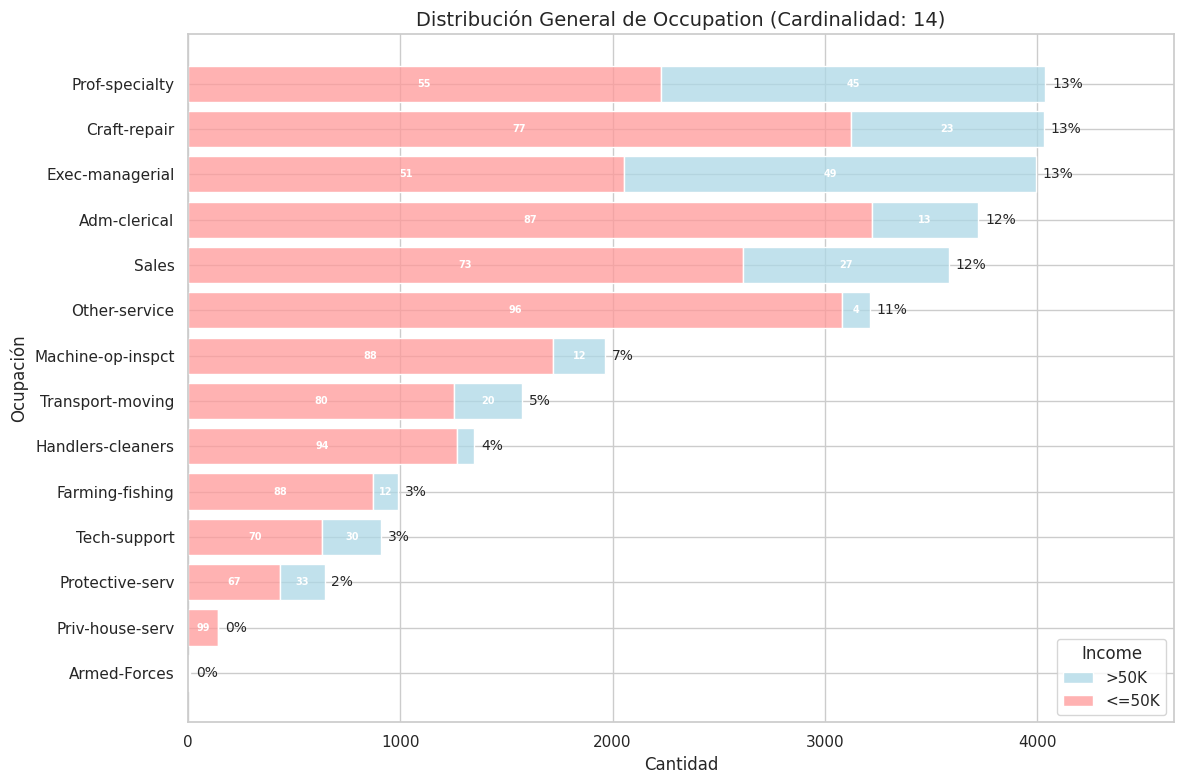

In [ ]:
cardinalidad_occupation = train['occupation'].nunique()
conteo_occupation = train['occupation'].value_counts()

fig, ax = plt.subplots(figsize=(12, 8))
# Ordenamos temporalmente para el gráfico
train['occupation'] = pd.Categorical(train['occupation'], categories=conteo_occupation.index, ordered=True)

sns.histplot(data=train, y='occupation', hue='income', multiple='stack', ax=ax, palette=custom_palette, shrink=0.8, hue_order=['>50K', '<=50K'])
ax.set_title(f'Distribución General de Occupation (Cardinalidad: {cardinalidad_occupation})', fontsize=14)
ax.set_xlabel('Cantidad', fontsize=12)
ax.set_ylabel('Ocupación', fontsize=12)

# Leyenda abajo a la derecha
sns.move_legend(ax, "lower right", title='Income')

# Porcentajes totales al final de cada barra
ax.set_xlim(0, conteo_occupation.max() * 1.15)
total_len = len(train)
for i, width in enumerate(conteo_occupation):
    percentage = f'{100 * width / total_len:.0f}%'
    ax.annotate(percentage, (width, i), ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontsize=10)

# Etiquetas internas (proporción por barra) con el umbral del 2%
threshold = 0.02 * ax.get_xlim()[1]
for p in ax.patches:
    w = p.get_width()
    if w > threshold:
        y_center = p.get_y() + p.get_height() / 2
        idx = int(round(y_center))
        total_bar = conteo_occupation.iloc[idx]
        pct = 100 * w / total_bar
        ax.annotate(f'{pct:.0f}', (p.get_x() + w / 2, y_center), ha='center', va='center', color='white', fontsize=7, fontweight='bold')

# Restaurar tipo
train['occupation'] = train['occupation'].astype(object)
plt.tight_layout()
plt.show()

- Cardinalidad de 14, Embeddings y Freq/Target Encodding. Compararemos resultados

In [ ]:
# Implementación de Frequency Encoding para 'occupation'

# 1. Calculamos las frecuencias (proporciones) en el set de entrenamiento
occ_freq_map = train['occupation'].value_counts(normalize=True).to_dict()

# 2. Aplicamos el mapeo a ambos datasets
# Usamos el prefijo 'FRQ_' para identificar la transformación
FRQ_Occupation_train = train['occupation'].map(occ_freq_map)
FRQ_Occupation_test = test['occupation'].map(occ_freq_map)

# Manejo de valores nuevos en test (si los hubiera) con 0
FRQ_Occupation_test = FRQ_Occupation_test.fillna(0)

# Convertimos a Series con nombre para consistencia
FRQ_Occupation_train.name = 'FRQ_Occupation'
FRQ_Occupation_test.name = 'FRQ_Occupation'

# Agregamos a las listas de variables transformadas
variables_transformadas_train.append(FRQ_Occupation_train)
variables_transformadas_test.append(FRQ_Occupation_test)

print("Mapeo de frecuencias generado y agregado a las listas:")
for occ, freq in list(occ_freq_map.items())[:5]:
    print(f" - {occ}: {freq:.4f}")


Mapeo de frecuencias generado y agregado a las listas:
 - Prof-specialty: 0.1339
 - Craft-repair: 0.1336
 - Exec-managerial: 0.1324
 - Adm-clerical: 0.1234
 - Sales: 0.1188


- Al tener alta cardinalidad, podemos usar alguna transofrmacion matematica como alternativa de los Embeddings como Frequency, Mean o Weight of Evidence
- FRQ_Occupation

In [ ]:
# Implementación de Target Encoding para 'occupation'

# 1. Calculamos la media del target (Income > 50K) para cada ocupación en el set de entrenamiento
occ_target_map = BOOL_Income_train.groupby(train['occupation']).mean().to_dict()

# 2. Aplicamos el mapeo a ambos datasets
# Usamos el prefijo 'TAR_' para identificar la transformación
TAR_Occupation_train = train['occupation'].map(occ_target_map)
TAR_Occupation_test = test['occupation'].map(occ_target_map)

# Manejo de valores nuevos en test (si los hubiera) rellenando con la media global de train
global_target_mean = BOOL_Income_train.mean()
TAR_Occupation_test = TAR_Occupation_test.fillna(global_target_mean)

# Convertimos a Series con nombre para consistencia
TAR_Occupation_train.name = 'TAR_Occupation'
TAR_Occupation_test.name = 'TAR_Occupation'

# Agregamos a las listas de variables transformadas
variables_transformadas_train.append(TAR_Occupation_train)
variables_transformadas_test.append(TAR_Occupation_test)

print("Mapeo de Target Encoding (proporción de >50K) generado y agregado a las listas:")
# Mostramos el top 5 de ocupaciones con mayor proporción de ingresos >50K
for occ, target_mean in sorted(occ_target_map.items(), key=lambda item: item[1], reverse=True)[:5]:
    print(f" - {occ}: {target_mean:.4f}")


Mapeo de Target Encoding (proporción de >50K) generado y agregado a las listas:
 - Exec-managerial: 0.4852
 - Prof-specialty: 0.4485
 - Protective-serv: 0.3261
 - Tech-support: 0.3048
 - Sales: 0.2706


- TAR_Occupation

### Relationship


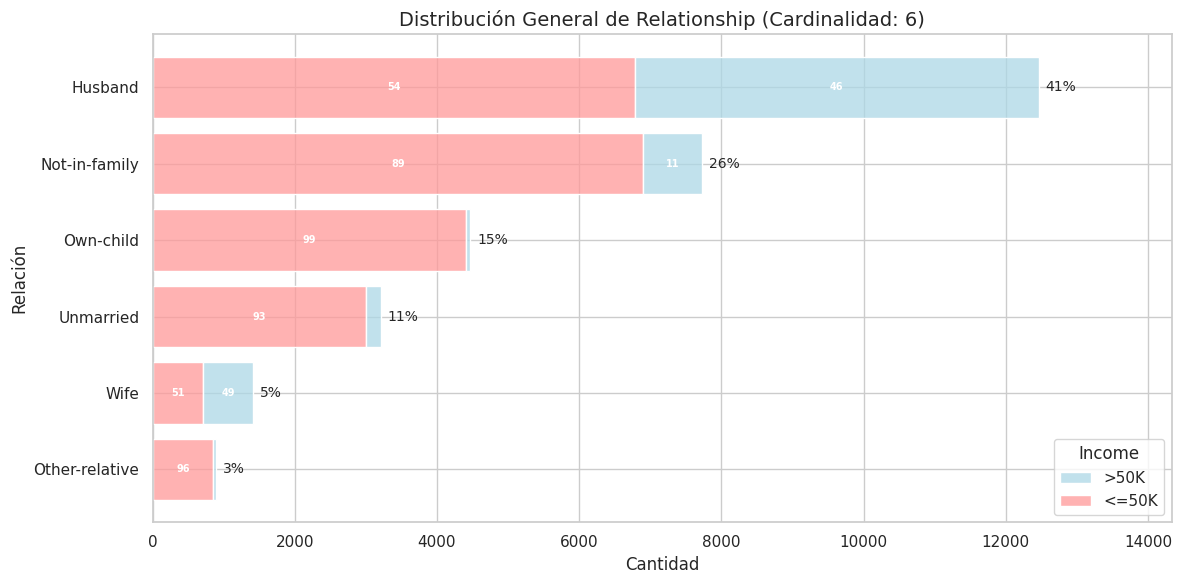

In [ ]:
cardinalidad_rel = train['relationship'].nunique()
conteo_rel = train['relationship'].value_counts()

fig, ax = plt.subplots(figsize=(12, 6))
# Ordenamos para el gráfico
train['relationship'] = pd.Categorical(train['relationship'], categories=conteo_rel.index, ordered=True)

sns.histplot(data=train, y='relationship', hue='income', multiple='stack', ax=ax, palette=custom_palette, shrink=0.8, hue_order=['>50K', '<=50K'])
ax.set_title(f'Distribución General de Relationship (Cardinalidad: {cardinalidad_rel})', fontsize=14)
ax.set_xlabel('Cantidad', fontsize=12)
ax.set_ylabel('Relación', fontsize=12)

# Leyenda
sns.move_legend(ax, "lower right", title='Income')

# Porcentajes totales (externos)
ax.set_xlim(0, conteo_rel.max() * 1.15)
total_len = len(train)
for i, width in enumerate(conteo_rel):
    percentage = f'{100 * width / total_len:.0f}%'
    ax.set_yticks(range(len(conteo_rel)))
    ax.annotate(percentage, (width, i), ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontsize=10)

# Etiquetas internas (% relativo a la categoría)
threshold = 0.02 * ax.get_xlim()[1]
for p in ax.patches:
    w = p.get_width()
    if w > threshold:
        y_center = p.get_y() + p.get_height() / 2
        idx = int(round(y_center))
        total_bar = conteo_rel.iloc[idx]
        pct = 100 * w / total_bar
        ax.annotate(f'{pct:.0f}', (p.get_x() + w / 2, y_center), ha='center', va='center', color='white', fontsize=7, fontweight='bold')

# Restaurar tipo
train['relationship'] = train['relationship'].astype(object)
plt.tight_layout()
plt.show()

- Cardinalidad de 6. Utilizaremos One-Hot Encoding ya que son pocas categorías
- Seguramente tenga alta correlacion con Marital_Status

In [ ]:
# 1. Transformación Relationship -> OHE_relationship
ohe_rel = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Ajustamos y transformamos
rel_ohe_train_raw = ohe_rel.fit_transform(train[['relationship']])
rel_ohe_test_raw = ohe_rel.transform(test[['relationship']])

# Nombres limpios: reemplazamos espacios y guiones por guiones bajos
categories_rel = [cat.replace(' ', '_').replace('-', '_') for cat in ohe_rel.categories_[0]]
columns_ohe_rel = [f"OHE_RELATIONSHIP_{cat}" for cat in categories_rel]

# DataFrames
OHE_relationship_train = pd.DataFrame(rel_ohe_train_raw, columns=columns_ohe_rel, index=train.index)
OHE_relationship_test = pd.DataFrame(rel_ohe_test_raw, columns=columns_ohe_rel, index=test.index)

# Agregamos a las listas de variables transformadas
variables_transformadas_train.append(OHE_relationship_train)
variables_transformadas_test.append(OHE_relationship_test)


- OHE_RELATIONSHIP_xxx

### Race
Autoidentificación racial del individuo.

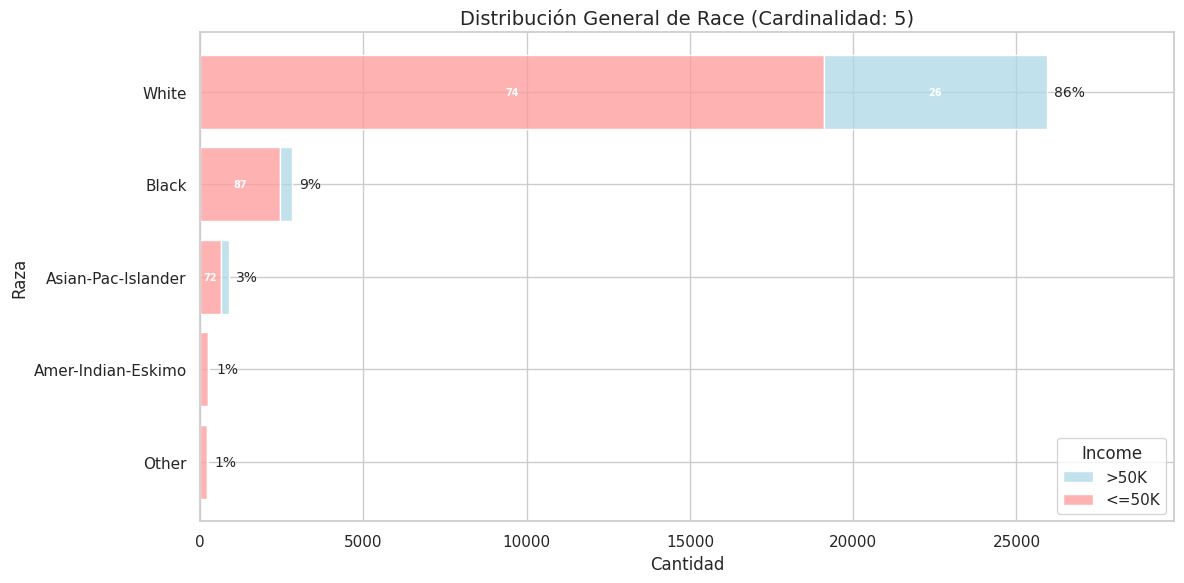

In [ ]:
cardinalidad_race = train['race'].nunique()
conteo_race = train['race'].value_counts()

fig, ax = plt.subplots(figsize=(12, 6))
# Ordenamos para el gráfico
train['race'] = pd.Categorical(train['race'], categories=conteo_race.index, ordered=True)

sns.histplot(data=train, y='race', hue='income', multiple='stack', ax=ax, palette=custom_palette, shrink=0.8, hue_order=['>50K', '<=50K'])
ax.set_title(f'Distribución General de Race (Cardinalidad: {cardinalidad_race})', fontsize=14)
ax.set_xlabel('Cantidad', fontsize=12)
ax.set_ylabel('Raza', fontsize=12)

# Leyenda
sns.move_legend(ax, "lower right", title='Income')

# Porcentajes totales (externos)
ax.set_xlim(0, conteo_race.max() * 1.15)
total_len = len(train)
for i, width in enumerate(conteo_race):
    percentage = f'{100 * width / total_len:.0f}%'
    ax.annotate(percentage, (width, i), ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontsize=10)

# Etiquetas internas (% relativo a la categoría)
threshold = 0.02 * ax.get_xlim()[1]
for p in ax.patches:
    w = p.get_width()
    if w > threshold:
        y_center = p.get_y() + p.get_height() / 2
        idx = int(round(y_center))
        if idx < len(conteo_race):
            total_bar = conteo_race.iloc[idx]
            pct = 100 * w / total_bar
            ax.annotate(f'{pct:.0f}', (p.get_x() + w / 2, y_center), ha='center', va='center', color='white', fontsize=7, fontweight='bold')

# Restaurar tipo
train['race'] = train['race'].astype(object)
plt.tight_layout()
plt.show()

- Cardinalidad de 5
- Ya que son pocos casos que no sean White y Black, agrupamos el resto en Others
- Se ve claramente como los blancos tienen mayores salarios

In [ ]:
# 1. Definimos las categorías principales y agrupamos las demás en 'Other'
main_races = ['White', 'Black']

train['race_grouped'] = train['race'].apply(lambda x: x if x in main_races else 'Other')
test['race_grouped'] = test['race'].apply(lambda x: x if x in main_races else 'Other')

# 2. Aplicamos One-Hot Encoding a las categorías agrupadas
ohe_race = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

race_ohe_train_raw = ohe_race.fit_transform(train[['race_grouped']])
race_ohe_test_raw = ohe_race.transform(test[['race_grouped']])

# Nombres de columnas limpios (prefijo en mayúsculas)
columns_ohe_race = [f"OHE_RACE_{cat.replace(' ', '_').replace('-', '_')}" for cat in ohe_race.categories_[0]]

# Crear DataFrames
OHE_race_train = pd.DataFrame(race_ohe_train_raw, columns=columns_ohe_race, index=train.index)
OHE_race_test = pd.DataFrame(race_ohe_test_raw, columns=columns_ohe_race, index=test.index)

# Agregamos a las listas de variables transformadas
variables_transformadas_train.append(OHE_race_train)
variables_transformadas_test.append(OHE_race_test)


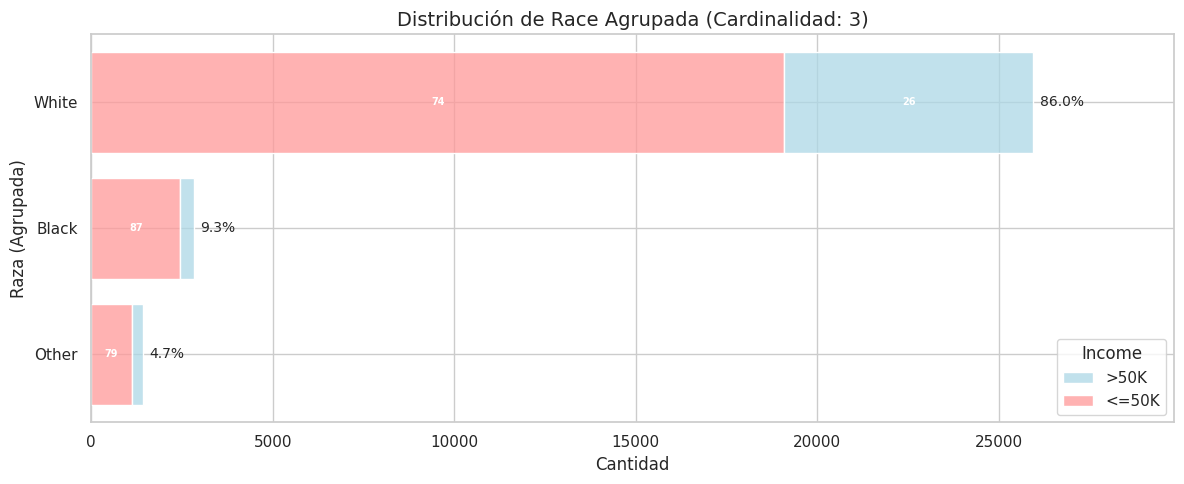

In [ ]:
# --- Visualización ---
cardinalidad_race_grouped = train['race_grouped'].nunique()
conteo_race_grouped = train['race_grouped'].value_counts()

fig, ax = plt.subplots(figsize=(12, 5))
# Ordenamos para el gráfico
train['race_grouped'] = pd.Categorical(train['race_grouped'], categories=conteo_race_grouped.index, ordered=True)

sns.histplot(data=train, y='race_grouped', hue='income', multiple='stack', ax=ax, palette=custom_palette, shrink=0.8, hue_order=['>50K', '<=50K'])
ax.set_title(f'Distribución de Race Agrupada (Cardinalidad: {cardinalidad_race_grouped})', fontsize=14)
ax.set_xlabel('Cantidad', fontsize=12)
ax.set_ylabel('Raza (Agrupada)', fontsize=12)

# Leyenda
sns.move_legend(ax, "lower right", title='Income')

# Porcentajes totales (externos)
ax.set_xlim(0, conteo_race_grouped.max() * 1.15)
total_len = len(train)
for i, width in enumerate(conteo_race_grouped):
    percentage = f'{100 * width / total_len:.1f}%'
    ax.annotate(percentage, (width, i), ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontsize=10)

# Etiquetas internas (% relativo a la categoría)
threshold = 0.02 * ax.get_xlim()[1]
for p in ax.patches:
    w = p.get_width()
    if w > threshold:
        y_center = p.get_y() + p.get_height() / 2
        idx = int(round(y_center))
        if idx < len(conteo_race_grouped):
            total_bar = conteo_race_grouped.iloc[idx]
            pct = 100 * w / total_bar
            ax.annotate(f'{pct:.0f}', (p.get_x() + w / 2, y_center), ha='center', va='center', color='white', fontsize=7, fontweight='bold')

# Restaurar tipo
train['race_grouped'] = train['race_grouped'].astype(object)
plt.tight_layout()
plt.show()


- OHE_RACE

### Sex
Sexo biológico del individuo (masculino o femenino).

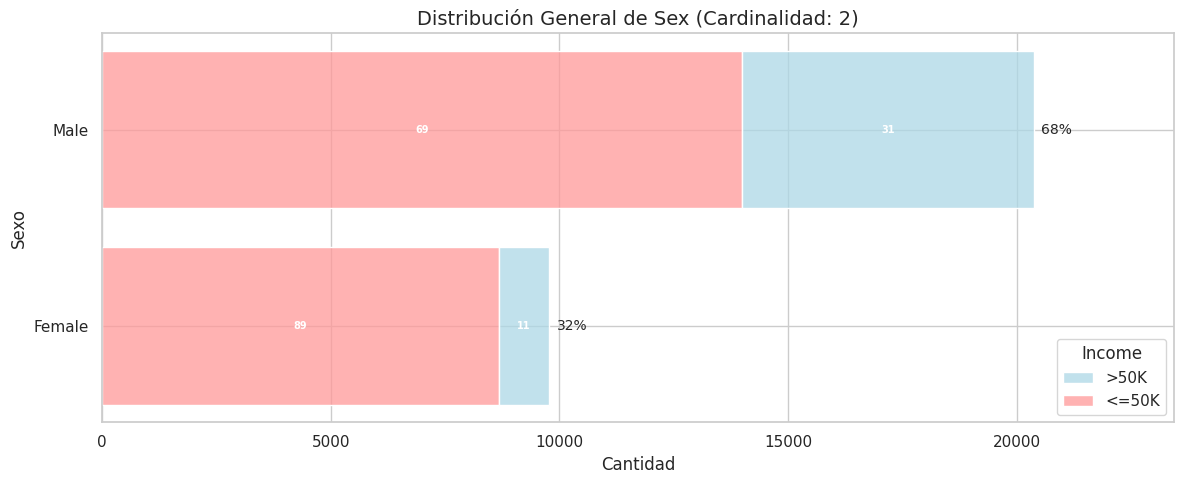

In [ ]:
cardinalidad_sex = train['sex'].nunique()
conteo_sex = train['sex'].value_counts()

fig, ax = plt.subplots(figsize=(12, 5))
# Ordenamos para el gráfico
train['sex'] = pd.Categorical(train['sex'], categories=conteo_sex.index, ordered=True)

sns.histplot(data=train, y='sex', hue='income', multiple='stack', ax=ax, palette=custom_palette, shrink=0.8, hue_order=['>50K', '<=50K'])
ax.set_title(f'Distribución General de Sex (Cardinalidad: {cardinalidad_sex})', fontsize=14)
ax.set_xlabel('Cantidad', fontsize=12)
ax.set_ylabel('Sexo', fontsize=12)

# Leyenda
sns.move_legend(ax, "lower right", title='Income')

# Porcentajes totales (externos)
ax.set_xlim(0, conteo_sex.max() * 1.15)
total_len = len(train)
for i, width in enumerate(conteo_sex):
    percentage = f'{100 * width / total_len:.0f}%'
    ax.annotate(percentage, (width, i), ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontsize=10)

# Etiquetas internas (% relativo a la categoría)
threshold = 0.02 * ax.get_xlim()[1]
for p in ax.patches:
    w = p.get_width()
    if w > threshold:
        y_center = p.get_y() + p.get_height() / 2
        idx = int(round(y_center))  # Corregido: se asegura de que idx sea entero
        if idx < len(conteo_sex):
            total_bar = conteo_sex.iloc[idx]
            pct = 100 * w / total_bar
            ax.annotate(f'{pct:.0f}', (p.get_x() + w / 2, y_center), ha='center', va='center', color='white', fontsize=7, fontweight='bold')

# Restaurar tipo
train['sex'] = train['sex'].astype(object)
plt.tight_layout()
plt.show()

- Cardinalidad de 2 (Binaria)
- 2/3 de la base son hombres
- La proporcionde hombres con salarios altos es casi del triple que de mujeres

In [ ]:
# 8. Transformación Sex -> BOOL_is_men
sex_mapping = {'Male': 1, 'Female': 0}

BOOL_is_men_train = train['sex'].map(sex_mapping).astype(int)
BOOL_is_men_test = test['sex'].map(sex_mapping).astype(int)

# Asignamos nombre para consistencia
BOOL_is_men_train.name = 'BOOL_is_men'
BOOL_is_men_test.name = 'BOOL_is_men'

# Agregamos a las listas de variables transformadas
variables_transformadas_train.append(BOOL_is_men_train)
variables_transformadas_test.append(BOOL_is_men_test)


- BOOL_is_men

### Skill-profile
Habilidad principal o conocimiento técnico adquirido que podría aplicar en el trabajo.

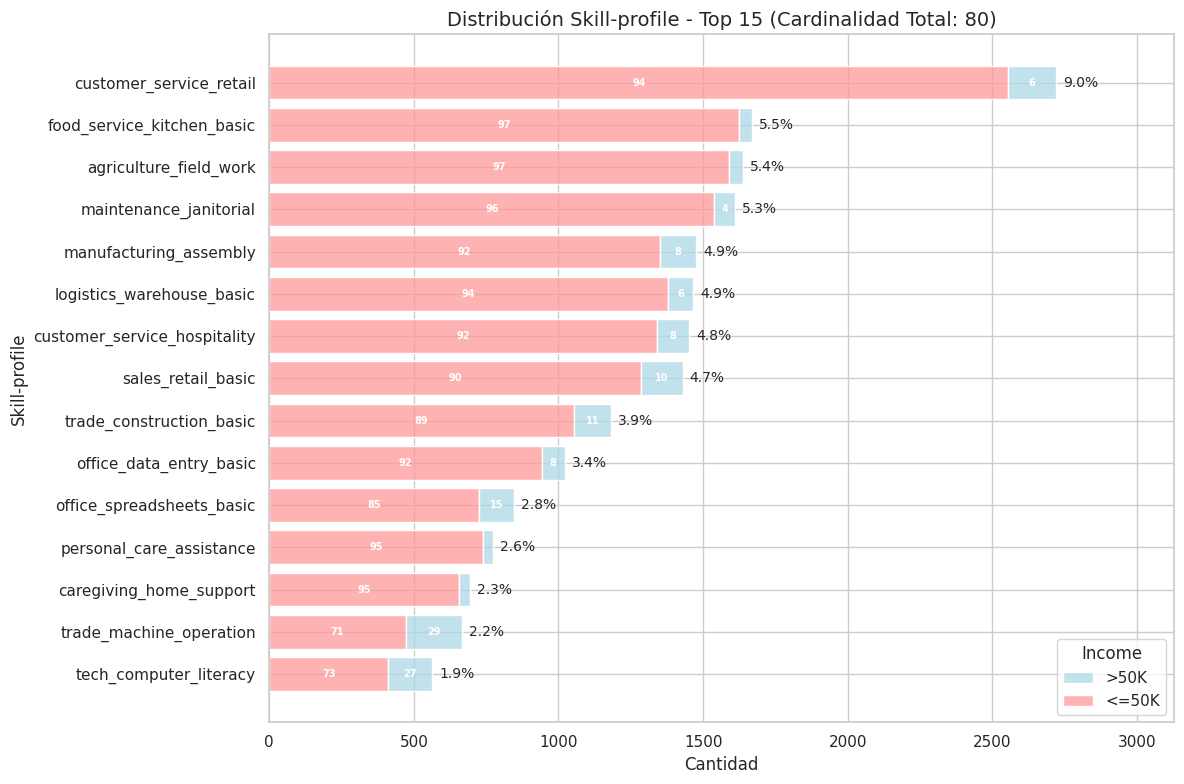

In [ ]:
cardinalidad_skill = train['skill-profile'].nunique()
conteo_skill = train['skill-profile'].value_counts()
top_15_skills = conteo_skill.head(15)

fig, ax = plt.subplots(figsize=(12, 8))
train_top = train[train['skill-profile'].isin(top_15_skills.index)].copy()
train_top['skill-profile'] = pd.Categorical(train_top['skill-profile'], categories=top_15_skills.index, ordered=True)

sns.histplot(data=train_top, y='skill-profile', hue='income', multiple='stack', ax=ax, palette=custom_palette, shrink=0.8, hue_order=['>50K', '<=50K'])
ax.set_title(f'Distribución Skill-profile - Top 15 (Cardinalidad Total: {cardinalidad_skill})', fontsize=14)
ax.set_xlabel('Cantidad', fontsize=12)
ax.set_ylabel('Skill-profile', fontsize=12)

sns.move_legend(ax, "lower right", title='Income')

ax.set_xlim(0, top_15_skills.max() * 1.15)
total_len = len(train)
for i, width in enumerate(top_15_skills):
    percentage = f'{100 * width / total_len:.1f}%'
    ax.annotate(percentage, (width, i), ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontsize=10)

threshold = 0.02 * ax.get_xlim()[1]
for p in ax.patches:
    w = p.get_width()
    if w > threshold:
        y_center = p.get_y() + p.get_height() / 2
        idx = int(round(y_center))
        if idx < len(top_15_skills):
            total_bar = top_15_skills.iloc[idx]
            pct = 100 * w / total_bar
            ax.annotate(f'{pct:.0f}', (p.get_x() + w / 2, y_center), ha='center', va='center', color='white', fontsize=7, fontweight='bold')

plt.tight_layout()
plt.show()

- Cardinalidad de 80, Embeddings
- Para el primer modelo podriamos probar con Freq/Target/WoE

In [ ]:
# 10. Transformación Skill-profile -> FRQ_skill_profile
# Cardinalidad 80: Utilizamos Frequency Encoding

# 1. Calculamos las frecuencias en entrenamiento
skill_freq_map = train['skill-profile'].value_counts(normalize=True).to_dict()

# 2. Mapeamos a ambos datasets
FRQ_skill_profile_train = train['skill-profile'].map(skill_freq_map)
FRQ_skill_profile_test = test['skill-profile'].map(skill_freq_map)

# Manejo de nulos en test (categorías que no estaban en train) con 0
FRQ_skill_profile_test = FRQ_skill_profile_test.fillna(0)

# Convertimos a Series con nombre
FRQ_skill_profile_train.name = 'FRQ_skill_profile'
FRQ_skill_profile_test.name = 'FRQ_skill_profile'

# Agregamos a las listas de variables transformadas
variables_transformadas_train.append(FRQ_skill_profile_train)
variables_transformadas_test.append(FRQ_skill_profile_test)

print(f"Frequency Encoding aplicado a 'skill-profile' y agregado a las listas.")
print(f"Ejemplo de mapeo (Top 5 habilidades):")
for skill, freq in list(skill_freq_map.items())[:5]:
    print(f" - {skill}: {freq:.4f}")


Frequency Encoding aplicado a 'skill-profile' y agregado a las listas.
Ejemplo de mapeo (Top 5 habilidades):
 - customer_service_retail: 0.0902
 - food_service_kitchen_basic: 0.0553
 - agriculture_field_work: 0.0543
 - maintenance_janitorial: 0.0534
 - manufacturing_assembly: 0.0489


- FRQ_skill_profile

In [ ]:
# Implementación de Target Encoding para 'skill-profile'

# 1. Calculamos la media del target (Income > 50K) para cada skill en el set de entrenamiento
skill_target_map = BOOL_Income_train.groupby(train['skill-profile']).mean().to_dict()

# 2. Aplicamos el mapeo a ambos datasets
TAR_skill_profile_train = train['skill-profile'].map(skill_target_map)
TAR_skill_profile_test = test['skill-profile'].map(skill_target_map)

# Manejo de valores nuevos en test rellenando con la media global de train
global_target_mean = BOOL_Income_train.mean()
TAR_skill_profile_test = TAR_skill_profile_test.fillna(global_target_mean)

# Convertimos a Series con nombre para consistencia
TAR_skill_profile_train.name = 'TAR_skill_profile'
TAR_skill_profile_test.name = 'TAR_skill_profile'

# Agregamos a las listas de variables transformadas
variables_transformadas_train.append(TAR_skill_profile_train)
variables_transformadas_test.append(TAR_skill_profile_test)

print("Mapeo de Target Encoding (TAR_skill_profile) generado y agregado a las listas:")
# Mostramos el top 5 de habilidades con mayor proporción de ingresos >50K
for skill, target_mean in sorted(skill_target_map.items(), key=lambda item: item[1], reverse=True)[:5]:
    print(f" - {skill}: {target_mean:.4f}")


Mapeo de Target Encoding (TAR_skill_profile) generado y agregado a las listas:
 - executive_decision_support: 0.9730
 - management_strategic_planning: 0.9322
 - tech_cloud_systems: 0.9214
 - finance_investment_analysis: 0.9200
 - management_operations: 0.9048


- TAR_skill_profile

### Native-country
País de nacimiento del individuo.

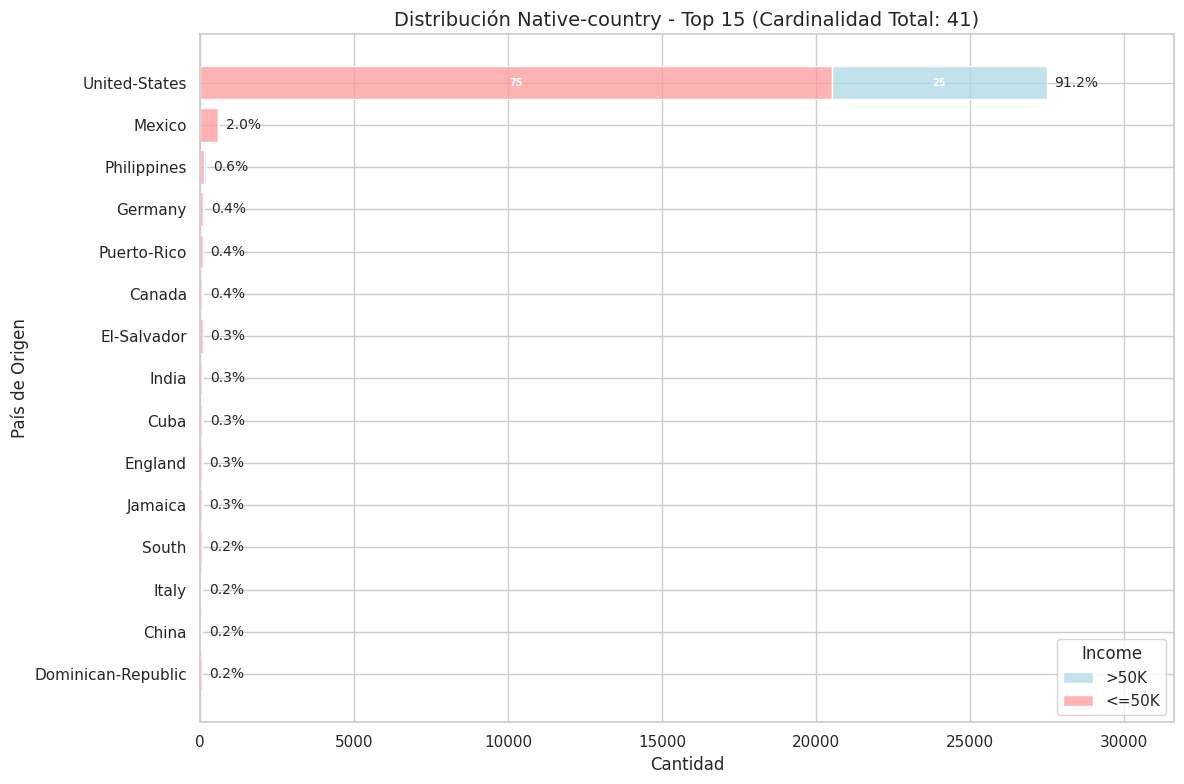

In [ ]:
cardinalidad_country = train['native-country'].nunique()
conteo_country = train['native-country'].value_counts()
top_15_countries = conteo_country.head(15)

fig, ax = plt.subplots(figsize=(12, 8))
train_top_c = train[train['native-country'].isin(top_15_countries.index)].copy()
train_top_c['native-country'] = pd.Categorical(train_top_c['native-country'], categories=top_15_countries.index, ordered=True)

sns.histplot(data=train_top_c, y='native-country', hue='income', multiple='stack', ax=ax, palette=custom_palette, shrink=0.8, hue_order=['>50K', '<=50K'])
ax.set_title(f'Distribución Native-country - Top 15 (Cardinalidad Total: {cardinalidad_country})', fontsize=14)
ax.set_xlabel('Cantidad', fontsize=12)
ax.set_ylabel('País de Origen', fontsize=12)

sns.move_legend(ax, "lower right", title='Income')

ax.set_xlim(0, top_15_countries.max() * 1.15)
total_len = len(train)
for i, width in enumerate(top_15_countries):
    percentage = f'{100 * width / total_len:.1f}%'
    ax.annotate(percentage, (width, i), ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontsize=10)

threshold = 0.02 * ax.get_xlim()[1]
for p in ax.patches:
    w = p.get_width()
    if w > threshold:
        y_center = p.get_y() + p.get_height() / 2
        idx = int(round(y_center))
        if idx < len(top_15_countries):
            total_bar = top_15_countries.iloc[idx]
            pct = 100 * w / total_bar
            ax.annotate(f'{pct:.0f}', (p.get_x() + w / 2, y_center), ha='center', va='center', color='white', fontsize=7, fontweight='bold')

plt.tight_layout()
plt.show()

- Cardinalidad de 41, pero pocos registors con valores distintos de US y MEX. Reagrupamos y One-Hot

In [ ]:
# Agrupamos en United-States, Mexico y Other, luego aplicamos One-Hot Encoding

main_countries = ['United-States', 'Mexico']

train['country_grouped'] = train['native-country'].str.strip().apply(lambda x: x if x in main_countries else 'Other')
test['country_grouped'] = test['native-country'].str.strip().apply(lambda x: x if x in main_countries else 'Other')

ohe_country = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
country_ohe_train_raw = ohe_country.fit_transform(train[['country_grouped']])
country_ohe_test_raw = ohe_country.transform(test[['country_grouped']])

columns_ohe_country = [f"OHE_COUNTRY_{cat.replace('-', '_')}" for cat in ohe_country.categories_[0]]

OHE_country_train = pd.DataFrame(country_ohe_train_raw, columns=columns_ohe_country, index=train.index)
OHE_country_test = pd.DataFrame(country_ohe_test_raw, columns=columns_ohe_country, index=test.index)

# Agregamos a las listas de variables transformadas
variables_transformadas_train.append(OHE_country_train)
variables_transformadas_test.append(OHE_country_test)


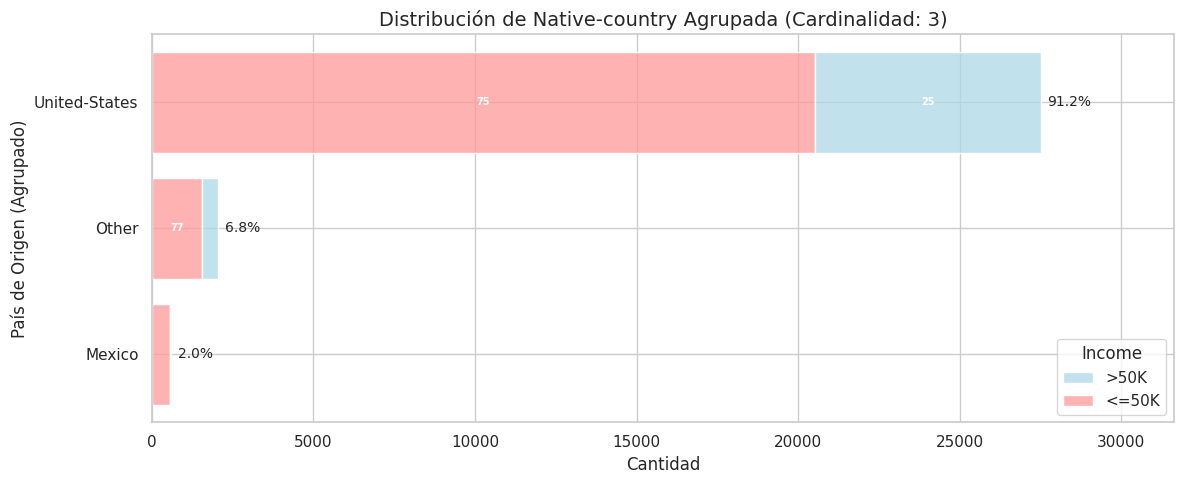

In [ ]:
# --- Visualización ---
cardinalidad_country_grouped = train['country_grouped'].nunique()
conteo_country_grouped = train['country_grouped'].value_counts()

fig, ax = plt.subplots(figsize=(12, 5))
# Ordenamos para el gráfico
train['country_grouped'] = pd.Categorical(train['country_grouped'], categories=conteo_country_grouped.index, ordered=True)

sns.histplot(data=train, y='country_grouped', hue='income', multiple='stack', ax=ax, palette=custom_palette, shrink=0.8, hue_order=['>50K', '<=50K'])
ax.set_title(f'Distribución de Native-country Agrupada (Cardinalidad: {cardinalidad_country_grouped})', fontsize=14)
ax.set_xlabel('Cantidad', fontsize=12)
ax.set_ylabel('País de Origen (Agrupado)', fontsize=12)

# Leyenda
sns.move_legend(ax, "lower right", title='Income')

# Porcentajes totales (externos)
ax.set_xlim(0, conteo_country_grouped.max() * 1.15)
total_len = len(train)
for i, width in enumerate(conteo_country_grouped):
    percentage = f'{100 * width / total_len:.1f}%'
    ax.annotate(percentage, (width, i), ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontsize=10)

# Etiquetas internas (% relativo a la categoría)
threshold = 0.02 * ax.get_xlim()[1]
for p in ax.patches:
    w = p.get_width()
    if w > threshold:
        y_center = p.get_y() + p.get_height() / 2
        idx = int(round(y_center))
        if idx < len(conteo_country_grouped):
            total_bar = conteo_country_grouped.iloc[idx]
            pct = 100 * w / total_bar
            ax.annotate(f'{pct:.0f}', (p.get_x() + w / 2, y_center), ha='center', va='center', color='white', fontsize=7, fontweight='bold')

# Restaurar tipo
train['country_grouped'] = train['country_grouped'].astype(object)
plt.tight_layout()
plt.show()

- OHE_COUNTRY_xxx

### Hours-per-week
Cantidad de horas trabajadas por semana (variable numérica).

Estadísticas descriptivas de la variable 'hours-per-week':


,hours-per-week
count,30162.000000
mean,40.931238
std,11.979984
min,1.000000
25%,40.000000
50%,40.000000
75%,45.000000
max,99.000000


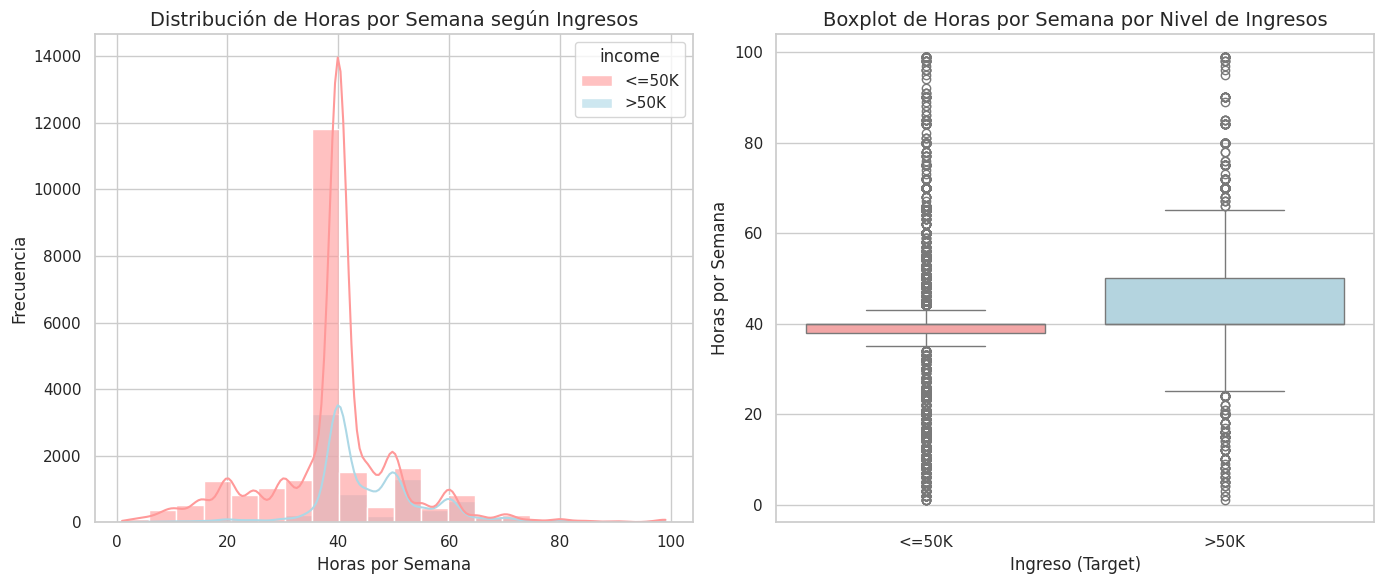

In [ ]:
# Mostrar estadísticas descriptivas de la variable 'hours-per-week'
print("Estadísticas descriptivas de la variable 'hours-per-week':")
display(train['hours-per-week'].describe())

# Configurar la figura con dos subgráficos
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Histograma superpuesto por clase (Income)
sns.histplot(data=train, x='hours-per-week', hue='income', bins=20, kde=True, ax=axes[0], palette=custom_palette, alpha=0.6)
axes[0].set_title('Distribución de Horas por Semana según Ingresos', fontsize=14)
axes[0].set_xlabel('Horas por Semana', fontsize=12)
axes[0].set_ylabel('Frecuencia', fontsize=12)

# 2. Boxplot de Horas por Semana por clase (Income)
sns.boxplot(data=train, x='income', y='hours-per-week', hue='income', ax=axes[1], palette=custom_palette, legend=False)
axes[1].set_title('Boxplot de Horas por Semana por Nivel de Ingresos', fontsize=14)
axes[1].set_xlabel('Ingreso (Target)', fontsize=12)
axes[1].set_ylabel('Horas por Semana', fontsize=12)

plt.tight_layout()
plt.show()

- Variable continua de baja dispersion
- La distribucion se centra en 40hs (la gente que trabja full time)
- La binerizamos y trabajamos como Ordinal, o la capeamos y trabajamos como continua

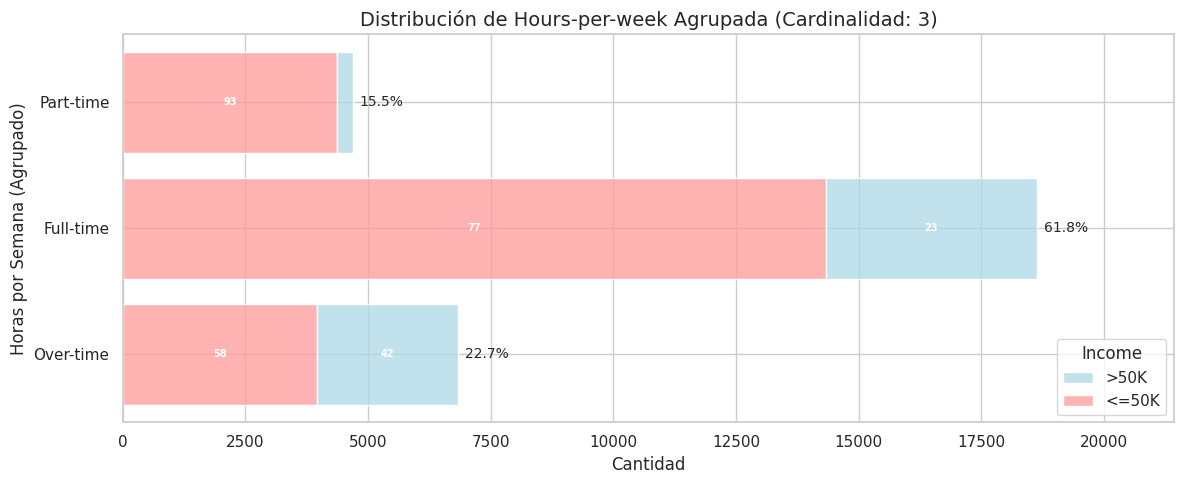

In [ ]:
# 9. Transformación Hours-per-week -> Binning manual

# Definimos los rangos: Part-time (<35), Full-time (35-45), Over-time (>45)
def bin_hours(h):
    if h < 35:
        return 'Part-time'
    elif 35 <= h <= 45:
        return 'Full-time'

    else:
        return 'Over-time'

train['hours_binned'] = train['hours-per-week'].apply(bin_hours)
test['hours_binned'] = test['hours-per-week'].apply(bin_hours)

# --- Visualización ---
cardinalidad_hours_binned = train['hours_binned'].nunique()
order_hours = ['Part-time', 'Full-time', 'Over-time']
conteo_hours_binned = train['hours_binned'].value_counts().reindex(order_hours)

fig, ax = plt.subplots(figsize=(12, 5))
# Ordenamos para el gráfico
train['hours_binned'] = pd.Categorical(train['hours_binned'], categories=order_hours, ordered=True)

sns.histplot(data=train, y='hours_binned', hue='income', multiple='stack', ax=ax, palette=custom_palette, shrink=0.8, hue_order=['>50K', '<=50K'])
ax.set_title(f'Distribución de Hours-per-week Agrupada (Cardinalidad: {cardinalidad_hours_binned})', fontsize=14)
ax.set_xlabel('Cantidad', fontsize=12)
ax.set_ylabel('Horas por Semana (Agrupado)', fontsize=12)

# Leyenda
sns.move_legend(ax, "lower right", title='Income')

# Porcentajes totales (externos)
ax.set_xlim(0, conteo_hours_binned.max() * 1.15)
total_len = len(train)
for i, width in enumerate(conteo_hours_binned):
    percentage = f'{100 * width / total_len:.1f}%'
    ax.annotate(percentage, (width, i), ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontsize=10)

# Etiquetas internas (% relativo a la categoría)
threshold = 0.02 * ax.get_xlim()[1]
for p in ax.patches:
    w = p.get_width()
    if w > threshold:
        y_center = p.get_y() + p.get_height() / 2
        idx = int(round(y_center))
        if idx < len(conteo_hours_binned):
            total_bar = conteo_hours_binned.iloc[idx]
            pct = 100 * w / total_bar
            ax.annotate(f'{pct:.0f}', (p.get_x() + w / 2, y_center), ha='center', va='center', color='white', fontsize=7, fontweight='bold')

# Restaurar tipo
train['hours_binned'] = train['hours_binned'].astype(object)
plt.tight_layout()
plt.show()


- Como era de esperar, se verificacomo la gente que trabaja mas horas tiene mejores salarios a nivel nominal

In [ ]:
# Aplicamos Ordinal Encoding manteniendo el orden lógico

# Definimos el orden explícito: Part-time (0) < Full-time (1) < Over-time (2)
hours_categories = [['Part-time', 'Full-time', 'Over-time']]
encoder_hours = OrdinalEncoder(categories=hours_categories)

ORD_hours_train = pd.Series(
    encoder_hours.fit_transform(train[['hours_binned']]).flatten(),
    index=train.index,
    name='ORD_hours_per_week'
)

ORD_hours_test = pd.Series(
    encoder_hours.transform(test[['hours_binned']]).flatten(),
    index=test.index,
    name='ORD_hours_per_week'
)

# Agregamos a las listas de variables transformadas
variables_transformadas_train.append(ORD_hours_train)
variables_transformadas_test.append(ORD_hours_test)


- ORD_hours_per_week

In [ ]:
# Transformación alterna para Hours-per-week -> OHE_hours
ohe_hours = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

hours_ohe_train_raw = ohe_hours.fit_transform(train[['hours_binned']])
hours_ohe_test_raw = ohe_hours.transform(test[['hours_binned']])

columns_ohe_hours = [f"OHE_HOURS_PER_WEEK_{cat.replace('-', '_')}" for cat in ohe_hours.categories_[0]]

OHE_hours_train = pd.DataFrame(hours_ohe_train_raw, columns=columns_ohe_hours, index=train.index)
OHE_hours_test = pd.DataFrame(hours_ohe_test_raw, columns=columns_ohe_hours, index=test.index)

# Agregamos a las listas de variables transformadas
variables_transformadas_train.append(OHE_hours_train)
variables_transformadas_test.append(OHE_hours_test)


- OHE_HOURS_PER_WEEK_xxx

### Capital-gain
Ingresos obtenidos por ganancia de capital (por ejemplo, venta de acciones o propiedades).

,capital-gain
count,30162.000000
mean,1092.007858
std,7406.346497
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,99999.000000



Cantidad de registros con capital-gain igual a 0: 27624
Porcentaje de registros con capital-gain igual a 0: 91.59%



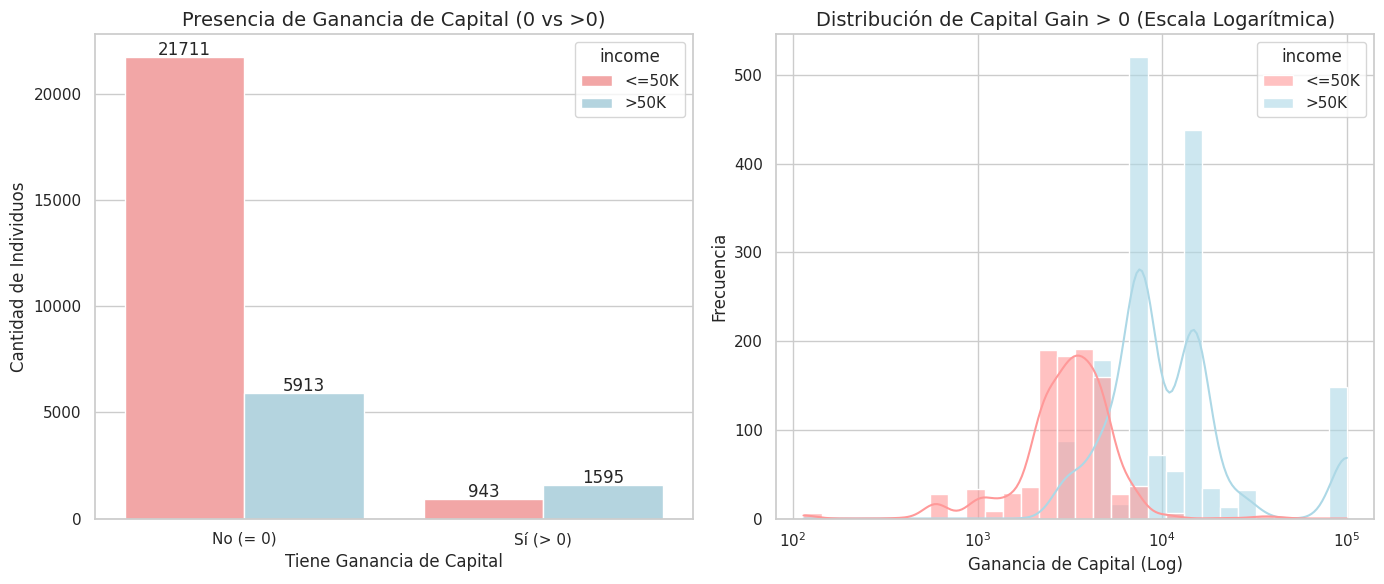

In [ ]:
display(train['capital-gain'].describe())

zeros_count = (train['capital-gain'] == 0).sum()
total_count = len(train)
zeros_pct = (zeros_count / total_count) * 100

print(f"\nCantidad de registros con capital-gain igual a 0: {zeros_count}")
print(f"Porcentaje de registros con capital-gain igual a 0: {zeros_pct:.2f}%\n")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

train['has_capital_gain'] = train['capital-gain'] > 0

# 1. Countplot de Ceros vs No Ceros
sns.countplot(data=train, x='has_capital_gain', hue='income', ax=axes[0], palette=custom_palette)
axes[0].set_title('Presencia de Ganancia de Capital (0 vs >0)', fontsize=14)
axes[0].set_xlabel('Tiene Ganancia de Capital', fontsize=12)
axes[0].set_ylabel('Cantidad de Individuos', fontsize=12)
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['No (= 0)', 'Sí (> 0)'])

# Agregar valores exactos sobre las barras del countplot
for p in axes[0].patches:
    height = p.get_height()
    if height > 0:
        axes[0].annotate(f'{int(height)}', (p.get_x() + p.get_width() / 2., height),
                         ha='center', va='center', xytext=(0, 5), textcoords='offset points')

# 2. Distribución de las ganancias > 0 (Escala Logarítmica)
non_zero_gains = train[train['capital-gain'] > 0]
sns.histplot(data=non_zero_gains, x='capital-gain', hue='income', bins=30, kde=True, ax=axes[1], palette=custom_palette, alpha=0.6, log_scale=True)
axes[1].set_title('Distribución de Capital Gain > 0 (Escala Logarítmica)', fontsize=14)
axes[1].set_xlabel('Ganancia de Capital (Log)', fontsize=12)
axes[1].set_ylabel('Frecuencia', fontsize=12)

plt.tight_layout()
plt.show()

train = train.drop(columns=['has_capital_gain'])

- Variable Continua
- 92% de los registros tienen valor de 0
- Para los que reportan algo de Capital Gain, la proporcion de registros con Ingresos altos se considerablemente mayor contra los que no reportan
- Distribucion muy sezgada hacia la derecha, aplicamos Log Transform y luego Escalamos

In [ ]:
# 1. Crear indicador binario con el nombre solicitado
BOOL_has_capital_gain_train = (train['capital-gain'] > 0).astype(int)
BOOL_has_capital_gain_test = (test['capital-gain'] > 0).astype(int)

BOOL_has_capital_gain_train.name = 'BOOL_has_capital_gain'
BOOL_has_capital_gain_test.name = 'BOOL_has_capital_gain'

# 2. Transformación Logarítmica para manejar el sesgo extremo
log_gain_train = np.log1p(train[['capital-gain']])
log_gain_test = np.log1p(test[['capital-gain']])

# 3. Escalado de la magnitud logarítmica para la red neuronal
scaler_gain = MinMaxScaler()

LOG_capital_gain_train = pd.Series(
    scaler_gain.fit_transform(log_gain_train).flatten(),
    index=train.index,
    name='LOG_capital_gain'
)

LOG_capital_gain_test = pd.Series(
    scaler_gain.transform(log_gain_test).flatten(),
    index=test.index,
    name='LOG_capital_gain'
)

# Agregamos a las listas de variables transformadas
variables_transformadas_train.append(BOOL_has_capital_gain_train)
variables_transformadas_test.append(BOOL_has_capital_gain_test)

variables_transformadas_train.append(LOG_capital_gain_train)
variables_transformadas_test.append(LOG_capital_gain_test)

display(LOG_capital_gain_train.describe())


,LOG_capital_gain
count,30162.000000
mean,0.064592
std,0.214586
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,1.000000


- Creamos BOOL_has_capital_gain como Booleana, para que ayude en el entrenamiento del modelo
- Creamos LOG_capital_gain que seria la variable orignal transofmrada dos veces

### Capital-loss
Pérdidas declaradas por capital.


Cantidad de registros con capital-loss igual a 0: 28735
Porcentaje de registros con capital-loss igual a 0: 95.27%



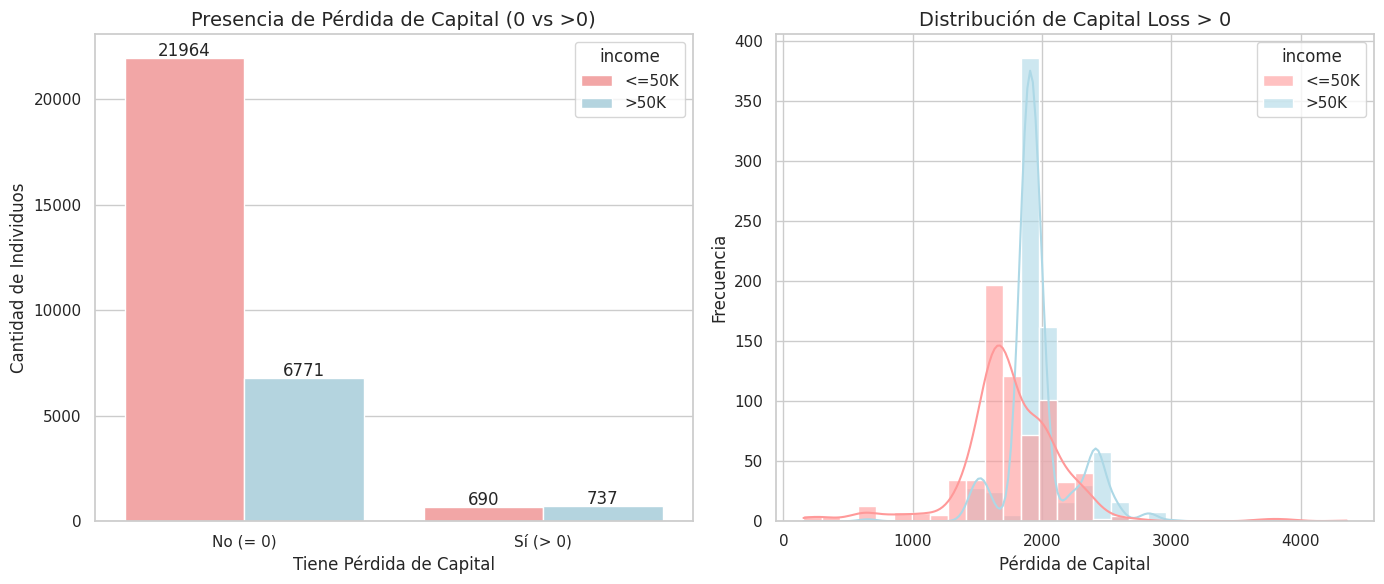

In [ ]:
zeros_loss_count = (train['capital-loss'] == 0).sum()
total_count = len(train)
zeros_loss_pct = (zeros_loss_count / total_count) * 100

print(f"\nCantidad de registros con capital-loss igual a 0: {zeros_loss_count}")
print(f"Porcentaje de registros con capital-loss igual a 0: {zeros_loss_pct:.2f}%\n")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

train['has_capital_loss'] = train['capital-loss'] > 0

# 1. Countplot de Ceros vs No Ceros
sns.countplot(data=train, x='has_capital_loss', hue='income', ax=axes[0], palette=custom_palette)
axes[0].set_title('Presencia de Pérdida de Capital (0 vs >0)', fontsize=14)
axes[0].set_xlabel('Tiene Pérdida de Capital', fontsize=12)
axes[0].set_ylabel('Cantidad de Individuos', fontsize=12)
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['No (= 0)', 'Sí (> 0)'])

# Agregar valores exactos sobre las barras del countplot
for p in axes[0].patches:
    height = p.get_height()
    if height > 0:
        axes[0].annotate(f'{int(height)}', (p.get_x() + p.get_width() / 2., height),
                         ha='center', va='center', xytext=(0, 5), textcoords='offset points')

# 2. Distribución de las pérdidas > 0 (Magnitud Original)
non_zero_losses = train[train['capital-loss'] > 0]
sns.histplot(data=non_zero_losses, x='capital-loss', hue='income', bins=30, kde=True, ax=axes[1], palette=custom_palette, alpha=0.6)
axes[1].set_title('Distribución de Capital Loss > 0', fontsize=14)
axes[1].set_xlabel('Pérdida de Capital', fontsize=12)
axes[1].set_ylabel('Frecuencia', fontsize=12)

plt.tight_layout()
plt.show()

train = train.drop(columns=['has_capital_loss'])


- Tambien Continua, con 95% de registros en 0
- Aqui las proporciones de los que tienen Ingresos altos e Ingresos bajos es casi igual, a diferencia como pasaba en Captial-Gain
- Tambien con mucho sezgo hacia la cola derecha, aplicamos Log Transform y leugo MinMax Scaler

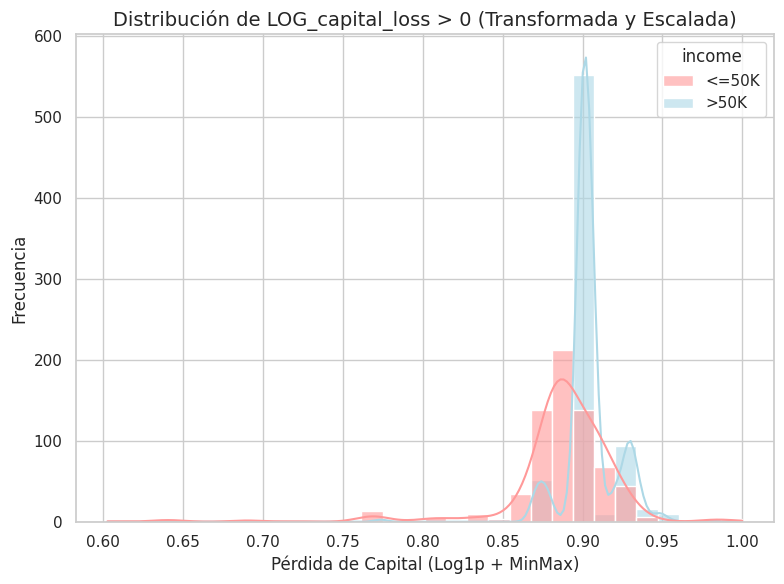

In [ ]:
# 1. Crear indicador binario para pérdidas
BOOL_has_capital_loss_train = (train['capital-loss'] > 0).astype(int)
BOOL_has_capital_loss_test = (test['capital-loss'] > 0).astype(int)

BOOL_has_capital_loss_train.name = 'BOOL_has_capital_loss'
BOOL_has_capital_loss_test.name = 'BOOL_has_capital_loss'

# 2. Transformación Logarítmica para manejar el sesgo extremo
log_loss_train = np.log1p(train[['capital-loss']])
log_loss_test = np.log1p(test[['capital-loss']])

# 3. Escalado MinMax de la magnitud logarítmica
scaler_loss = MinMaxScaler()

LOG_capital_loss_train = pd.Series(
    scaler_loss.fit_transform(log_loss_train).flatten(),
    index=train.index,
    name='LOG_capital_loss'
)

LOG_capital_loss_test = pd.Series(
    scaler_loss.transform(log_loss_test).flatten(),
    index=test.index,
    name='LOG_capital_loss'
)

# Agregamos a las listas de variables transformadas
variables_transformadas_train.append(BOOL_has_capital_loss_train)
variables_transformadas_test.append(BOOL_has_capital_loss_test)

variables_transformadas_train.append(LOG_capital_loss_train)
variables_transformadas_test.append(LOG_capital_loss_test)

# 4. Visualización de la variable transformada
temp_df = pd.DataFrame({
    'LOG_capital_loss': LOG_capital_loss_train,
    'income': train['income']
})

# Filtramos los ceros para ver la distribución de los valores reales transformados
transformed_non_zero = temp_df[temp_df['LOG_capital_loss'] > 0]

fig, ax = plt.subplots(figsize=(8, 6))
sns.histplot(data=transformed_non_zero, x='LOG_capital_loss', hue='income', bins=30, kde=True, palette=custom_palette, alpha=0.6, ax=ax)
ax.set_title('Distribución de LOG_capital_loss > 0 (Transformada y Escalada)', fontsize=14)
ax.set_xlabel('Pérdida de Capital (Log1p + MinMax)', fontsize=12)
ax.set_ylabel('Frecuencia', fontsize=12)

plt.tight_layout()
plt.show()


- Analogo a como hicimos con Capital Gain, creamos BOOL_has_capital_loss como Booleana, para que ayude en el entrenamiento del modelo
- Creamos LOG_capital_loss que seria la variable orignal transofmrada dos veces

### Consolidación Final de Variables


In [ ]:
# Creación de los DataFrames finales X_train y X_test concatenando las listas de consolidación
X_train = pd.concat(variables_transformadas_train, axis=1)
X_test = pd.concat(variables_transformadas_test, axis=1)

# Asignación de la variable objetivo
y_train = BOOL_Income_train
y_test = BOOL_Income_test

# Verificación de dimensiones y visualización
print(f"Dimensiones de X_train: {X_train.shape}")
print(f"Dimensiones de X_test: {X_test.shape}")
print(f"Total de features: {X_train.shape[1]}")
display(X_train.head())


Dimensiones de X_train: (30162, 41)
Dimensiones de X_test: (15060, 41)
Total de features: 41


,SCA_age,OHE_WORKCLASS_Federal-gov,OHE_WORKCLASS_Local-gov,OHE_WORKCLASS_Private,OHE_WORKCLASS_Self-emp-inc,OHE_WORKCLASS_Self-emp-not-inc,OHE_WORKCLASS_State-gov,OHE_WORKCLASS_Without-pay,ORD_education,OHE_MARITAL_STATUS_Divorced,OHE_MARITAL_STATUS_Married_AF_spouse,OHE_MARITAL_STATUS_Married_civ_spouse,OHE_MARITAL_STATUS_Married_spouse_absent,OHE_MARITAL_STATUS_Never_married,OHE_MARITAL_STATUS_Separated,OHE_MARITAL_STATUS_Widowed,FRQ_Occupation,TAR_Occupation,OHE_RELATIONSHIP_Husband,OHE_RELATIONSHIP_Not_in_family,OHE_RELATIONSHIP_Other_relative,OHE_RELATIONSHIP_Own_child,OHE_RELATIONSHIP_Unmarried,OHE_RELATIONSHIP_Wife,OHE_RACE_Black,OHE_RACE_Other,OHE_RACE_White,BOOL_is_men,FRQ_skill_profile,TAR_skill_profile,OHE_COUNTRY_Mexico,OHE_COUNTRY_Other,OHE_COUNTRY_United_States,ORD_hours_per_week,OHE_HOURS_PER_WEEK_Full_time,OHE_HOURS_PER_WEEK_Over_time,OHE_HOURS_PER_WEEK_Part_time,BOOL_has_capital_gain,LOG_capital_gain,BOOL_has_capital_loss,LOG_capital_loss
0,0.400000,0.0,0.0,0.0,0.0,0.0,1.0,0.0,5,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.123367,0.133835,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1,0.048936,0.084688,0.0,0.0,1.0,1.0,1.0,0.0,0.0,1,0.667492,0,0.0
1,0.600000,0.0,0.0,0.0,0.0,1.0,0.0,0.0,5,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.132352,0.485220,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1,0.009548,0.614583,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0,0.000000,0,0.0
2,0.381818,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.044758,0.061481,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1,0.054307,0.028694,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0,0.000000,0,0.0
3,0.654545,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.044758,0.061481,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1,0.033851,0.077375,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0,0.000000,0,0.0
4,0.200000,0.0,0.0,1.0,0.0,0.0,0.0,0.0,5,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.133877,0.448489,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0,0.005338,0.881988,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0,0.000000,0,0.0


#### Dropeo de variables correlacionadas


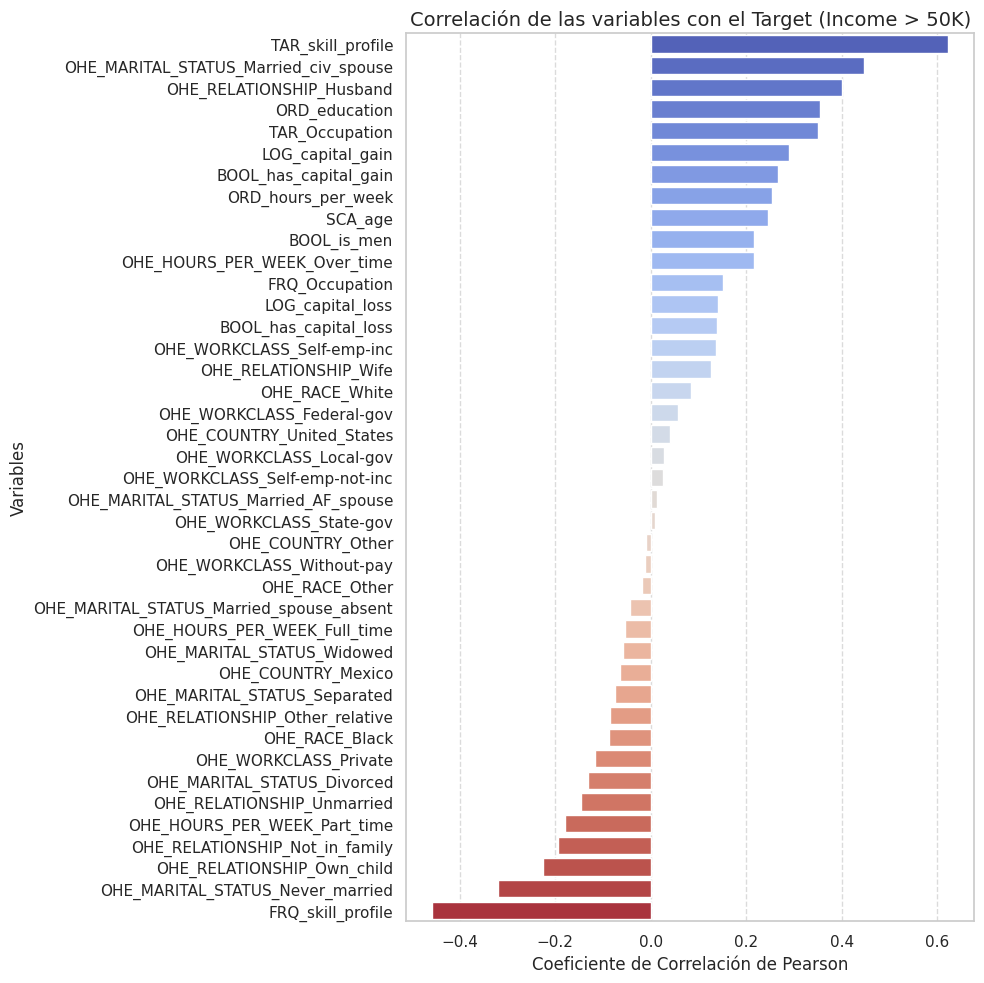

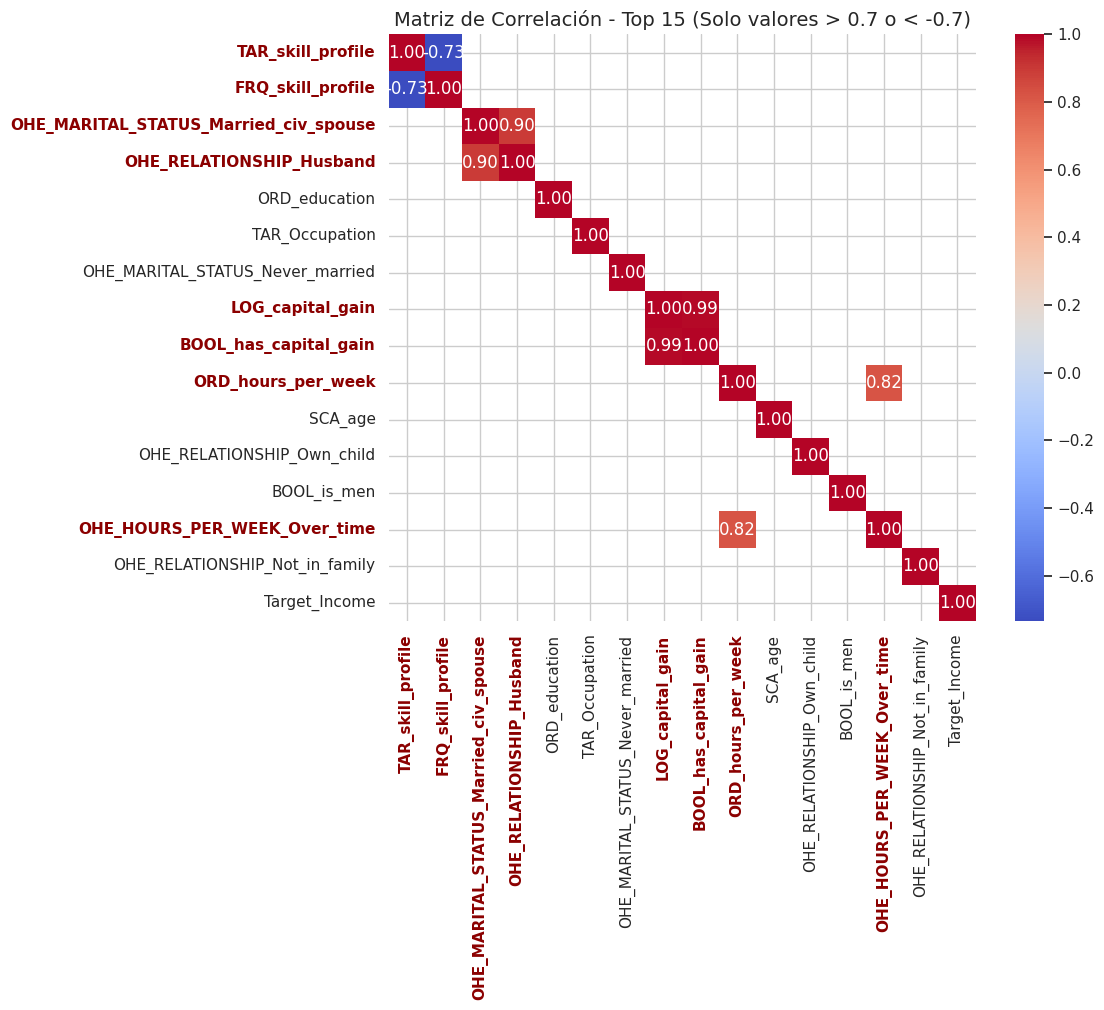

In [ ]:
# 1. Unir X_train y y_train temporalmente para calcular la correlación
df_corr = X_train.copy()
df_corr['Target_Income'] = y_train

# Calcular la matriz de correlación de Pearson
corr_matrix = df_corr.corr()

# 2. Extraer la correlación de todas las variables con respecto al Target
target_corr = corr_matrix['Target_Income'].drop('Target_Income').sort_values(ascending=False)

# Graficar la correlación con el Target
plt.figure(figsize=(10, 10))
sns.barplot(x=target_corr.values, y=target_corr.index, palette='coolwarm', hue=target_corr.index, legend=False)
plt.title('Correlación de las variables con el Target (Income > 50K)', fontsize=14)
plt.xlabel('Coeficiente de Correlación de Pearson', fontsize=12)
plt.ylabel('Variables', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 3. Heatmap de correlación entre las top 15 variables más correlacionadas (en valor absoluto)
top_features = target_corr.abs().sort_values(ascending=False).head(15).index.tolist()
top_features.append('Target_Income') # Agregamos el target al final para el mapa

# Matriz de correlación reducida
corr_matrix_top = df_corr[top_features].corr()

# Crear máscara para ocultar correlaciones débiles (entre -0.7 y 0.7)
mask = (corr_matrix_top > -0.7) & (corr_matrix_top < 0.7)

# Identificar qué variables tienen al menos una correlación visible (excluyendo la diagonal)
mask_for_check = mask.copy()
np.fill_diagonal(mask_for_check.values, True) # Ignorar la diagonal
active_features = ~mask_for_check.all()

plt.figure(figsize=(12, 10))
ax = sns.heatmap(corr_matrix_top, annot=True, fmt=".2f", cmap='coolwarm', cbar=True, square=True, mask=mask)
plt.title('Matriz de Correlación - Top 15 (Solo valores > 0.7 o < -0.7)', fontsize=14)

# Resaltar en rojo y negrita las etiquetas de las filas/columnas encendidas
for i, feature in enumerate(corr_matrix_top.columns):
    if active_features[feature]:
        ax.get_xticklabels()[i].set_color('darkred')
        ax.get_xticklabels()[i].set_weight('bold')
        ax.get_yticklabels()[i].set_color('darkred')
        ax.get_yticklabels()[i].set_weight('bold')

plt.tight_layout()
plt.show()


In [ ]:
# Dropeo variables altamente correlacionadas

to_drop = [
    "FRQ_skill_profile",
    "OHE_RELATIONSHIP_Husband",
    "BOOL_has_capital_gain",
    "BOOL_has_capital_loss",
    "OHE_HOURS_PER_WEEK_Part_time",
    "OHE_HOURS_PER_WEEK_Over_time"
]

X_train = X_train.drop(columns=to_drop)
X_test = X_test.drop(columns=to_drop)

## b) Diseño y entrenamiento de un modelo con embeddings (3 puntos)

- Implementar las transformaciones definidas en el punto anterior e incorporarlas al flujo de entrenamiento.
- El modelo debe incluir, como mínimo, una capa de embedding para representar alguna de las variables categóricas.
- La elección de la dimensión del o los embeddings queda a criterio del estudiante, pero debe estar correctamente fundamentada. Recuerden que no es obligatorio que todos los embeddings tengan la misma dimensión.
- La configuración arquitectónica (número de capas, neuronas por capa, función de activación) es de libre elección.
- Incluir dropout en las capas ocultas de la red.
- Utilizar Adam o alguna de sus variantes como optimizador.
- Seleccionar la función de costo apropiada entre Binary CrossEntropyLoss o Categorical CrossEntropyLoss, según la formulación del problema.
- Mostrar las curvas de accuracy vs epoch y F1 macro vs epoch para los sets de entrenamiento y validación.
- Presentar un classification report generado con sklearn.
- Presentar una matriz de confusión absoluta y otra normalizada por fila, correspondientes al set de validación, con una paleta de colores entendible.

### Baseline PyTorch (Red Neuronal sin Embeddings)
Aquí definimos una red neuronal estándar (MLP) utilizando únicamente los features numéricos y categóricos pre-procesados en las secciones anteriores (One-Hot, Ordinal, Target/Freq Encoding).

In [ ]:
print(X_train.shape)
X_train.columns

(30162, 35)


Index(['SCA_age', 'OHE_WORKCLASS_Federal-gov', 'OHE_WORKCLASS_Local-gov', 'OHE_WORKCLASS_Private', 'OHE_WORKCLASS_Self-emp-inc', 'OHE_WORKCLASS_Self-emp-not-inc', 'OHE_WORKCLASS_State-gov', 'OHE_WORKCLASS_Without-pay', 'ORD_education', 'OHE_MARITAL_STATUS_Divorced', 'OHE_MARITAL_STATUS_Married_AF_spouse', 'OHE_MARITAL_STATUS_Married_civ_spouse', 'OHE_MARITAL_STATUS_Married_spouse_absent', 'OHE_MARITAL_STATUS_Never_married', 'OHE_MARITAL_STATUS_Separated', 'OHE_MARITAL_STATUS_Widowed', 'FRQ_Occupation', 'TAR_Occupation', 'OHE_RELATIONSHIP_Not_in_family', 'OHE_RELATIONSHIP_Other_relative', 'OHE_RELATIONSHIP_Own_child', 'OHE_RELATIONSHIP_Unmarried', 'OHE_RELATIONSHIP_Wife', 'OHE_RACE_Black', 'OHE_RACE_Other', 'OHE_RACE_White', 'BOOL_is_men', 'TAR_skill_profile', 'OHE_COUNTRY_Mexico', 'OHE_COUNTRY_Other', 'OHE_COUNTRY_United_States', 'ORD_hours_per_week', 'OHE_HOURS_PER_WEEK_Full_time', 'LOG_capital_gain', 'LOG_capital_loss'], dtype='object')

In [ ]:
# 1. Convertir los datos a tensores de PyTorch
X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)

X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

# 2. Crear DataLoaders para manejar los lotes (batches)
batch_size = 64

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Tamaño del lote: {batch_size}")
print(f"Cantidad de batches en train: {len(train_loader)}")
print(f"Features de entrada: {X_train.shape[1]}")


Tamaño del lote: 64
Cantidad de batches en train: 472
Features de entrada: 35


In [ ]:
# 1. Separar un conjunto de validación del de entrenamiento (80% train, 20% val)
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X_train_tensor, y_train_tensor, test_size=0.2, random_state=42, stratify=y_train_tensor
)

print(f"Tamaño de Train (Split): {X_train_split.shape[0]}")
print(f"Tamaño de Validación: {X_val_split.shape[0]}")
print(f"Tamaño de Test (Intacto): {X_test_tensor.shape[0]}")

# 2. Actualizar los DataLoaders
batch_size = 64

train_dataset_split = TensorDataset(X_train_split, y_train_split)
train_loader_split = DataLoader(train_dataset_split, batch_size=batch_size, shuffle=True)

val_dataset_split = TensorDataset(X_val_split, y_val_split)
val_loader_split = DataLoader(val_dataset_split, batch_size=batch_size, shuffle=False)

# test_loader ya estaba creado y no se modifica


Tamaño de Train (Split): 24129
Tamaño de Validación: 6033
Tamaño de Test (Intacto): 15060


In [ ]:
# 3. Definir la arquitectura del Baseline (MLP) paramétrica para búsqueda manual
class BaselineNN(nn.Module):
    def __init__(self, input_dim, hidden_layers=[64, 32], dropout_rate=0.3):
        super(BaselineNN, self).__init__()
        layers = []

        current_dim = input_dim
        for hidden_dim in hidden_layers:
            layers.append(nn.Linear(current_dim, hidden_dim))
            layers.append(nn.ReLU())
            if dropout_rate > 0:
                layers.append(nn.Dropout(dropout_rate))
            current_dim = hidden_dim

        # Capa de salida final (logits para BCEWithLogitsLoss)
        layers.append(nn.Linear(current_dim, 1))

        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

input_dim = X_train_tensor.shape[1]

# --- PARÁMETROS PARA OPTIMIZACIÓN MANUAL ---
# Modifica estos valores, vuelve a correr esta celda y la del entrenamiento para comparar
config_capas_ocultas = [16, 16]
tasa_dropout = 0.3

model_baseline = BaselineNN(input_dim, hidden_layers=config_capas_ocultas, dropout_rate=tasa_dropout)
print(model_baseline)


BaselineNN(
  (network): Sequential(
    (0): Linear(in_features=35, out_features=16, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=16, out_features=16, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=16, out_features=1, bias=True)
  )
)


In [ ]:
# 4. Configurar Loss y Optimizador con learning rate más chico
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model_baseline.parameters(), lr=0.0001)

# 5. Ciclo de Entrenamiento con Early Stopping (usando el set de validación)
epochs = 1000
patience = 15
best_val_loss = float('inf')
epochs_no_improve = 0
best_model_wts = copy.deepcopy(model_baseline.state_dict())

# Variables para guardar las métricas de la mejor época
best_epoch = 0
best_train_loss = 0.0
best_train_f1 = 0.0
best_val_f1 = 0.0

train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []
train_f1_macros, val_f1_macros = [], []

print("Iniciando entrenamiento del Baseline NN con set de validación...")
for epoch in range(epochs):
    # --- TRAIN ---
    model_baseline.train()
    batch_losses = []
    correct_train = 0
    total_train = 0
    all_preds_train = []
    all_labels_train = []

    for X_batch, y_batch in train_loader_split:
        optimizer.zero_grad()
        outputs = model_baseline(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        batch_losses.append(loss.item())

        preds = (torch.sigmoid(outputs) >= 0.5).float()
        correct_train += (preds == y_batch).sum().item()
        total_train += y_batch.size(0)

        all_preds_train.extend(preds.cpu().numpy())
        all_labels_train.extend(y_batch.cpu().numpy())

    train_losses.append(np.mean(batch_losses))
    train_accuracies.append(correct_train / total_train)
    train_f1_macros.append(f1_score(all_labels_train, all_preds_train, average='macro'))

    # --- VALIDATION ---
    model_baseline.eval()
    batch_losses_val = []
    correct_val = 0
    total_val = 0
    all_preds_val = []
    all_labels_val = []

    with torch.no_grad():
        for X_batch, y_batch in val_loader_split:
            outputs = model_baseline(X_batch)
            loss = criterion(outputs, y_batch)
            batch_losses_val.append(loss.item())

            preds = (torch.sigmoid(outputs) >= 0.5).float()
            correct_val += (preds == y_batch).sum().item()
            total_val += y_batch.size(0)

            all_preds_val.extend(preds.cpu().numpy())
            all_labels_val.extend(y_batch.cpu().numpy())

    current_val_loss = np.mean(batch_losses_val)
    val_losses.append(current_val_loss)
    val_accuracies.append(correct_val / total_val)
    val_f1_macros.append(f1_score(all_labels_val, all_preds_val, average='macro'))

    # --- EARLY STOPPING CHECK ---
    if current_val_loss < best_val_loss:
        best_val_loss = current_val_loss
        best_model_wts = copy.deepcopy(model_baseline.state_dict())
        epochs_no_improve = 0

        # Guardamos los valores de esta mejor época
        best_epoch = epoch + 1
        best_train_loss = train_losses[-1]
        best_train_f1 = train_f1_macros[-1]
        best_val_f1 = val_f1_macros[-1]
    else:
        epochs_no_improve += 1

    if (epoch + 1) % 5 == 0 or epoch == 0 or epochs_no_improve >= patience:
        print(f"Epoch {epoch+1:03d}/{epochs} | Train Loss: {train_losses[-1]:.4f} - F1: {train_f1_macros[-1]:.4f} | Val Loss: {val_losses[-1]:.4f} - F1: {val_f1_macros[-1]:.4f}")

    if epochs_no_improve >= patience:
        print(f"\nEarly stopping disparado en la época {epoch+1}.")
        print(f"Restaurando los pesos de la época {best_epoch} -> Train Loss: {best_train_loss:.4f} - F1: {best_train_f1:.4f} | Val Loss: {best_val_loss:.4f} - F1: {best_val_f1:.4f}")
        model_baseline.load_state_dict(best_model_wts)
        break


Iniciando entrenamiento del Baseline NN con set de validación...
Epoch 001/1000 | Train Loss: 0.6700 - F1: 0.4988 | Val Loss: 0.6137 - F1: 0.4289
Epoch 005/1000 | Train Loss: 0.4261 - F1: 0.6346 | Val Loss: 0.3849 - F1: 0.7332
Epoch 010/1000 | Train Loss: 0.3508 - F1: 0.7744 | Val Loss: 0.3214 - F1: 0.8042
Epoch 015/1000 | Train Loss: 0.3269 - F1: 0.8067 | Val Loss: 0.2972 - F1: 0.8204
Epoch 020/1000 | Train Loss: 0.3116 - F1: 0.8246 | Val Loss: 0.2871 - F1: 0.8266
Epoch 025/1000 | Train Loss: 0.3012 - F1: 0.8307 | Val Loss: 0.2807 - F1: 0.8352
Epoch 030/1000 | Train Loss: 0.2997 - F1: 0.8340 | Val Loss: 0.2785 - F1: 0.8366
Epoch 035/1000 | Train Loss: 0.2921 - F1: 0.8346 | Val Loss: 0.2764 - F1: 0.8399
Epoch 040/1000 | Train Loss: 0.2916 - F1: 0.8389 | Val Loss: 0.2754 - F1: 0.8390
Epoch 045/1000 | Train Loss: 0.2895 - F1: 0.8369 | Val Loss: 0.2741 - F1: 0.8396
Epoch 050/1000 | Train Loss: 0.2893 - F1: 0.8411 | Val Loss: 0.2737 - F1: 0.8388
Epoch 055/1000 | Train Loss: 0.2852 - F1: 0.

- BCEWithLogitsLoss porque es un problema de Clasificacion Binaria

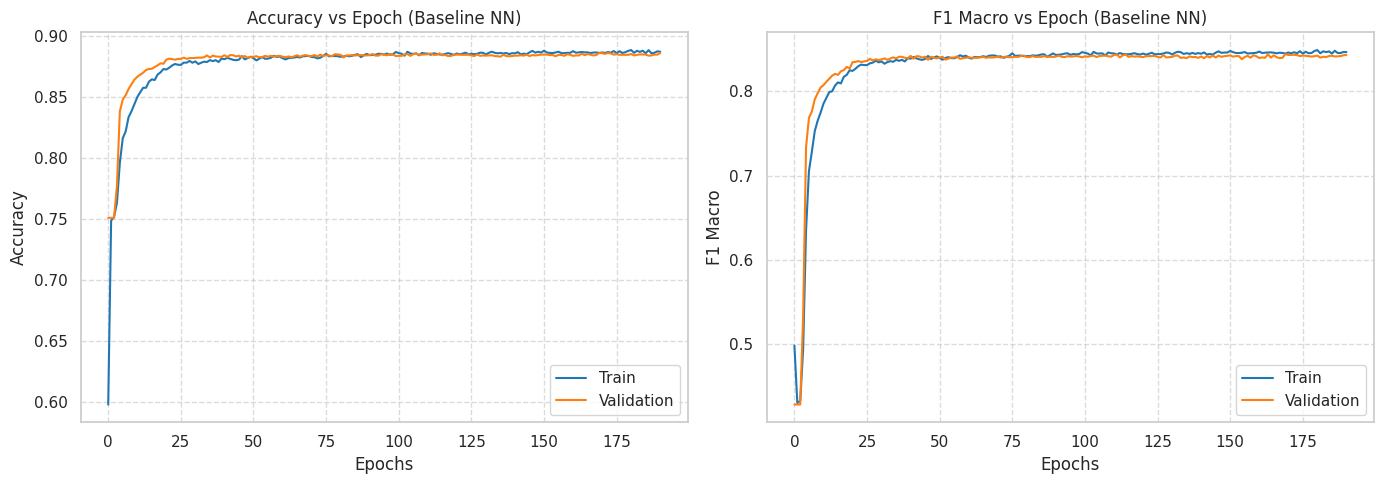

In [ ]:
# 6. Graficar las curvas de entrenamiento: Accuracy y F1 Macro
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Definir colores consistentes
color_train = '#1f77b4'  # Azul
color_val = '#ff7f0e'    # Naranja

# Accuracy vs Epoch
axes[0].plot(train_accuracies, label='Train', color=color_train)
axes[0].plot(val_accuracies, label='Validation', color=color_val)
axes[0].set_title('Accuracy vs Epoch (Baseline NN)')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.7)

# F1 Macro vs Epoch
axes[1].plot(train_f1_macros, label='Train', color=color_train)
axes[1].plot(val_f1_macros, label='Validation', color=color_val)
axes[1].set_title('F1 Macro vs Epoch (Baseline NN)')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('F1 Macro')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

--- Classification Report (Set de Validación) ---
              precision    recall  f1-score   support

       <=50K       0.91      0.94      0.92      4531
        >50K       0.80      0.73      0.76      1502

    accuracy                           0.89      6033
   macro avg       0.85      0.83      0.84      6033
weighted avg       0.88      0.89      0.88      6033



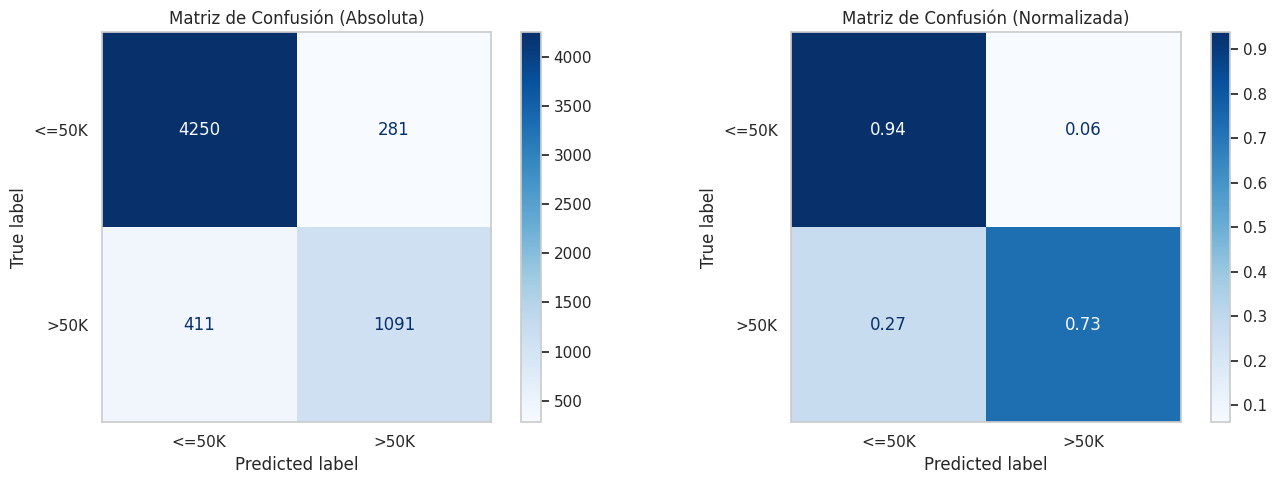

In [ ]:
# 7. Evaluación final en el set de Validación
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Asegurarnos de que el modelo esté en modo evaluación
model_baseline.eval()
all_preds_val_final = []
all_labels_val_final = []

with torch.no_grad():
    for X_batch, y_batch in val_loader_split:
        outputs = model_baseline(X_batch)
        preds = (torch.sigmoid(outputs) >= 0.5).float()
        all_preds_val_final.extend(preds.cpu().numpy())
        all_labels_val_final.extend(y_batch.cpu().numpy())

print("--- Classification Report (Set de Validación) ---")
print(classification_report(all_labels_val_final, all_preds_val_final, target_names=['<=50K', '>50K']))

# Generar matrices de confusión
cm_abs = confusion_matrix(all_labels_val_final, all_preds_val_final)
cm_norm = confusion_matrix(all_labels_val_final, all_preds_val_final, normalize='true')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de Confusión Absoluta
disp_abs = ConfusionMatrixDisplay(confusion_matrix=cm_abs, display_labels=['<=50K', '>50K'])
disp_abs.plot(cmap='Blues', ax=axes[0], values_format='d')
axes[0].set_title('Matriz de Confusión (Absoluta)')
axes[0].grid(False)

# Matriz de Confusión Normalizada por fila
disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=['<=50K', '>50K'])
disp_norm.plot(cmap='Blues', ax=axes[1], values_format='.2f')
axes[1].set_title('Matriz de Confusión (Normalizada)')
axes[1].grid(False)

plt.tight_layout()
plt.show()

- [128, 128, 128]: Accuracy 0.89 | F1 0.84
- [64, 64, 64]: Accuracy 0.88 | F1 0.84
- [64, 32, 16]: Accuracy 0.88 | F1 0.84
- [64, 64]: Accuracy 0.88 | F1 0.84
- [16, 16]: Accuracy 0.89 | F1 0.84 --> Arquitectura elegida N#1
- [128]: Accuracy 0.88 | F1 0.84
- [64]: Accuracy 0.88 | F1 0.84
- [32]: Accuracy 0.88 | F1 0.84
- [16]: Accuracy 0.88 | F1 0.84
- [8]: Accuracy 0.88 | F1 0.84 | Demoro mas en converger
- [4]: Accuracy 0.88 | F1 0.83
- [2]: Accuracy 0.88 | F1 0.82
- [4, 4]: Accuracy 0.88 | F1 0.84

### Evaluación del Baseline NN en el Set de Test
Ahora evaluamos el modelo final utilizando el conjunto de datos de prueba (`test_loader`) que nunca fue visto durante el entrenamiento o la validación.

--- Classification Report (Set de TEST) ---
              precision    recall  f1-score   support

       <=50K       0.91      0.94      0.93     11360
        >50K       0.80      0.72      0.76      3700

    accuracy                           0.89     15060
   macro avg       0.86      0.83      0.84     15060
weighted avg       0.89      0.89      0.89     15060



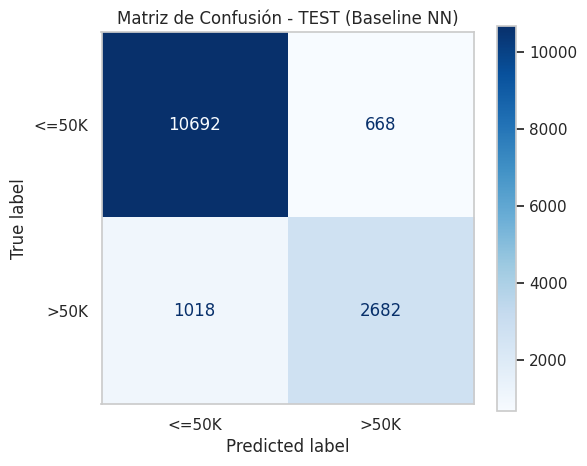

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Asegurarnos de que el modelo esté en modo evaluación
model_baseline.eval()
all_preds_test = []
all_labels_test = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        outputs = model_baseline(X_batch)
        # Aplicar sigmoide y umbral de 0.5 para la clasificación binaria
        preds = (torch.sigmoid(outputs) >= 0.5).float()

        all_preds_test.extend(preds.cpu().numpy())
        all_labels_test.extend(y_batch.cpu().numpy())

print("--- Classification Report (Set de TEST) ---")
print(classification_report(all_labels_test, all_preds_test, target_names=['<=50K', '>50K']))

# Matriz de Confusión Absoluta para Test
cm_abs_test = confusion_matrix(all_labels_test, all_preds_test)
fig, ax = plt.subplots(figsize=(6, 5))
disp_abs_test = ConfusionMatrixDisplay(confusion_matrix=cm_abs_test, display_labels=['<=50K', '>50K'])
disp_abs_test.plot(cmap='Blues', ax=ax, values_format='d')
ax.set_title('Matriz de Confusión - TEST (Baseline NN)')
ax.grid(False)
plt.show()


- Metricas similares en Test que durante el entrenamiento en Validation

### Experimentos Embeddings Individaules

#### Workclass

Cardinalidad de Workclass: 7
Dimensiones a probar: [3, 6]
Iniciando barrido de dimensiones de Embedding con arquitectura [16, 16]...

Entrenando modelo con Embedding Dim: 3
Early stopping disparado en la época 102.
Resultado final para dim=3 -> Accuracy Val: 0.8831 | F1 Macro Val: 0.8387 | Val Loss: 0.2710


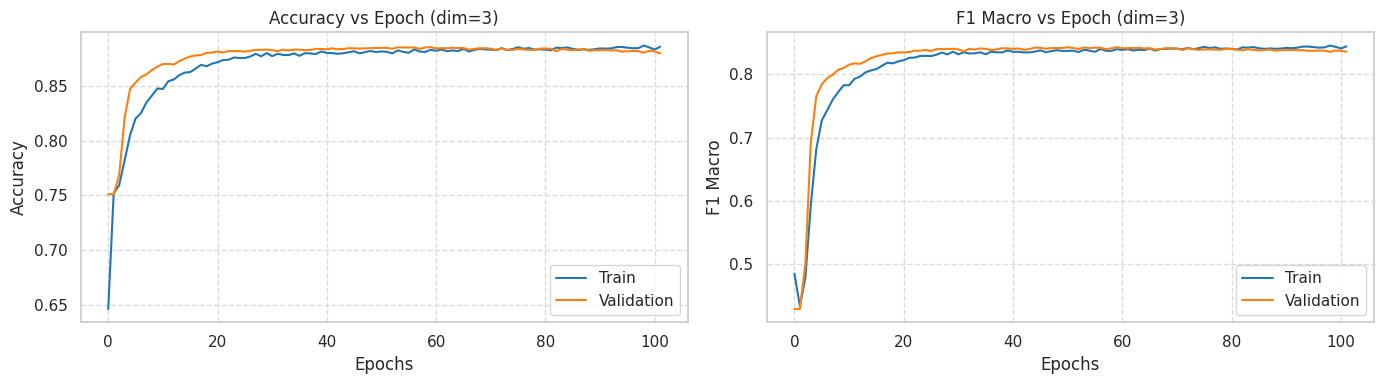


Entrenando modelo con Embedding Dim: 6
Early stopping disparado en la época 141.
Resultado final para dim=6 -> Accuracy Val: 0.8846 | F1 Macro Val: 0.8421 | Val Loss: 0.2679


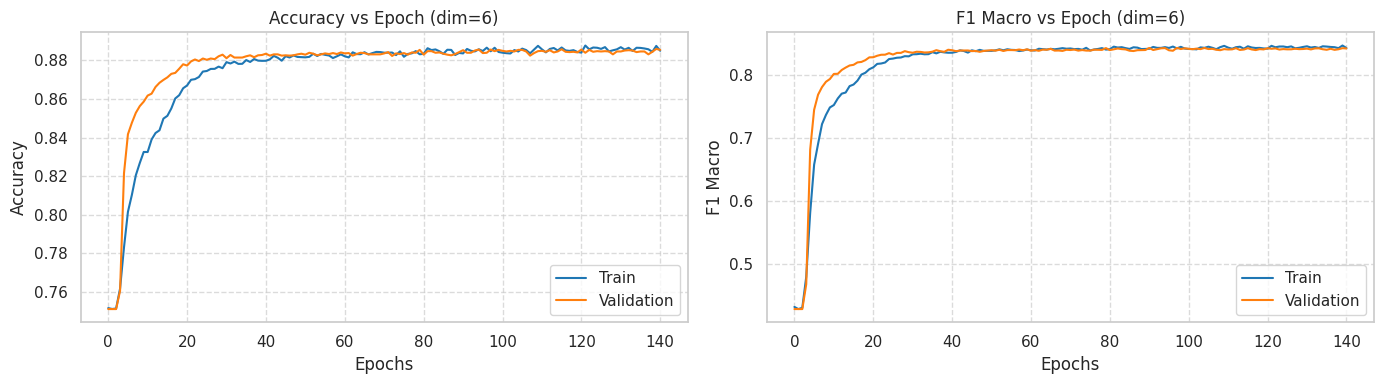



*******************************************************
=== RESUMEN COMPARATIVO DE DIMENSIONES ===
*******************************************************
Dimensión de Embedding:  3 | Accuracy Val: 0.8831 | F1 Macro Val: 0.8387 | Val Loss: 0.2710
Dimensión de Embedding:  6 | Accuracy Val: 0.8846 | F1 Macro Val: 0.8421 | Val Loss: 0.2679


In [ ]:
# --- RESTAURACIÓN DE SETUP (Celda eliminada anteriormente) ---
workclass_train_raw = train['workclass'].astype(str)
workclass_test_raw = test['workclass'].astype(str)

unique_workclasses = workclass_train_raw.unique()
workclass_to_idx = {wc: idx for idx, wc in enumerate(unique_workclasses)}

workclass_train_idx = workclass_train_raw.map(workclass_to_idx).fillna(0).astype(int).values
workclass_test_idx = workclass_test_raw.map(workclass_to_idx).fillna(0).astype(int).values

# Eliminamos las variables relacionadas con WORKCLASS, ya que utilizaremos embeddings para esta variable
cols_to_drop = [col for col in X_train.columns if 'OHE_WORKCLASS' in col]
X_train_num = X_train.drop(columns=cols_to_drop)
X_test_num = X_test.drop(columns=cols_to_drop)

X_train_num_tensor = torch.tensor(X_train_num.values, dtype=torch.float32)
workclass_train_tensor = torch.tensor(workclass_train_idx, dtype=torch.long)

X_num_tr, X_num_val, wc_tr, wc_val, y_tr, y_val = train_test_split(
    X_train_num_tensor, workclass_train_tensor, y_train_tensor,
    test_size=0.2, random_state=42, stratify=y_train_tensor
)

batch_size = 64
train_dataset_emb = TensorDataset(X_num_tr, wc_tr, y_tr)
train_loader_emb = DataLoader(train_dataset_emb, batch_size=batch_size, shuffle=True)

val_dataset_emb = TensorDataset(X_num_val, wc_val, y_val)
val_loader_emb = DataLoader(val_dataset_emb, batch_size=batch_size, shuffle=False)

class NNWithWorkclassEmbedding(nn.Module):
    def __init__(self, num_features_dim, num_workclasses, embed_dim, hidden_layers=[4, 4], dropout_rate=0.3):
        super(NNWithWorkclassEmbedding, self).__init__()
        self.workclass_embed = nn.Embedding(num_embeddings=num_workclasses, embedding_dim=embed_dim)
        input_dim = num_features_dim + embed_dim

        layers = []
        current_dim = input_dim
        for hidden_dim in hidden_layers:
            layers.append(nn.Linear(current_dim, hidden_dim))
            layers.append(nn.ReLU())
            if dropout_rate > 0:
                layers.append(nn.Dropout(dropout_rate))
            current_dim = hidden_dim

        layers.append(nn.Linear(current_dim, 1))
        self.mlp = nn.Sequential(*layers)

    def forward(self, x_num, x_cat):
        emb_out = self.workclass_embed(x_cat)
        combined = torch.cat([x_num, emb_out], dim=1)
        return self.mlp(combined)

num_categories = len(unique_workclasses)
num_numeric_features = X_train_num.shape[1]
# -------------------------------------------------------------

# Regla empírica base
base_dim = max(1, num_categories // 2)

# Definimos dimensiones a probar (base empírica y el doble para no demorar)
dims_propuestas = [base_dim, base_dim * 2]

# Filtramos duplicados y ordenamos (por si coinciden algunos valores)
embedding_dims_to_try = sorted(list(set(dims_propuestas)))
resultados_experimentos = []

print(f"Cardinalidad de Workclass: {num_categories}")
print(f"Dimensiones a probar: {embedding_dims_to_try}")
print("Iniciando barrido de dimensiones de Embedding con arquitectura [16, 16]...")

for dim in embedding_dims_to_try:
    print(f"\n{'='*50}")
    print(f"Entrenando modelo con Embedding Dim: {dim}")
    print(f"{'='*50}")

    # Instanciar un modelo nuevo para esta dimensión con [16, 16]
    modelo_prueba = NNWithWorkclassEmbedding(
        num_features_dim=num_numeric_features,
        num_workclasses=num_categories,
        embed_dim=dim,
        hidden_layers=[16, 16],
        dropout_rate=0.3
    )

    criterion_prueba = nn.BCEWithLogitsLoss()
    optimizer_prueba = optim.Adam(modelo_prueba.parameters(), lr=0.0001)

    # Configuraciones de Early Stopping
    epochs_prueba = 500  # Máximo de épocas
    patience_prueba = 10
    best_val_loss_prueba = float('inf')
    epochs_no_improve_prueba = 0
    best_f1_val = 0.0
    best_acc_val = 0.0

    # Listas para guardar el historial
    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []
    train_f1_macros, val_f1_macros = [], []

    # Bucle de entrenamiento simplificado
    for epoch in range(epochs_prueba):
        # TRAIN
        modelo_prueba.train()
        batch_losses_train = []
        all_preds_train = []
        all_labels_train = []

        for X_num_batch, X_cat_batch, y_batch in train_loader_emb:
            optimizer_prueba.zero_grad()
            outputs = modelo_prueba(X_num_batch, X_cat_batch)
            loss = criterion_prueba(outputs, y_batch)
            loss.backward()
            optimizer_prueba.step()

            batch_losses_train.append(loss.item())
            preds = (torch.sigmoid(outputs) >= 0.5).float()
            all_preds_train.extend(preds.cpu().numpy())
            all_labels_train.extend(y_batch.cpu().numpy())

        train_losses.append(np.mean(batch_losses_train))
        train_accuracies.append(accuracy_score(all_labels_train, all_preds_train))
        train_f1_macros.append(f1_score(all_labels_train, all_preds_train, average='macro'))

        # VALIDATION
        modelo_prueba.eval()
        batch_losses_val = []
        all_preds_val = []
        all_labels_val = []

        with torch.no_grad():
            for X_num_batch, X_cat_batch, y_batch in val_loader_emb:
                outputs = modelo_prueba(X_num_batch, X_cat_batch)
                loss = criterion_prueba(outputs, y_batch)
                batch_losses_val.append(loss.item())

                preds = (torch.sigmoid(outputs) >= 0.5).float()
                all_preds_val.extend(preds.cpu().numpy())
                all_labels_val.extend(y_batch.cpu().numpy())

        current_val_loss = np.mean(batch_losses_val)
        current_val_acc = accuracy_score(all_labels_val, all_preds_val)
        current_val_f1 = f1_score(all_labels_val, all_preds_val, average='macro')

        val_losses.append(current_val_loss)
        val_accuracies.append(current_val_acc)
        val_f1_macros.append(current_val_f1)

        # EARLY STOPPING CHECK
        if current_val_loss < best_val_loss_prueba:
            best_val_loss_prueba = current_val_loss
            best_f1_val = current_val_f1
            best_acc_val = current_val_acc
            epochs_no_improve_prueba = 0
        else:
            epochs_no_improve_prueba += 1

        if epochs_no_improve_prueba >= patience_prueba:
            print(f"Early stopping disparado en la época {epoch+1}.")
            break

    print(f"Resultado final para dim={dim} -> Accuracy Val: {best_acc_val:.4f} | F1 Macro Val: {best_f1_val:.4f} | Val Loss: {best_val_loss_prueba:.4f}")
    resultados_experimentos.append((dim, best_acc_val, best_f1_val, best_val_loss_prueba))

    # PLOTS PARA LA DIMENSIÓN ACTUAL
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].plot(train_accuracies, label='Train', color='#1f77b4')
    axes[0].plot(val_accuracies, label='Validation', color='#ff7f0e')
    axes[0].set_title(f'Accuracy vs Epoch (dim={dim})')
    axes[0].set_xlabel('Epochs')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True, linestyle='--', alpha=0.7)

    axes[1].plot(train_f1_macros, label='Train', color='#1f77b4')
    axes[1].plot(val_f1_macros, label='Validation', color='#ff7f0e')
    axes[1].set_title(f'F1 Macro vs Epoch (dim={dim})')
    axes[1].set_xlabel('Epochs')
    axes[1].set_ylabel('F1 Macro')
    axes[1].legend()
    axes[1].grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

# --- RESUMEN FINAL ---
print("\n\n" + "*"*55)
print("=== RESUMEN COMPARATIVO DE DIMENSIONES ===")
print("*"*55)
for dim, acc, f1, loss in resultados_experimentos:
    print(f"Dimensión de Embedding: {dim:2d} | Accuracy Val: {acc:.4f} | F1 Macro Val: {f1:.4f} | Val Loss: {loss:.4f}")

- No hay diferencia entre usar embedings o transformaciones para esta variable, ya que tiene baja cardinalidad

#### Education

Aplicando embeddings sobre la variable `education` (Cardinalidad: 16).

Cardinalidad de Education: 16
Dimensiones a probar: [8, 16]
Iniciando barrido de dimensiones de Embedding con arquitectura [16, 16]...

Entrenando modelo con Embedding Dim: 8
Early stopping disparado en la época 164.
Resultado final para dim=8 -> Accuracy Val: 0.8850 | F1 Macro Val: 0.8420 | Val Loss: 0.2686


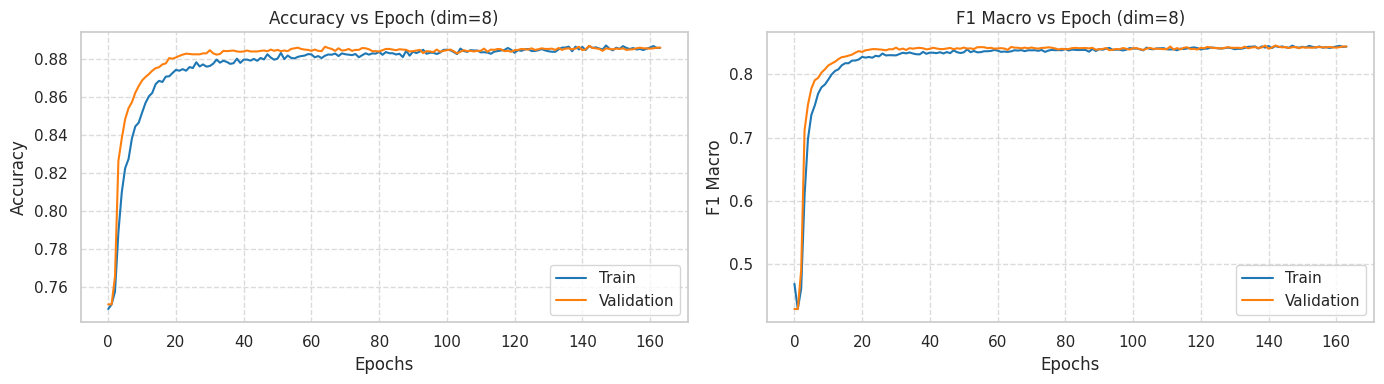


Entrenando modelo con Embedding Dim: 16
Early stopping disparado en la época 116.
Resultado final para dim=16 -> Accuracy Val: 0.8860 | F1 Macro Val: 0.8437 | Val Loss: 0.2699


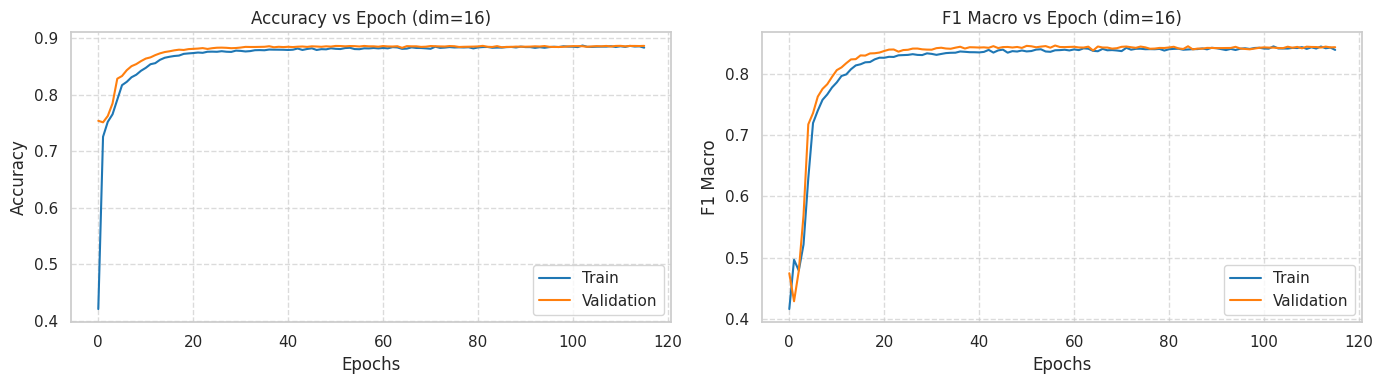



*******************************************************
=== RESUMEN COMPARATIVO DE DIMENSIONES (EDUCATION) ===
*******************************************************
Dimensión de Embedding:  8 | Accuracy Val: 0.8850 | F1 Macro Val: 0.8420 | Val Loss: 0.2686
Dimensión de Embedding: 16 | Accuracy Val: 0.8860 | F1 Macro Val: 0.8437 | Val Loss: 0.2699


In [ ]:
# --- SETUP PARA EMBEDDING DE EDUCATION ---
edu_train_raw = train['education'].astype(str)
edu_test_raw = test['education'].astype(str)

unique_edu = edu_train_raw.unique()
edu_to_idx = {edu: idx for idx, edu in enumerate(unique_edu)}

edu_train_idx = edu_train_raw.map(edu_to_idx).fillna(0).astype(int).values
edu_test_idx = edu_test_raw.map(edu_to_idx).fillna(0).astype(int).values

# Eliminamos la variable ORD_education del baseline numérico
cols_to_drop_edu = [col for col in X_train.columns if 'ORD_education' in col]
X_train_num_edu = X_train.drop(columns=cols_to_drop_edu)
X_test_num_edu = X_test.drop(columns=cols_to_drop_edu)

X_train_num_tensor_edu = torch.tensor(X_train_num_edu.values, dtype=torch.float32)
edu_train_tensor = torch.tensor(edu_train_idx, dtype=torch.long)

# Split de validación utilizando la misma semilla (42)
X_num_tr_edu, X_num_val_edu, edu_tr, edu_val, y_tr_edu, y_val_edu = train_test_split(
    X_train_num_tensor_edu, edu_train_tensor, y_train_tensor,
    test_size=0.2, random_state=42, stratify=y_train_tensor
)

batch_size = 64
train_dataset_edu = TensorDataset(X_num_tr_edu, edu_tr, y_tr_edu)
train_loader_edu = DataLoader(train_dataset_edu, batch_size=batch_size, shuffle=True)

val_dataset_edu = TensorDataset(X_num_val_edu, edu_val, y_val_edu)
val_loader_edu = DataLoader(val_dataset_edu, batch_size=batch_size, shuffle=False)

class NNWithEducationEmbedding(nn.Module):
    def __init__(self, num_features_dim, num_categories, embed_dim, hidden_layers=[16, 16], dropout_rate=0.3):
        super(NNWithEducationEmbedding, self).__init__()
        self.embed = nn.Embedding(num_embeddings=num_categories, embedding_dim=embed_dim)
        input_dim = num_features_dim + embed_dim

        layers = []
        current_dim = input_dim
        for hidden_dim in hidden_layers:
            layers.append(nn.Linear(current_dim, hidden_dim))
            layers.append(nn.ReLU())
            if dropout_rate > 0:
                layers.append(nn.Dropout(dropout_rate))
            current_dim = hidden_dim

        layers.append(nn.Linear(current_dim, 1))
        self.mlp = nn.Sequential(*layers)

    def forward(self, x_num, x_cat):
        emb_out = self.embed(x_cat)
        combined = torch.cat([x_num, emb_out], dim=1)
        return self.mlp(combined)

num_cat_edu = len(unique_edu)
num_num_features_edu = X_train_num_edu.shape[1]
# -------------------------------------------------------------

# Regla empírica base para la dimensión de embedding
base_dim_edu = max(1, num_cat_edu // 2)

# Definimos dimensiones a probar (base empírica y el doble)
dims_propuestas_edu = [base_dim_edu, base_dim_edu * 2]
embedding_dims_to_try_edu = sorted(list(set(dims_propuestas_edu)))
resultados_experimentos_edu = []

print(f"Cardinalidad de Education: {num_cat_edu}")
print(f"Dimensiones a probar: {embedding_dims_to_try_edu}")
print("Iniciando barrido de dimensiones de Embedding con arquitectura [16, 16]...")

for dim in embedding_dims_to_try_edu:
    print(f"\n{'='*50}")
    print(f"Entrenando modelo con Embedding Dim: {dim}")
    print(f"{'='*50}")

    modelo_prueba = NNWithEducationEmbedding(
        num_features_dim=num_num_features_edu,
        num_categories=num_cat_edu,
        embed_dim=dim,
        hidden_layers=[16, 16],
        dropout_rate=0.3
    )

    criterion_prueba = nn.BCEWithLogitsLoss()
    optimizer_prueba = optim.Adam(modelo_prueba.parameters(), lr=0.0001)

    epochs_prueba = 500
    patience_prueba = 10
    best_val_loss_prueba = float('inf')
    epochs_no_improve_prueba = 0
    best_f1_val = 0.0
    best_acc_val = 0.0

    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []
    train_f1_macros, val_f1_macros = [], []

    for epoch in range(epochs_prueba):
        # TRAIN
        modelo_prueba.train()
        batch_losses_train = []
        all_preds_train = []
        all_labels_train = []

        for X_num_batch, X_cat_batch, y_batch in train_loader_edu:
            optimizer_prueba.zero_grad()
            outputs = modelo_prueba(X_num_batch, X_cat_batch)
            loss = criterion_prueba(outputs, y_batch)
            loss.backward()
            optimizer_prueba.step()

            batch_losses_train.append(loss.item())
            preds = (torch.sigmoid(outputs) >= 0.5).float()
            all_preds_train.extend(preds.cpu().numpy())
            all_labels_train.extend(y_batch.cpu().numpy())

        train_losses.append(np.mean(batch_losses_train))
        train_accuracies.append(accuracy_score(all_labels_train, all_preds_train))
        train_f1_macros.append(f1_score(all_labels_train, all_preds_train, average='macro'))

        # VALIDATION
        modelo_prueba.eval()
        batch_losses_val = []
        all_preds_val = []
        all_labels_val = []

        with torch.no_grad():
            for X_num_batch, X_cat_batch, y_batch in val_loader_edu:
                outputs = modelo_prueba(X_num_batch, X_cat_batch)
                loss = criterion_prueba(outputs, y_batch)
                batch_losses_val.append(loss.item())

                preds = (torch.sigmoid(outputs) >= 0.5).float()
                all_preds_val.extend(preds.cpu().numpy())
                all_labels_val.extend(y_batch.cpu().numpy())

        current_val_loss = np.mean(batch_losses_val)
        current_val_acc = accuracy_score(all_labels_val, all_preds_val)
        current_val_f1 = f1_score(all_labels_val, all_preds_val, average='macro')

        val_losses.append(current_val_loss)
        val_accuracies.append(current_val_acc)
        val_f1_macros.append(current_val_f1)

        # EARLY STOPPING CHECK
        if current_val_loss < best_val_loss_prueba:
            best_val_loss_prueba = current_val_loss
            best_f1_val = current_val_f1
            best_acc_val = current_val_acc
            epochs_no_improve_prueba = 0
        else:
            epochs_no_improve_prueba += 1

        if epochs_no_improve_prueba >= patience_prueba:
            print(f"Early stopping disparado en la época {epoch+1}.")
            break

    print(f"Resultado final para dim={dim} -> Accuracy Val: {best_acc_val:.4f} | F1 Macro Val: {best_f1_val:.4f} | Val Loss: {best_val_loss_prueba:.4f}")
    resultados_experimentos_edu.append((dim, best_acc_val, best_f1_val, best_val_loss_prueba))

    # PLOTS
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].plot(train_accuracies, label='Train', color='#1f77b4')
    axes[0].plot(val_accuracies, label='Validation', color='#ff7f0e')
    axes[0].set_title(f'Accuracy vs Epoch (dim={dim})')
    axes[0].set_xlabel('Epochs')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True, linestyle='--', alpha=0.7)

    axes[1].plot(train_f1_macros, label='Train', color='#1f77b4')
    axes[1].plot(val_f1_macros, label='Validation', color='#ff7f0e')
    axes[1].set_title(f'F1 Macro vs Epoch (dim={dim})')
    axes[1].set_xlabel('Epochs')
    axes[1].set_ylabel('F1 Macro')
    axes[1].legend()
    axes[1].grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

# --- RESUMEN FINAL EDUCATION ---
print("\n\n" + "*"*55)
print("=== RESUMEN COMPARATIVO DE DIMENSIONES (EDUCATION) ===")
print("*"*55)
for dim, acc, f1, loss in resultados_experimentos_edu:
    print(f"Dimensión de Embedding: {dim:2d} | Accuracy Val: {acc:.4f} | F1 Macro Val: {f1:.4f} | Val Loss: {loss:.4f}")

- Tampoco hay mucha diferencia si utilizamos embeddings para esta variable
- Se ve que la transformacion ordinal funciona bien para esta variable

#### Marital-status

Aplicando embeddings sobre la variable `marital-status` (Cardinalidad: 7).

Cardinalidad de Marital-status: 7
Dimensiones a probar: [3, 6]
Iniciando barrido de dimensiones de Embedding con arquitectura [16, 16]...

Entrenando modelo con Embedding Dim: 3
Early stopping disparado en la época 99.
Resultado final para dim=3 -> Accuracy Val: 0.8823 | F1 Macro Val: 0.8386 | Val Loss: 0.2707


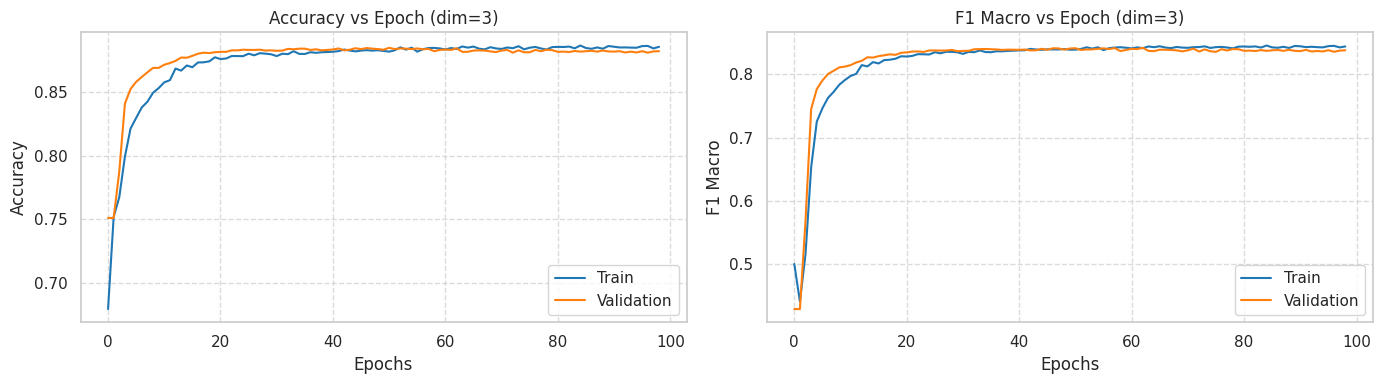


Entrenando modelo con Embedding Dim: 6
Early stopping disparado en la época 129.
Resultado final para dim=6 -> Accuracy Val: 0.8833 | F1 Macro Val: 0.8403 | Val Loss: 0.2691


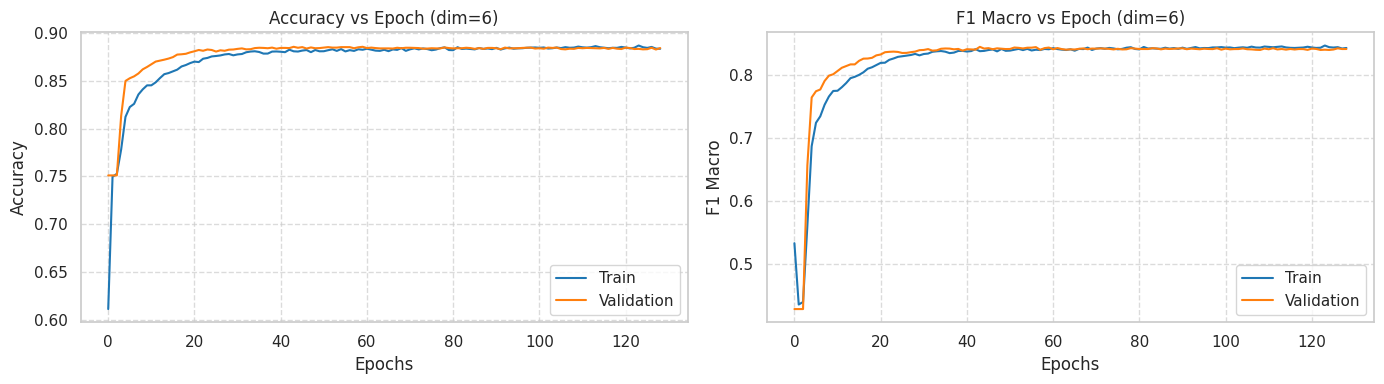



*******************************************************
=== RESUMEN COMPARATIVO DE DIMENSIONES (MARITAL STATUS) ===
*******************************************************
Dimensión de Embedding:  3 | Accuracy Val: 0.8823 | F1 Macro Val: 0.8386 | Val Loss: 0.2707
Dimensión de Embedding:  6 | Accuracy Val: 0.8833 | F1 Macro Val: 0.8403 | Val Loss: 0.2691


In [ ]:
# --- SETUP PARA EMBEDDING DE MARITAL-STATUS ---
marital_train_raw = train['marital-status'].astype(str)
marital_test_raw = test['marital-status'].astype(str)

unique_marital = marital_train_raw.unique()
marital_to_idx = {ms: idx for idx, ms in enumerate(unique_marital)}

marital_train_idx = marital_train_raw.map(marital_to_idx).fillna(0).astype(int).values
marital_test_idx = marital_test_raw.map(marital_to_idx).fillna(0).astype(int).values

# Eliminamos las variables OHE relacionadas con marital-status del baseline numérico
cols_to_drop_marital = [col for col in X_train.columns if 'OHE_MARITAL_STATUS' in col]
X_train_num_marital = X_train.drop(columns=cols_to_drop_marital)
X_test_num_marital = X_test.drop(columns=cols_to_drop_marital)

X_train_num_tensor_marital = torch.tensor(X_train_num_marital.values, dtype=torch.float32)
marital_train_tensor = torch.tensor(marital_train_idx, dtype=torch.long)

# Split de validación utilizando la misma semilla (42)
X_num_tr_mar, X_num_val_mar, mar_tr, mar_val, y_tr_mar, y_val_mar = train_test_split(
    X_train_num_tensor_marital, marital_train_tensor, y_train_tensor,
    test_size=0.2, random_state=42, stratify=y_train_tensor
)

batch_size = 64
train_dataset_mar = TensorDataset(X_num_tr_mar, mar_tr, y_tr_mar)
train_loader_mar = DataLoader(train_dataset_mar, batch_size=batch_size, shuffle=True)

val_dataset_mar = TensorDataset(X_num_val_mar, mar_val, y_val_mar)
val_loader_mar = DataLoader(val_dataset_mar, batch_size=batch_size, shuffle=False)

class NNWithMaritalStatusEmbedding(nn.Module):
    def __init__(self, num_features_dim, num_categories, embed_dim, hidden_layers=[16, 16], dropout_rate=0.3):
        super(NNWithMaritalStatusEmbedding, self).__init__()
        self.embed = nn.Embedding(num_embeddings=num_categories, embedding_dim=embed_dim)
        input_dim = num_features_dim + embed_dim

        layers = []
        current_dim = input_dim
        for hidden_dim in hidden_layers:
            layers.append(nn.Linear(current_dim, hidden_dim))
            layers.append(nn.ReLU())
            if dropout_rate > 0:
                layers.append(nn.Dropout(dropout_rate))
            current_dim = hidden_dim

        layers.append(nn.Linear(current_dim, 1))
        self.mlp = nn.Sequential(*layers)

    def forward(self, x_num, x_cat):
        emb_out = self.embed(x_cat)
        combined = torch.cat([x_num, emb_out], dim=1)
        return self.mlp(combined)

num_cat_mar = len(unique_marital)
num_num_features_mar = X_train_num_marital.shape[1]
# -------------------------------------------------------------

# Regla empírica base para la dimensión de embedding
base_dim_mar = max(1, num_cat_mar // 2)

# Definimos dimensiones a probar (base empírica y el doble)
dims_propuestas_mar = [base_dim_mar, base_dim_mar * 2]
embedding_dims_to_try_mar = sorted(list(set(dims_propuestas_mar)))
resultados_experimentos_mar = []

print(f"Cardinalidad de Marital-status: {num_cat_mar}")
print(f"Dimensiones a probar: {embedding_dims_to_try_mar}")
print("Iniciando barrido de dimensiones de Embedding con arquitectura [16, 16]...")

for dim in embedding_dims_to_try_mar:
    print(f"\n{'='*50}")
    print(f"Entrenando modelo con Embedding Dim: {dim}")
    print(f"{'='*50}")

    modelo_prueba = NNWithMaritalStatusEmbedding(
        num_features_dim=num_num_features_mar,
        num_categories=num_cat_mar,
        embed_dim=dim,
        hidden_layers=[16, 16],
        dropout_rate=0.3
    )

    criterion_prueba = nn.BCEWithLogitsLoss()
    optimizer_prueba = optim.Adam(modelo_prueba.parameters(), lr=0.0001)

    epochs_prueba = 500
    patience_prueba = 10
    best_val_loss_prueba = float('inf')
    epochs_no_improve_prueba = 0
    best_f1_val = 0.0
    best_acc_val = 0.0

    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []
    train_f1_macros, val_f1_macros = [], []

    for epoch in range(epochs_prueba):
        # TRAIN
        modelo_prueba.train()
        batch_losses_train = []
        all_preds_train = []
        all_labels_train = []

        for X_num_batch, X_cat_batch, y_batch in train_loader_mar:
            optimizer_prueba.zero_grad()
            outputs = modelo_prueba(X_num_batch, X_cat_batch)
            loss = criterion_prueba(outputs, y_batch)
            loss.backward()
            optimizer_prueba.step()

            batch_losses_train.append(loss.item())
            preds = (torch.sigmoid(outputs) >= 0.5).float()
            all_preds_train.extend(preds.cpu().numpy())
            all_labels_train.extend(y_batch.cpu().numpy())

        train_losses.append(np.mean(batch_losses_train))
        train_accuracies.append(accuracy_score(all_labels_train, all_preds_train))
        train_f1_macros.append(f1_score(all_labels_train, all_preds_train, average='macro'))

        # VALIDATION
        modelo_prueba.eval()
        batch_losses_val = []
        all_preds_val = []
        all_labels_val = []

        with torch.no_grad():
            for X_num_batch, X_cat_batch, y_batch in val_loader_mar:
                outputs = modelo_prueba(X_num_batch, X_cat_batch)
                loss = criterion_prueba(outputs, y_batch)
                batch_losses_val.append(loss.item())

                preds = (torch.sigmoid(outputs) >= 0.5).float()
                all_preds_val.extend(preds.cpu().numpy())
                all_labels_val.extend(y_batch.cpu().numpy())

        current_val_loss = np.mean(batch_losses_val)
        current_val_acc = accuracy_score(all_labels_val, all_preds_val)
        current_val_f1 = f1_score(all_labels_val, all_preds_val, average='macro')

        val_losses.append(current_val_loss)
        val_accuracies.append(current_val_acc)
        val_f1_macros.append(current_val_f1)

        # EARLY STOPPING CHECK
        if current_val_loss < best_val_loss_prueba:
            best_val_loss_prueba = current_val_loss
            best_f1_val = current_val_f1
            best_acc_val = current_val_acc
            epochs_no_improve_prueba = 0
        else:
            epochs_no_improve_prueba += 1

        if epochs_no_improve_prueba >= patience_prueba:
            print(f"Early stopping disparado en la época {epoch+1}.")
            break

    print(f"Resultado final para dim={dim} -> Accuracy Val: {best_acc_val:.4f} | F1 Macro Val: {best_f1_val:.4f} | Val Loss: {best_val_loss_prueba:.4f}")
    resultados_experimentos_mar.append((dim, best_acc_val, best_f1_val, best_val_loss_prueba))

    # PLOTS
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].plot(train_accuracies, label='Train', color='#1f77b4')
    axes[0].plot(val_accuracies, label='Validation', color='#ff7f0e')
    axes[0].set_title(f'Accuracy vs Epoch (dim={dim})')
    axes[0].set_xlabel('Epochs')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True, linestyle='--', alpha=0.7)

    axes[1].plot(train_f1_macros, label='Train', color='#1f77b4')
    axes[1].plot(val_f1_macros, label='Validation', color='#ff7f0e')
    axes[1].set_title(f'F1 Macro vs Epoch (dim={dim})')
    axes[1].set_xlabel('Epochs')
    axes[1].set_ylabel('F1 Macro')
    axes[1].legend()
    axes[1].grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

# --- RESUMEN FINAL MARITAL STATUS ---
print("\n\n" + "*"*55)
print("=== RESUMEN COMPARATIVO DE DIMENSIONES (MARITAL STATUS) ===")
print("*"*55)
for dim, acc, f1, loss in resultados_experimentos_mar:
    print(f"Dimensión de Embedding: {dim:2d} | Accuracy Val: {acc:.4f} | F1 Macro Val: {f1:.4f} | Val Loss: {loss:.4f}")

- Tampoco hay mejora aca, otra variable con cardinalidada baja (7)

#### Occupation

Aplicando embeddings sobre la variable `occupation` (Cardinalidad: 14).

Cardinalidad de Occupation: 14
Dimensiones a probar: [7, 14]
Iniciando barrido de dimensiones de Embedding con arquitectura [16, 16]...

Entrenando modelo con Embedding Dim: 7
Early stopping disparado en la época 91.
Resultado final para dim=7 -> Accuracy Val: 0.8861 | F1 Macro Val: 0.8439 | Val Loss: 0.2673


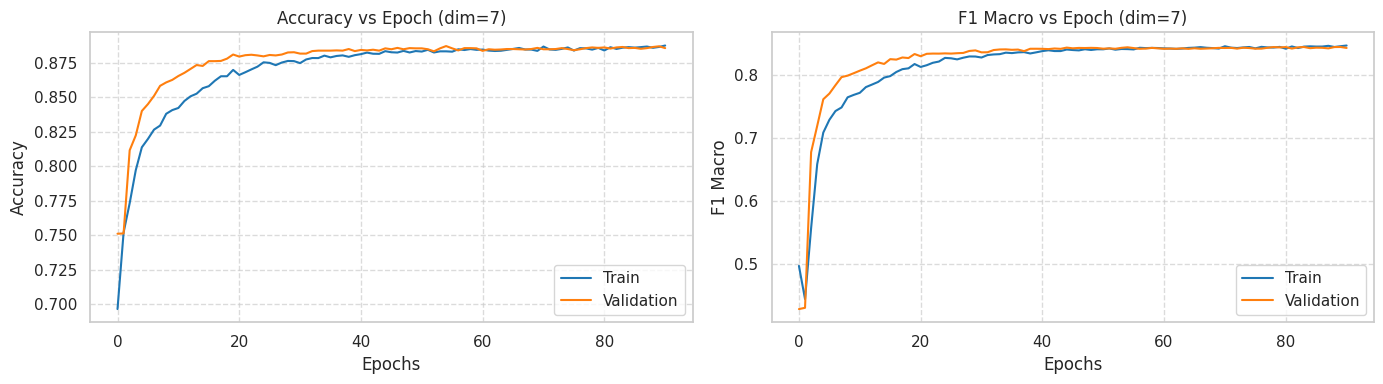


Entrenando modelo con Embedding Dim: 14
Early stopping disparado en la época 104.
Resultado final para dim=14 -> Accuracy Val: 0.8851 | F1 Macro Val: 0.8418 | Val Loss: 0.2671


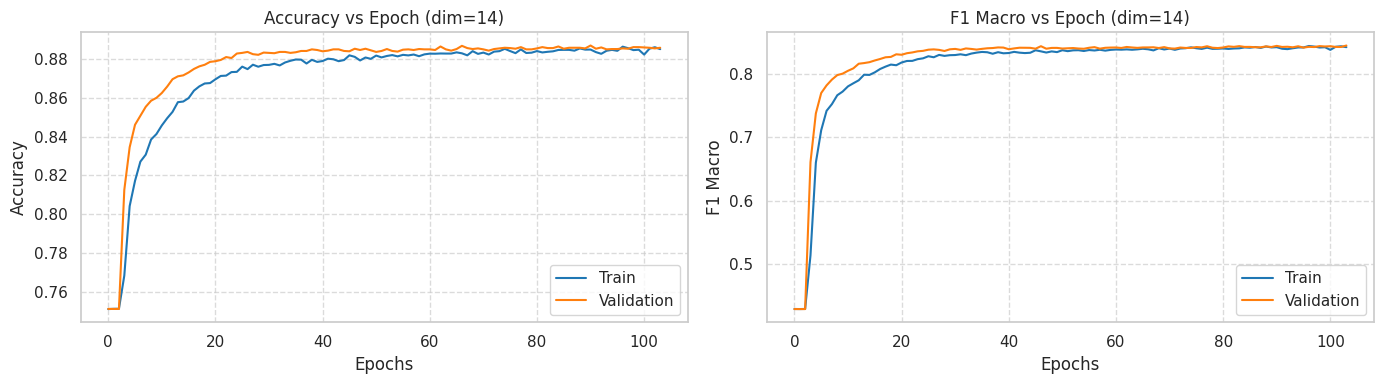



*******************************************************
=== RESUMEN COMPARATIVO DE DIMENSIONES (OCCUPATION) ===
*******************************************************
Dimensión de Embedding:  7 | Accuracy Val: 0.8861 | F1 Macro Val: 0.8439 | Val Loss: 0.2673
Dimensión de Embedding: 14 | Accuracy Val: 0.8851 | F1 Macro Val: 0.8418 | Val Loss: 0.2671


In [ ]:
# --- SETUP PARA EMBEDDING DE OCCUPATION ---
occ_train_raw = train['occupation'].astype(str)
occ_test_raw = test['occupation'].astype(str)

unique_occ = occ_train_raw.unique()
occ_to_idx = {occ: idx for idx, occ in enumerate(unique_occ)}

occ_train_idx = occ_train_raw.map(occ_to_idx).fillna(0).astype(int).values
occ_test_idx = occ_test_raw.map(occ_to_idx).fillna(0).astype(int).values

# Eliminamos las DOS variables relacionadas con occupation del baseline numérico
cols_to_drop_occ = ['FRQ_Occupation', 'TAR_Occupation']
# Nos aseguramos de que existan antes de intentar hacer drop
cols_to_drop_occ = [col for col in cols_to_drop_occ if col in X_train.columns]

X_train_num_occ = X_train.drop(columns=cols_to_drop_occ)
X_test_num_occ = X_test.drop(columns=cols_to_drop_occ)

X_train_num_tensor_occ = torch.tensor(X_train_num_occ.values, dtype=torch.float32)
occ_train_tensor = torch.tensor(occ_train_idx, dtype=torch.long)

# Split de validación utilizando la misma semilla (42)
X_num_tr_occ, X_num_val_occ, occ_tr, occ_val, y_tr_occ, y_val_occ = train_test_split(
    X_train_num_tensor_occ, occ_train_tensor, y_train_tensor,
    test_size=0.2, random_state=42, stratify=y_train_tensor
)

batch_size = 64
train_dataset_occ = TensorDataset(X_num_tr_occ, occ_tr, y_tr_occ)
train_loader_occ = DataLoader(train_dataset_occ, batch_size=batch_size, shuffle=True)

val_dataset_occ = TensorDataset(X_num_val_occ, occ_val, y_val_occ)
val_loader_occ = DataLoader(val_dataset_occ, batch_size=batch_size, shuffle=False)

class NNWithOccupationEmbedding(nn.Module):
    def __init__(self, num_features_dim, num_categories, embed_dim, hidden_layers=[16, 16], dropout_rate=0.3):
        super(NNWithOccupationEmbedding, self).__init__()
        self.embed = nn.Embedding(num_embeddings=num_categories, embedding_dim=embed_dim)
        input_dim = num_features_dim + embed_dim

        layers = []
        current_dim = input_dim
        for hidden_dim in hidden_layers:
            layers.append(nn.Linear(current_dim, hidden_dim))
            layers.append(nn.ReLU())
            if dropout_rate > 0:
                layers.append(nn.Dropout(dropout_rate))
            current_dim = hidden_dim

        layers.append(nn.Linear(current_dim, 1))
        self.mlp = nn.Sequential(*layers)

    def forward(self, x_num, x_cat):
        emb_out = self.embed(x_cat)
        combined = torch.cat([x_num, emb_out], dim=1)
        return self.mlp(combined)

num_cat_occ = len(unique_occ)
num_num_features_occ = X_train_num_occ.shape[1]
# -------------------------------------------------------------

# Regla empírica base para la dimensión de embedding
base_dim_occ = max(1, num_cat_occ // 2)

# Definimos dimensiones a probar (base empírica y el doble)
dims_propuestas_occ = [base_dim_occ, base_dim_occ * 2]
embedding_dims_to_try_occ = sorted(list(set(dims_propuestas_occ)))
resultados_experimentos_occ = []

print(f"Cardinalidad de Occupation: {num_cat_occ}")
print(f"Dimensiones a probar: {embedding_dims_to_try_occ}")
print("Iniciando barrido de dimensiones de Embedding con arquitectura [16, 16]...")

for dim in embedding_dims_to_try_occ:
    print(f"\n{'='*50}")
    print(f"Entrenando modelo con Embedding Dim: {dim}")
    print(f"{'='*50}")

    modelo_prueba = NNWithOccupationEmbedding(
        num_features_dim=num_num_features_occ,
        num_categories=num_cat_occ,
        embed_dim=dim,
        hidden_layers=[16, 16],
        dropout_rate=0.3
    )

    criterion_prueba = nn.BCEWithLogitsLoss()
    optimizer_prueba = optim.Adam(modelo_prueba.parameters(), lr=0.0001)

    epochs_prueba = 500
    patience_prueba = 10
    best_val_loss_prueba = float('inf')
    epochs_no_improve_prueba = 0
    best_f1_val = 0.0
    best_acc_val = 0.0

    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []
    train_f1_macros, val_f1_macros = [], []

    for epoch in range(epochs_prueba):
        # TRAIN
        modelo_prueba.train()
        batch_losses_train = []
        all_preds_train = []
        all_labels_train = []

        for X_num_batch, X_cat_batch, y_batch in train_loader_occ:
            optimizer_prueba.zero_grad()
            outputs = modelo_prueba(X_num_batch, X_cat_batch)
            loss = criterion_prueba(outputs, y_batch)
            loss.backward()
            optimizer_prueba.step()

            batch_losses_train.append(loss.item())
            preds = (torch.sigmoid(outputs) >= 0.5).float()
            all_preds_train.extend(preds.cpu().numpy())
            all_labels_train.extend(y_batch.cpu().numpy())

        train_losses.append(np.mean(batch_losses_train))
        train_accuracies.append(accuracy_score(all_labels_train, all_preds_train))
        train_f1_macros.append(f1_score(all_labels_train, all_preds_train, average='macro'))

        # VALIDATION
        modelo_prueba.eval()
        batch_losses_val = []
        all_preds_val = []
        all_labels_val = []

        with torch.no_grad():
            for X_num_batch, X_cat_batch, y_batch in val_loader_occ:
                outputs = modelo_prueba(X_num_batch, X_cat_batch)
                loss = criterion_prueba(outputs, y_batch)
                batch_losses_val.append(loss.item())

                preds = (torch.sigmoid(outputs) >= 0.5).float()
                all_preds_val.extend(preds.cpu().numpy())
                all_labels_val.extend(y_batch.cpu().numpy())

        current_val_loss = np.mean(batch_losses_val)
        current_val_acc = accuracy_score(all_labels_val, all_preds_val)
        current_val_f1 = f1_score(all_labels_val, all_preds_val, average='macro')

        val_losses.append(current_val_loss)
        val_accuracies.append(current_val_acc)
        val_f1_macros.append(current_val_f1)

        # EARLY STOPPING CHECK
        if current_val_loss < best_val_loss_prueba:
            best_val_loss_prueba = current_val_loss
            best_f1_val = current_val_f1
            best_acc_val = current_val_acc
            epochs_no_improve_prueba = 0
        else:
            epochs_no_improve_prueba += 1

        if epochs_no_improve_prueba >= patience_prueba:
            print(f"Early stopping disparado en la época {epoch+1}.")
            break

    print(f"Resultado final para dim={dim} -> Accuracy Val: {best_acc_val:.4f} | F1 Macro Val: {best_f1_val:.4f} | Val Loss: {best_val_loss_prueba:.4f}")
    resultados_experimentos_occ.append((dim, best_acc_val, best_f1_val, best_val_loss_prueba))

    # PLOTS
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].plot(train_accuracies, label='Train', color='#1f77b4')
    axes[0].plot(val_accuracies, label='Validation', color='#ff7f0e')
    axes[0].set_title(f'Accuracy vs Epoch (dim={dim})')
    axes[0].set_xlabel('Epochs')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True, linestyle='--', alpha=0.7)

    axes[1].plot(train_f1_macros, label='Train', color='#1f77b4')
    axes[1].plot(val_f1_macros, label='Validation', color='#ff7f0e')
    axes[1].set_title(f'F1 Macro vs Epoch (dim={dim})')
    axes[1].set_xlabel('Epochs')
    axes[1].set_ylabel('F1 Macro')
    axes[1].legend()
    axes[1].grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

# --- RESUMEN FINAL OCCUPATION ---
print("\n\n" + "*"*55)
print("=== RESUMEN COMPARATIVO DE DIMENSIONES (OCCUPATION) ===")
print("*"*55)
for dim, acc, f1, loss in resultados_experimentos_occ:
    print(f"Dimensión de Embedding: {dim:2d} | Accuracy Val: {acc:.4f} | F1 Macro Val: {f1:.4f} | Val Loss: {loss:.4f}")

- Tampoco se observa una ganancia significativa usando esta variable

#### Relationship

Aplicando embeddings sobre la variable `relationship` (Cardinalidad: 6).

Cardinalidad de Relationship: 6
Dimensiones a probar: [3, 6]
Iniciando barrido de dimensiones de Embedding con arquitectura [16, 16]...

Entrenando modelo con Embedding Dim: 3
Early stopping disparado en la época 170.
Resultado final para dim=3 -> Accuracy Val: 0.8845 | F1 Macro Val: 0.8415 | Val Loss: 0.2687


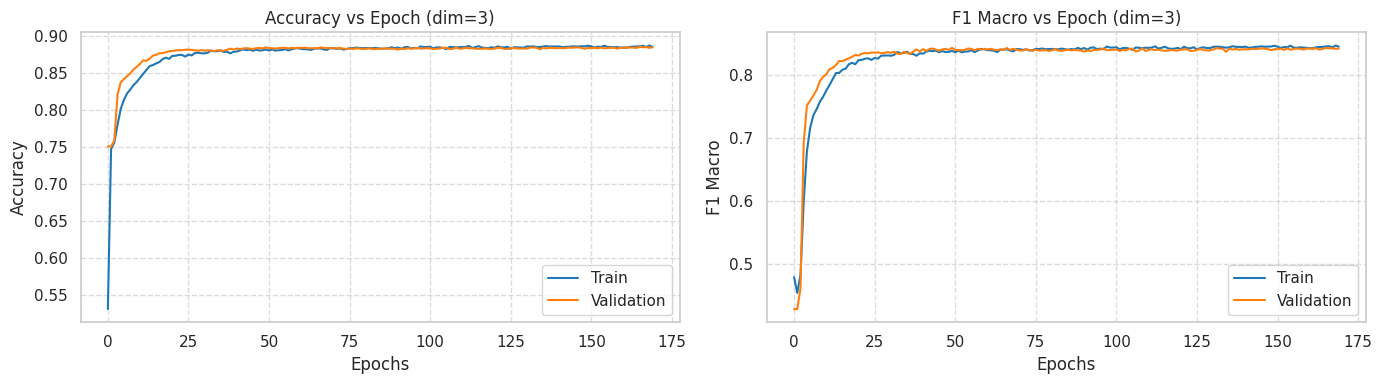


Entrenando modelo con Embedding Dim: 6
Early stopping disparado en la época 147.
Resultado final para dim=6 -> Accuracy Val: 0.8833 | F1 Macro Val: 0.8392 | Val Loss: 0.2689


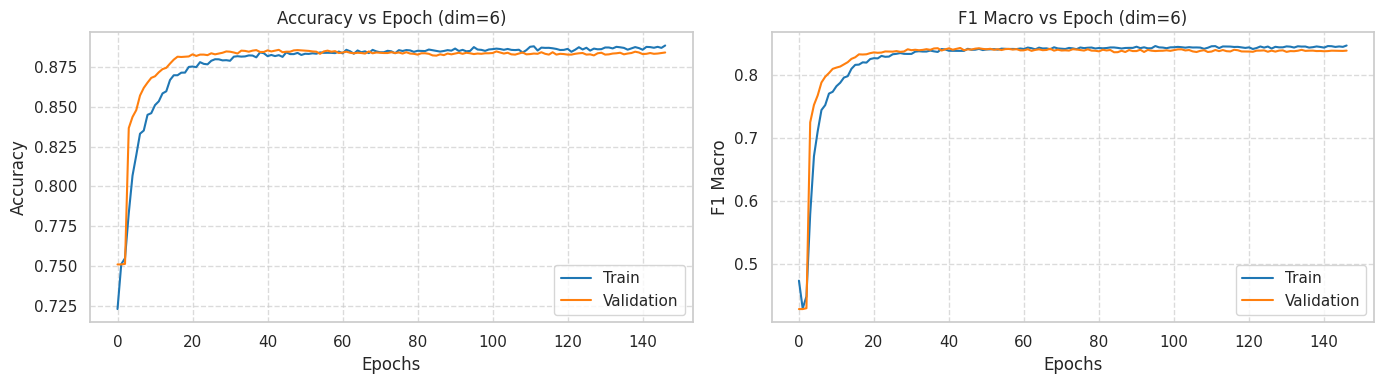



*******************************************************
=== RESUMEN COMPARATIVO DE DIMENSIONES (RELATIONSHIP) ===
*******************************************************
Dimensión de Embedding:  3 | Accuracy Val: 0.8845 | F1 Macro Val: 0.8415 | Val Loss: 0.2687
Dimensión de Embedding:  6 | Accuracy Val: 0.8833 | F1 Macro Val: 0.8392 | Val Loss: 0.2689


In [ ]:
# --- SETUP PARA EMBEDDING DE RELATIONSHIP ---
rel_train_raw = train['relationship'].astype(str)
rel_test_raw = test['relationship'].astype(str)

unique_rel = rel_train_raw.unique()
rel_to_idx = {rel: idx for idx, rel in enumerate(unique_rel)}

rel_train_idx = rel_train_raw.map(rel_to_idx).fillna(0).astype(int).values
rel_test_idx = rel_test_raw.map(rel_to_idx).fillna(0).astype(int).values

# Eliminamos las variables OHE relacionadas con relationship del baseline numérico
cols_to_drop_rel = [col for col in X_train.columns if 'OHE_RELATIONSHIP' in col]

X_train_num_rel = X_train.drop(columns=cols_to_drop_rel)
X_test_num_rel = X_test.drop(columns=cols_to_drop_rel)

X_train_num_tensor_rel = torch.tensor(X_train_num_rel.values, dtype=torch.float32)
rel_train_tensor = torch.tensor(rel_train_idx, dtype=torch.long)

# Split de validación utilizando la misma semilla (42)
X_num_tr_rel, X_num_val_rel, rel_tr, rel_val, y_tr_rel, y_val_rel = train_test_split(
    X_train_num_tensor_rel, rel_train_tensor, y_train_tensor,
    test_size=0.2, random_state=42, stratify=y_train_tensor
)

batch_size = 64
train_dataset_rel = TensorDataset(X_num_tr_rel, rel_tr, y_tr_rel)
train_loader_rel = DataLoader(train_dataset_rel, batch_size=batch_size, shuffle=True)

val_dataset_rel = TensorDataset(X_num_val_rel, rel_val, y_val_rel)
val_loader_rel = DataLoader(val_dataset_rel, batch_size=batch_size, shuffle=False)

class NNWithRelationshipEmbedding(nn.Module):
    def __init__(self, num_features_dim, num_categories, embed_dim, hidden_layers=[16, 16], dropout_rate=0.3):
        super(NNWithRelationshipEmbedding, self).__init__()
        self.embed = nn.Embedding(num_embeddings=num_categories, embedding_dim=embed_dim)
        input_dim = num_features_dim + embed_dim

        layers = []
        current_dim = input_dim
        for hidden_dim in hidden_layers:
            layers.append(nn.Linear(current_dim, hidden_dim))
            layers.append(nn.ReLU())
            if dropout_rate > 0:
                layers.append(nn.Dropout(dropout_rate))
            current_dim = hidden_dim

        layers.append(nn.Linear(current_dim, 1))
        self.mlp = nn.Sequential(*layers)

    def forward(self, x_num, x_cat):
        emb_out = self.embed(x_cat)
        combined = torch.cat([x_num, emb_out], dim=1)
        return self.mlp(combined)

num_cat_rel = len(unique_rel)
num_num_features_rel = X_train_num_rel.shape[1]
# -------------------------------------------------------------

# Regla empírica base para la dimensión de embedding
base_dim_rel = max(1, num_cat_rel // 2)

# Definimos dimensiones a probar (base empírica y el doble)
dims_propuestas_rel = [base_dim_rel, base_dim_rel * 2]
embedding_dims_to_try_rel = sorted(list(set(dims_propuestas_rel)))
resultados_experimentos_rel = []

print(f"Cardinalidad de Relationship: {num_cat_rel}")
print(f"Dimensiones a probar: {embedding_dims_to_try_rel}")
print("Iniciando barrido de dimensiones de Embedding con arquitectura [16, 16]...")

for dim in embedding_dims_to_try_rel:
    print(f"\n{'='*50}")
    print(f"Entrenando modelo con Embedding Dim: {dim}")
    print(f"{'='*50}")

    modelo_prueba = NNWithRelationshipEmbedding(
        num_features_dim=num_num_features_rel,
        num_categories=num_cat_rel,
        embed_dim=dim,
        hidden_layers=[16, 16],
        dropout_rate=0.3
    )

    criterion_prueba = nn.BCEWithLogitsLoss()
    optimizer_prueba = optim.Adam(modelo_prueba.parameters(), lr=0.0001)

    epochs_prueba = 500
    patience_prueba = 10
    best_val_loss_prueba = float('inf')
    epochs_no_improve_prueba = 0
    best_f1_val = 0.0
    best_acc_val = 0.0

    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []
    train_f1_macros, val_f1_macros = [], []

    for epoch in range(epochs_prueba):
        # TRAIN
        modelo_prueba.train()
        batch_losses_train = []
        all_preds_train = []
        all_labels_train = []

        for X_num_batch, X_cat_batch, y_batch in train_loader_rel:
            optimizer_prueba.zero_grad()
            outputs = modelo_prueba(X_num_batch, X_cat_batch)
            loss = criterion_prueba(outputs, y_batch)
            loss.backward()
            optimizer_prueba.step()

            batch_losses_train.append(loss.item())
            preds = (torch.sigmoid(outputs) >= 0.5).float()
            all_preds_train.extend(preds.cpu().numpy())
            all_labels_train.extend(y_batch.cpu().numpy())

        train_losses.append(np.mean(batch_losses_train))
        train_accuracies.append(accuracy_score(all_labels_train, all_preds_train))
        train_f1_macros.append(f1_score(all_labels_train, all_preds_train, average='macro'))

        # VALIDATION
        modelo_prueba.eval()
        batch_losses_val = []
        all_preds_val = []
        all_labels_val = []

        with torch.no_grad():
            for X_num_batch, X_cat_batch, y_batch in val_loader_rel:
                outputs = modelo_prueba(X_num_batch, X_cat_batch)
                loss = criterion_prueba(outputs, y_batch)
                batch_losses_val.append(loss.item())

                preds = (torch.sigmoid(outputs) >= 0.5).float()
                all_preds_val.extend(preds.cpu().numpy())
                all_labels_val.extend(y_batch.cpu().numpy())

        current_val_loss = np.mean(batch_losses_val)
        current_val_acc = accuracy_score(all_labels_val, all_preds_val)
        current_val_f1 = f1_score(all_labels_val, all_preds_val, average='macro')

        val_losses.append(current_val_loss)
        val_accuracies.append(current_val_acc)
        val_f1_macros.append(current_val_f1)

        # EARLY STOPPING CHECK
        if current_val_loss < best_val_loss_prueba:
            best_val_loss_prueba = current_val_loss
            best_f1_val = current_val_f1
            best_acc_val = current_val_acc
            epochs_no_improve_prueba = 0
        else:
            epochs_no_improve_prueba += 1

        if epochs_no_improve_prueba >= patience_prueba:
            print(f"Early stopping disparado en la época {epoch+1}.")
            break

    print(f"Resultado final para dim={dim} -> Accuracy Val: {best_acc_val:.4f} | F1 Macro Val: {best_f1_val:.4f} | Val Loss: {best_val_loss_prueba:.4f}")
    resultados_experimentos_rel.append((dim, best_acc_val, best_f1_val, best_val_loss_prueba))

    # PLOTS
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].plot(train_accuracies, label='Train', color='#1f77b4')
    axes[0].plot(val_accuracies, label='Validation', color='#ff7f0e')
    axes[0].set_title(f'Accuracy vs Epoch (dim={dim})')
    axes[0].set_xlabel('Epochs')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True, linestyle='--', alpha=0.7)

    axes[1].plot(train_f1_macros, label='Train', color='#1f77b4')
    axes[1].plot(val_f1_macros, label='Validation', color='#ff7f0e')
    axes[1].set_title(f'F1 Macro vs Epoch (dim={dim})')
    axes[1].set_xlabel('Epochs')
    axes[1].set_ylabel('F1 Macro')
    axes[1].legend()
    axes[1].grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

# --- RESUMEN FINAL RELATIONSHIP ---
print("\n\n" + "*"*55)
print("=== RESUMEN COMPARATIVO DE DIMENSIONES (RELATIONSHIP) ===")
print("*"*55)
for dim, acc, f1, loss in resultados_experimentos_rel:
    print(f"Dimensión de Embedding: {dim:2d} | Accuracy Val: {acc:.4f} | F1 Macro Val: {f1:.4f} | Val Loss: {loss:.4f}")

#### Skill-profile

Aplicando embeddings sobre la variable `skill-profile` (Cardinalidad: 80).

Cardinalidad de Skill-profile: 80
Dimensiones a probar: [40, 80]
Iniciando barrido de dimensiones de Embedding con arquitectura [16, 16]...

Entrenando modelo con Embedding Dim: 40
Early stopping disparado en la época 80.
Resultado final para dim=40 -> Accuracy Val: 0.8851 | F1 Macro Val: 0.8423 | Val Loss: 0.2720


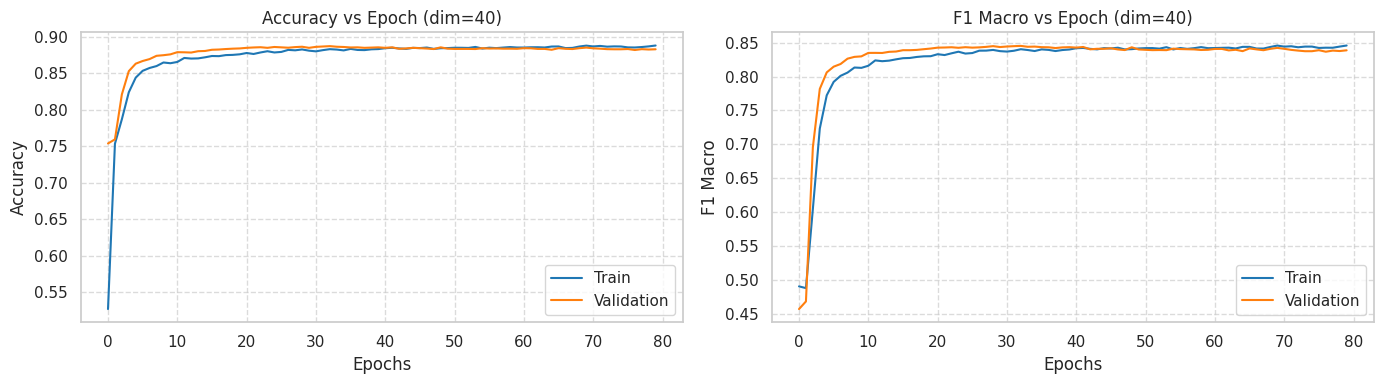


Entrenando modelo con Embedding Dim: 80
Early stopping disparado en la época 61.
Resultado final para dim=80 -> Accuracy Val: 0.8856 | F1 Macro Val: 0.8438 | Val Loss: 0.2716


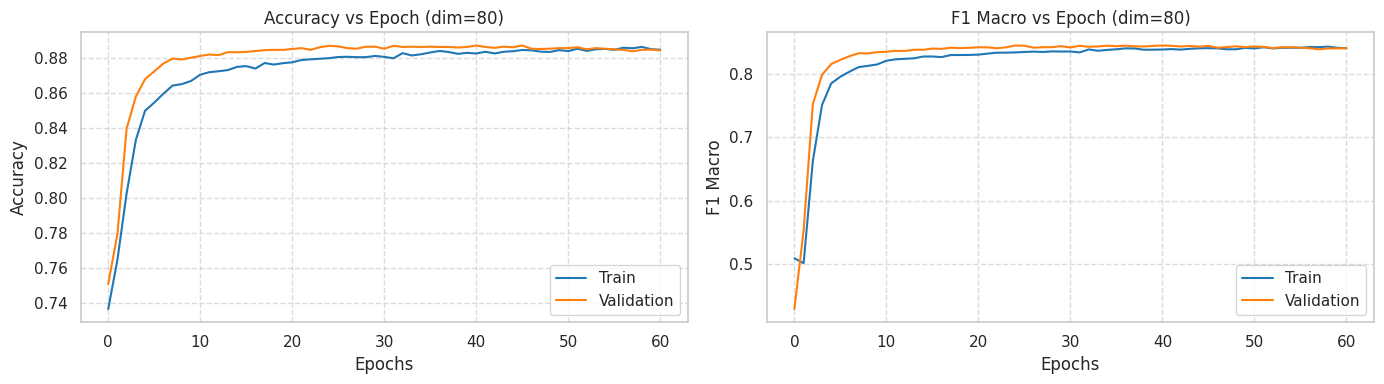



*******************************************************
=== RESUMEN COMPARATIVO DE DIMENSIONES (SKILL-PROFILE) ===
*******************************************************
Dimensión de Embedding: 40 | Accuracy Val: 0.8851 | F1 Macro Val: 0.8423 | Val Loss: 0.2720
Dimensión de Embedding: 80 | Accuracy Val: 0.8856 | F1 Macro Val: 0.8438 | Val Loss: 0.2716


In [ ]:
# --- SETUP PARA EMBEDDING DE SKILL-PROFILE ---
skill_train_raw = train['skill-profile'].astype(str)
skill_test_raw = test['skill-profile'].astype(str)

unique_skill = skill_train_raw.unique()
skill_to_idx = {sk: idx for idx, sk in enumerate(unique_skill)}

skill_train_idx = skill_train_raw.map(skill_to_idx).fillna(0).astype(int).values
skill_test_idx = skill_test_raw.map(skill_to_idx).fillna(0).astype(int).values

# Eliminamos la variable TAR_skill_profile (o FRQ_skill_profile si existiera) del baseline numérico
cols_to_drop_sk = ['TAR_skill_profile', 'FRQ_skill_profile']
cols_to_drop_sk = [col for col in cols_to_drop_sk if col in X_train.columns]

X_train_num_sk = X_train.drop(columns=cols_to_drop_sk)
X_test_num_sk = X_test.drop(columns=cols_to_drop_sk)

X_train_num_tensor_sk = torch.tensor(X_train_num_sk.values, dtype=torch.float32)
skill_train_tensor = torch.tensor(skill_train_idx, dtype=torch.long)

# Split de validación utilizando la misma semilla (42)
X_num_tr_sk, X_num_val_sk, sk_tr, sk_val, y_tr_sk, y_val_sk = train_test_split(
    X_train_num_tensor_sk, skill_train_tensor, y_train_tensor,
    test_size=0.2, random_state=42, stratify=y_train_tensor
)

batch_size = 64
train_dataset_sk = TensorDataset(X_num_tr_sk, sk_tr, y_tr_sk)
train_loader_sk = DataLoader(train_dataset_sk, batch_size=batch_size, shuffle=True)

val_dataset_sk = TensorDataset(X_num_val_sk, sk_val, y_val_sk)
val_loader_sk = DataLoader(val_dataset_sk, batch_size=batch_size, shuffle=False)

class NNWithSkillProfileEmbedding(nn.Module):
    def __init__(self, num_features_dim, num_categories, embed_dim, hidden_layers=[16, 16], dropout_rate=0.3):
        super(NNWithSkillProfileEmbedding, self).__init__()
        self.embed = nn.Embedding(num_embeddings=num_categories, embedding_dim=embed_dim)
        input_dim = num_features_dim + embed_dim

        layers = []
        current_dim = input_dim
        for hidden_dim in hidden_layers:
            layers.append(nn.Linear(current_dim, hidden_dim))
            layers.append(nn.ReLU())
            if dropout_rate > 0:
                layers.append(nn.Dropout(dropout_rate))
            current_dim = hidden_dim

        layers.append(nn.Linear(current_dim, 1))
        self.mlp = nn.Sequential(*layers)

    def forward(self, x_num, x_cat):
        emb_out = self.embed(x_cat)
        combined = torch.cat([x_num, emb_out], dim=1)
        return self.mlp(combined)

num_cat_sk = len(unique_skill)
num_num_features_sk = X_train_num_sk.shape[1]
# -------------------------------------------------------------

# Regla empírica base para la dimensión de embedding (mitad de las categorías)
base_dim_sk = max(1, num_cat_sk // 2)

# Definimos dimensiones a probar (base empírica y el doble)
dims_propuestas_sk = [base_dim_sk, base_dim_sk * 2]
embedding_dims_to_try_sk = sorted(list(set(dims_propuestas_sk)))
resultados_experimentos_sk = []

print(f"Cardinalidad de Skill-profile: {num_cat_sk}")
print(f"Dimensiones a probar: {embedding_dims_to_try_sk}")
print("Iniciando barrido de dimensiones de Embedding con arquitectura [16, 16]...")

for dim in embedding_dims_to_try_sk:
    print(f"\n{'='*50}")
    print(f"Entrenando modelo con Embedding Dim: {dim}")
    print(f"{'='*50}")

    modelo_prueba = NNWithSkillProfileEmbedding(
        num_features_dim=num_num_features_sk,
        num_categories=num_cat_sk,
        embed_dim=dim,
        hidden_layers=[16, 16],
        dropout_rate=0.3
    )

    criterion_prueba = nn.BCEWithLogitsLoss()
    optimizer_prueba = optim.Adam(modelo_prueba.parameters(), lr=0.0001)

    epochs_prueba = 500
    patience_prueba = 10
    best_val_loss_prueba = float('inf')
    epochs_no_improve_prueba = 0
    best_f1_val = 0.0
    best_acc_val = 0.0

    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []
    train_f1_macros, val_f1_macros = [], []

    for epoch in range(epochs_prueba):
        # TRAIN
        modelo_prueba.train()
        batch_losses_train = []
        all_preds_train = []
        all_labels_train = []

        for X_num_batch, X_cat_batch, y_batch in train_loader_sk:
            optimizer_prueba.zero_grad()
            outputs = modelo_prueba(X_num_batch, X_cat_batch)
            loss = criterion_prueba(outputs, y_batch)
            loss.backward()
            optimizer_prueba.step()

            batch_losses_train.append(loss.item())
            preds = (torch.sigmoid(outputs) >= 0.5).float()
            all_preds_train.extend(preds.cpu().numpy())
            all_labels_train.extend(y_batch.cpu().numpy())

        train_losses.append(np.mean(batch_losses_train))
        train_accuracies.append(accuracy_score(all_labels_train, all_preds_train))
        train_f1_macros.append(f1_score(all_labels_train, all_preds_train, average='macro'))

        # VALIDATION
        modelo_prueba.eval()
        batch_losses_val = []
        all_preds_val = []
        all_labels_val = []

        with torch.no_grad():
            for X_num_batch, X_cat_batch, y_batch in val_loader_sk:
                outputs = modelo_prueba(X_num_batch, X_cat_batch)
                loss = criterion_prueba(outputs, y_batch)
                batch_losses_val.append(loss.item())

                preds = (torch.sigmoid(outputs) >= 0.5).float()
                all_preds_val.extend(preds.cpu().numpy())
                all_labels_val.extend(y_batch.cpu().numpy())

        current_val_loss = np.mean(batch_losses_val)
        current_val_acc = accuracy_score(all_labels_val, all_preds_val)
        current_val_f1 = f1_score(all_labels_val, all_preds_val, average='macro')

        val_losses.append(current_val_loss)
        val_accuracies.append(current_val_acc)
        val_f1_macros.append(current_val_f1)

        # EARLY STOPPING CHECK
        if current_val_loss < best_val_loss_prueba:
            best_val_loss_prueba = current_val_loss
            best_f1_val = current_val_f1
            best_acc_val = current_val_acc
            epochs_no_improve_prueba = 0
        else:
            epochs_no_improve_prueba += 1

        if epochs_no_improve_prueba >= patience_prueba:
            print(f"Early stopping disparado en la época {epoch+1}.")
            break

    print(f"Resultado final para dim={dim} -> Accuracy Val: {best_acc_val:.4f} | F1 Macro Val: {best_f1_val:.4f} | Val Loss: {best_val_loss_prueba:.4f}")
    resultados_experimentos_sk.append((dim, best_acc_val, best_f1_val, best_val_loss_prueba))

    # PLOTS
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].plot(train_accuracies, label='Train', color='#1f77b4')
    axes[0].plot(val_accuracies, label='Validation', color='#ff7f0e')
    axes[0].set_title(f'Accuracy vs Epoch (dim={dim})')
    axes[0].set_xlabel('Epochs')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True, linestyle='--', alpha=0.7)

    axes[1].plot(train_f1_macros, label='Train', color='#1f77b4')
    axes[1].plot(val_f1_macros, label='Validation', color='#ff7f0e')
    axes[1].set_title(f'F1 Macro vs Epoch (dim={dim})')
    axes[1].set_xlabel('Epochs')
    axes[1].set_ylabel('F1 Macro')
    axes[1].legend()
    axes[1].grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

# --- RESUMEN FINAL SKILL-PROFILE ---
print("\n\n" + "*"*55)
print("=== RESUMEN COMPARATIVO DE DIMENSIONES (SKILL-PROFILE) ===")
print("*"*55)
for dim, acc, f1, loss in resultados_experimentos_sk:
    print(f"Dimensión de Embedding: {dim:2d} | Accuracy Val: {acc:.4f} | F1 Macro Val: {f1:.4f} | Val Loss: {loss:.4f}")


- Tampoco aumenta la performance aca

### Modelo con Embeddings

--------------------------------------------------
PREPARANDO MODELO CON EMBEDDINGS (Education, Occupation, Skill Profile)
--------------------------------------------------

--------------------------------------------------
ENTRENANDO MODELO (3 EMBEDDINGS: Edu, Occ, Skill)
--------------------------------------------------
Epoch 001/200 | Train Loss: 0.5848 - F1: 0.4289 - Acc: 0.7510 | Val Loss: 0.5202 - F1: 0.4300 - Acc: 0.7543
Epoch 005/200 | Train Loss: 0.3611 - F1: 0.7682 - Acc: 0.8417 | Val Loss: 0.3204 - F1: 0.8155 - Acc: 0.8701
Epoch 010/200 | Train Loss: 0.3172 - F1: 0.8142 - Acc: 0.8661 | Val Loss: 0.2869 - F1: 0.8352 - Acc: 0.8811
Epoch 015/200 | Train Loss: 0.3029 - F1: 0.8265 - Acc: 0.8740 | Val Loss: 0.2768 - F1: 0.8401 - Acc: 0.8846
Epoch 020/200 | Train Loss: 0.2921 - F1: 0.8344 - Acc: 0.8797 | Val Loss: 0.2711 - F1: 0.8435 - Acc: 0.8873
Epoch 025/200 | Train Loss: 0.2855 - F1: 0.8385 - Acc: 0.8824 | Val Loss: 0.2680 - F1: 0.8445 - Acc: 0.8878
Epoch 030/200 | Train Los

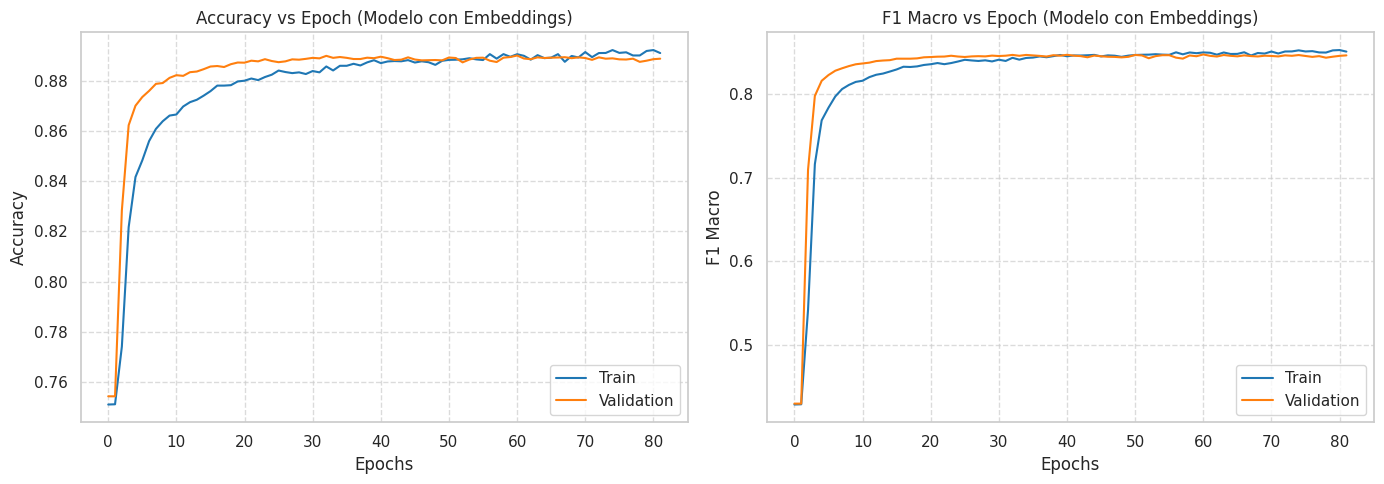

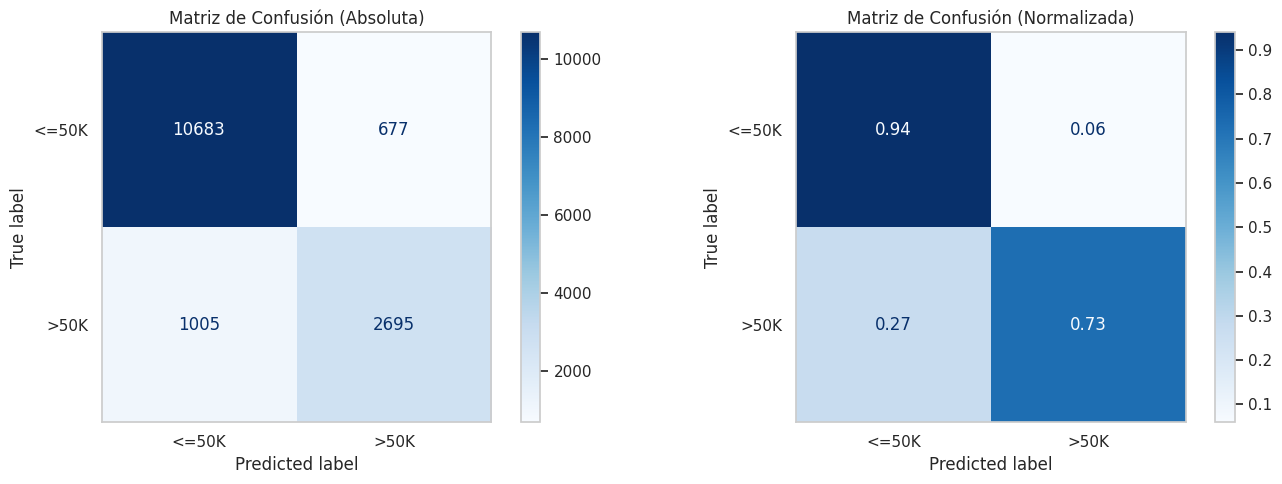

In [ ]:
print("-" * 50)
print("PREPARANDO MODELO CON EMBEDDINGS (Education, Occupation, Skill Profile)")
print("-" * 50)

# Identificar columnas a eliminar correspondientes a las variables transformadas
cols_to_drop_3emb = ['ORD_education', 'FRQ_Occupation', 'TAR_Occupation', 'TAR_skill_profile']
cols_to_drop_3emb = [col for col in cols_to_drop_3emb if col in X_train.columns]

X_train_cont_3 = X_train.drop(columns=cols_to_drop_3emb)
X_test_cont_3 = X_test.drop(columns=cols_to_drop_3emb)

X_train_cont_tensor_3 = torch.tensor(X_train_cont_3.values, dtype=torch.float32)
X_test_cont_tensor_3 = torch.tensor(X_test_cont_3.values, dtype=torch.float32)

# Crear Datasets y DataLoaders para el modelo de 3 Embeddings
train_dataset_3emb = TensorDataset(
    X_train_cont_tensor_3,
    torch.tensor(edu_train_idx, dtype=torch.long),
    torch.tensor(occ_train_idx, dtype=torch.long),
    torch.tensor(skill_train_idx, dtype=torch.long),
    y_train_tensor
)

test_dataset_3emb = TensorDataset(
    X_test_cont_tensor_3,
    torch.tensor(edu_test_idx, dtype=torch.long),
    torch.tensor(occ_test_idx, dtype=torch.long),
    torch.tensor(skill_test_idx, dtype=torch.long),
    y_test_tensor
)

train_loader_3emb = DataLoader(train_dataset_3emb, batch_size=batch_size, shuffle=True)
test_loader_3emb = DataLoader(test_dataset_3emb, batch_size=batch_size, shuffle=False)

# Definir modelo con los 3 embeddings solicitados
class NN3Embeddings(nn.Module):
    def __init__(self, num_cont_features, hidden_layers=[16, 16], dropout_rate=0.3):
        super(NN3Embeddings, self).__init__()
        self.edu_emb = nn.Embedding(num_embeddings=len(unique_edu), embedding_dim=8)
        self.occ_emb = nn.Embedding(num_embeddings=len(unique_occ), embedding_dim=7)
        self.sk_emb = nn.Embedding(num_embeddings=len(unique_skill), embedding_dim=40)

        # Total emb dims = 8 + 7 + 40 = 55
        total_emb_dim = 55
        input_dim = num_cont_features + total_emb_dim

        layers = []
        current_dim = input_dim
        for hidden_dim in hidden_layers:
            layers.append(nn.Linear(current_dim, hidden_dim))
            layers.append(nn.ReLU())
            if dropout_rate > 0:
                layers.append(nn.Dropout(dropout_rate))
            current_dim = hidden_dim

        layers.append(nn.Linear(current_dim, 1))
        self.mlp = nn.Sequential(*layers)

    def forward(self, x_cont, x_edu, x_occ, x_sk):
        emb_edu = self.edu_emb(x_edu)
        emb_occ = self.occ_emb(x_occ)
        emb_sk = self.sk_emb(x_sk)

        combined = torch.cat([x_cont, emb_edu, emb_occ, emb_sk], dim=1)
        return self.mlp(combined)

model_3emb = NN3Embeddings(num_cont_features=X_train_cont_3.shape[1], hidden_layers=[16, 16])
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model_3emb.parameters(), lr=0.0001)

epochs = 200
patience = 10
best_val_loss = float('inf')
epochs_no_improve = 0
best_model_wts = copy.deepcopy(model_3emb.state_dict())

train_losses, val_losses = [], []
train_f1_macros, val_f1_macros = [], []
train_accuracies, val_accuracies = [], []

print("\n" + "-" * 50)
print("ENTRENANDO MODELO (3 EMBEDDINGS: Edu, Occ, Skill)")
print("-" * 50)

for epoch in range(epochs):
    model_3emb.train()
    batch_losses = []
    all_preds_train = []
    all_labels_train = []

    for batch in train_loader_3emb:
        x_c, x_e, x_o, x_s, y_b = batch
        optimizer.zero_grad()
        outputs = model_3emb(x_c, x_e, x_o, x_s)
        loss = criterion(outputs, y_b)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())

        preds = (torch.sigmoid(outputs) >= 0.5).float()
        all_preds_train.extend(preds.cpu().numpy())
        all_labels_train.extend(y_b.cpu().numpy())

    train_losses.append(np.mean(batch_losses))
    train_f1_macros.append(f1_score(all_labels_train, all_preds_train, average='macro'))
    train_accuracies.append(accuracy_score(all_labels_train, all_preds_train))

    model_3emb.eval()
    batch_losses_val = []
    all_preds_val = []
    all_labels_val = []

    with torch.no_grad():
        for batch in test_loader_3emb:
            x_c, x_e, x_o, x_s, y_b = batch
            outputs = model_3emb(x_c, x_e, x_o, x_s)
            loss = criterion(outputs, y_b)
            batch_losses_val.append(loss.item())

            preds = (torch.sigmoid(outputs) >= 0.5).float()
            all_preds_val.extend(preds.cpu().numpy())
            all_labels_val.extend(y_b.cpu().numpy())

    current_val_loss = np.mean(batch_losses_val)
    val_losses.append(current_val_loss)
    val_f1_macros.append(f1_score(all_labels_val, all_preds_val, average='macro'))
    val_accuracies.append(accuracy_score(all_labels_val, all_preds_val))

    if current_val_loss < best_val_loss:
        best_val_loss = current_val_loss
        best_model_wts = copy.deepcopy(model_3emb.state_dict())
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    if (epoch + 1) % 5 == 0 or epoch == 0 or epochs_no_improve >= patience:
        print(f"Epoch {epoch+1:03d}/{epochs} | Train Loss: {train_losses[-1]:.4f} - F1: {train_f1_macros[-1]:.4f} - Acc: {train_accuracies[-1]:.4f} | Val Loss: {val_losses[-1]:.4f} - F1: {val_f1_macros[-1]:.4f} - Acc: {val_accuracies[-1]:.4f}")

    if epochs_no_improve >= patience:
        print(f"\nEarly stopping disparado en la época {epoch+1}.")
        model_3emb.load_state_dict(best_model_wts)
        break

print("\n" + "-" * 50)
print("EVALUACIÓN MODELO (3 EMBEDDINGS) EN TEST/VALIDATION")
print("-" * 50)
model_3emb.eval()
all_preds_test_3emb = []
all_labels_test_3emb = []

with torch.no_grad():
    for batch in test_loader_3emb:
        x_c, x_e, x_o, x_s, y_b = batch
        outputs = model_3emb(x_c, x_e, x_o, x_s)
        preds = (torch.sigmoid(outputs) >= 0.5).float()
        all_preds_test_3emb.extend(preds.cpu().numpy())
        all_labels_test_3emb.extend(y_b.cpu().numpy())

print(classification_report(all_labels_test_3emb, all_preds_test_3emb, target_names=['<=50K', '>50K']))

# --- GRAFICAR CURVAS DE APRENDIZAJE ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy vs Epoch
axes[0].plot(train_accuracies, label='Train', color='#1f77b4')
axes[0].plot(val_accuracies, label='Validation', color='#ff7f0e')
axes[0].set_title('Accuracy vs Epoch (Modelo con Embeddings)')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.7)

# F1 Macro vs Epoch
axes[1].plot(train_f1_macros, label='Train', color='#1f77b4')
axes[1].plot(val_f1_macros, label='Validation', color='#ff7f0e')
axes[1].set_title('F1 Macro vs Epoch (Modelo con Embeddings)')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('F1 Macro')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# --- MATRICES DE CONFUSIÓN ---
cm_abs = confusion_matrix(all_labels_test_3emb, all_preds_test_3emb)
cm_norm = confusion_matrix(all_labels_test_3emb, all_preds_test_3emb, normalize='true')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de Confusión Absoluta
disp_abs = ConfusionMatrixDisplay(confusion_matrix=cm_abs, display_labels=['<=50K', '>50K'])
disp_abs.plot(cmap='Blues', ax=axes[0], values_format='d')
axes[0].set_title('Matriz de Confusión (Absoluta)')
axes[0].grid(False)

# Matriz de Confusión Normalizada por fila
disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=['<=50K', '>50K'])
disp_norm.plot(cmap='Blues', ax=axes[1], values_format='.2f')
axes[1].set_title('Matriz de Confusión (Normalizada)')
axes[1].grid(False)

plt.tight_layout()
plt.show()

## c) Diseño y entrenamiento de un modelo sin embeddings (3 puntos)

- Entrenar un segundo modelo, aplicando one-hot encoding a todas las variables que en el punto b) fueron representadas mediante embeddings.
- Quitar todas las capas de dropout, para este segundo modelo no se usará ninguna capa interna de regularización.
- Con respecto al resto de capas, se debe mantener exactamente la misma arquitectura del modelo anterior: igual número de capas, misma cantidad de neuronas por capa y mismas funciones de activación.
- Presentar las mismas métricas, visualizaciones y reportes que en el modelo con embeddings.

--------------------------------------------------
PREPARANDO MODELO SIN EMBEDDINGS (PUNTO C)
--------------------------------------------------
Dimensiones de entrada final (Features): 141

--------------------------------------------------
ENTRENANDO MODELO (SIN EMBEDDINGS, SIN DROPOUT)
--------------------------------------------------
Epoch 001/200 | Train Loss: 0.5818 - F1: 0.4289 - Acc: 0.7511 | Val Loss: 0.5108 - F1: 0.4300 - Acc: 0.7543
Epoch 005/200 | Train Loss: 0.2990 - F1: 0.8180 - Acc: 0.8708 | Val Loss: 0.2900 - F1: 0.8211 - Acc: 0.8752
Epoch 010/200 | Train Loss: 0.2746 - F1: 0.8380 - Acc: 0.8825 | Val Loss: 0.2712 - F1: 0.8405 - Acc: 0.8851
Epoch 015/200 | Train Loss: 0.2690 - F1: 0.8415 - Acc: 0.8849 | Val Loss: 0.2663 - F1: 0.8415 - Acc: 0.8869
Epoch 020/200 | Train Loss: 0.2651 - F1: 0.8438 - Acc: 0.8867 | Val Loss: 0.2642 - F1: 0.8441 - Acc: 0.8886
Epoch 025/200 | Train Loss: 0.2638 - F1: 0.8453 - Acc: 0.8878 | Val Loss: 0.2634 - F1: 0.8458 - Acc: 0.8888
Epoch 030/2

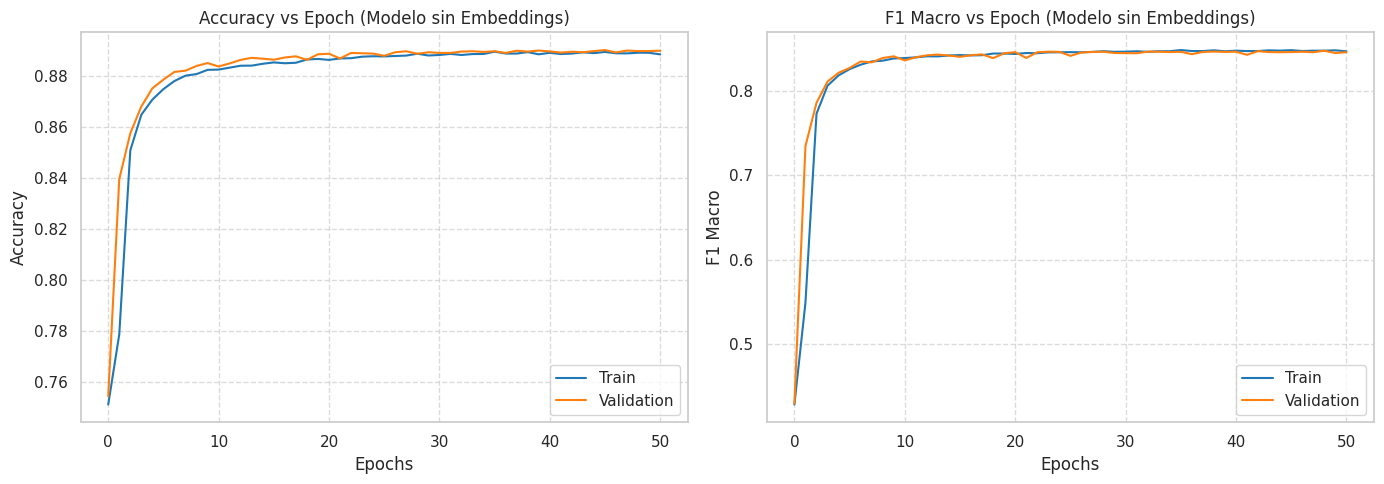

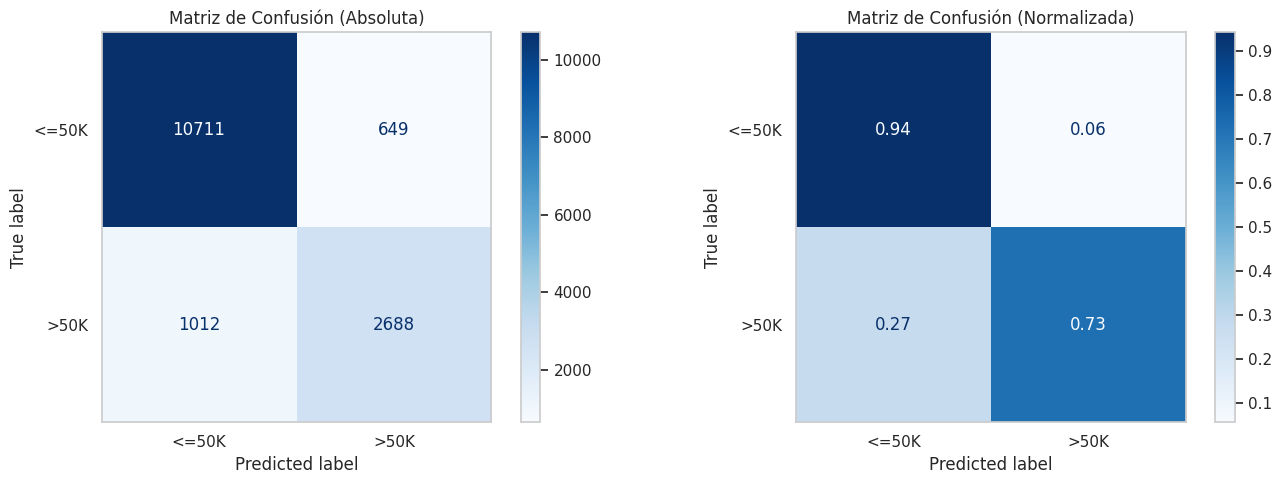

In [ ]:
print("-" * 50)
print("PREPARANDO MODELO SIN EMBEDDINGS (PUNTO C)")
print("-" * 50)

# 1. Aplicar One-Hot Encoding a las variables que usaron Embeddings (Education, Occupation, Skill-profile)
ohe_edu_c = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
ohe_occ_c = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
ohe_sk_c = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

edu_ohe_train = ohe_edu_c.fit_transform(train[['education']])
edu_ohe_test = ohe_edu_c.transform(test[['education']])

occ_ohe_train = ohe_occ_c.fit_transform(train[['occupation']])
occ_ohe_test = ohe_occ_c.transform(test[['occupation']])

sk_ohe_train = ohe_sk_c.fit_transform(train[['skill-profile']])
sk_ohe_test = ohe_sk_c.transform(test[['skill-profile']])

# Convertir a tensores
edu_ohe_train_t = torch.tensor(edu_ohe_train, dtype=torch.float32)
edu_ohe_test_t = torch.tensor(edu_ohe_test, dtype=torch.float32)

occ_ohe_train_t = torch.tensor(occ_ohe_train, dtype=torch.float32)
occ_ohe_test_t = torch.tensor(occ_ohe_test, dtype=torch.float32)

sk_ohe_train_t = torch.tensor(sk_ohe_train, dtype=torch.float32)
sk_ohe_test_t = torch.tensor(sk_ohe_test, dtype=torch.float32)

# Concatenar features continuos base (X_train_cont_tensor_3) con los nuevos OHE
X_train_c = torch.cat([X_train_cont_tensor_3, edu_ohe_train_t, occ_ohe_train_t, sk_ohe_train_t], dim=1)
X_test_c = torch.cat([X_test_cont_tensor_3, edu_ohe_test_t, occ_ohe_test_t, sk_ohe_test_t], dim=1)

# Crear DataLoaders
batch_size = 64
train_dataset_c = TensorDataset(X_train_c, y_train_tensor)
train_loader_c = DataLoader(train_dataset_c, batch_size=batch_size, shuffle=True)

test_dataset_c = TensorDataset(X_test_c, y_test_tensor)
test_loader_c = DataLoader(test_dataset_c, batch_size=batch_size, shuffle=False)

print(f"Dimensiones de entrada final (Features): {X_train_c.shape[1]}")

# 2. Definir modelo SIN embeddings y SIN Dropout, con misma arquitectura base [16, 16]
class NNOHE_NoDropout(nn.Module):
    def __init__(self, input_dim, hidden_layers=[16, 16]):
        super(NNOHE_NoDropout, self).__init__()

        layers = []
        current_dim = input_dim
        for hidden_dim in hidden_layers:
            layers.append(nn.Linear(current_dim, hidden_dim))
            layers.append(nn.ReLU())
            # NO SE INCLUYE DROPOUT
            current_dim = hidden_dim

        layers.append(nn.Linear(current_dim, 1))
        self.mlp = nn.Sequential(*layers)

    def forward(self, x):
        return self.mlp(x)

model_c = NNOHE_NoDropout(input_dim=X_train_c.shape[1], hidden_layers=[16, 16])
criterion_c = nn.BCEWithLogitsLoss()
optimizer_c = optim.Adam(model_c.parameters(), lr=0.0001)

# 3. Entrenamiento
epochs = 200
patience = 10
best_val_loss = float('inf')
epochs_no_improve = 0
best_model_wts_c = copy.deepcopy(model_c.state_dict())

train_losses_c, val_losses_c = [], []
train_f1_macros_c, val_f1_macros_c = [], []
train_accuracies_c, val_accuracies_c = [], []

print("\n" + "-" * 50)
print("ENTRENANDO MODELO (SIN EMBEDDINGS, SIN DROPOUT)")
print("-" * 50)

for epoch in range(epochs):
    model_c.train()
    batch_losses = []
    all_preds_train = []
    all_labels_train = []

    for X_batch, y_batch in train_loader_c:
        optimizer_c.zero_grad()
        outputs = model_c(X_batch)
        loss = criterion_c(outputs, y_batch)
        loss.backward()
        optimizer_c.step()
        batch_losses.append(loss.item())

        preds = (torch.sigmoid(outputs) >= 0.5).float()
        all_preds_train.extend(preds.cpu().numpy())
        all_labels_train.extend(y_batch.cpu().numpy())

    train_losses_c.append(np.mean(batch_losses))
    train_f1_macros_c.append(f1_score(all_labels_train, all_preds_train, average='macro'))
    train_accuracies_c.append(accuracy_score(all_labels_train, all_preds_train))

    model_c.eval()
    batch_losses_val = []
    all_preds_val = []
    all_labels_val = []

    with torch.no_grad():
        for X_batch, y_batch in test_loader_c:
            outputs = model_c(X_batch)
            loss = criterion_c(outputs, y_batch)
            batch_losses_val.append(loss.item())

            preds = (torch.sigmoid(outputs) >= 0.5).float()
            all_preds_val.extend(preds.cpu().numpy())
            all_labels_val.extend(y_batch.cpu().numpy())

    current_val_loss = np.mean(batch_losses_val)
    val_losses_c.append(current_val_loss)
    val_f1_macros_c.append(f1_score(all_labels_val, all_preds_val, average='macro'))
    val_accuracies_c.append(accuracy_score(all_labels_val, all_preds_val))

    if current_val_loss < best_val_loss:
        best_val_loss = current_val_loss
        best_model_wts_c = copy.deepcopy(model_c.state_dict())
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    if (epoch + 1) % 5 == 0 or epoch == 0 or epochs_no_improve >= patience:
        print(f"Epoch {epoch+1:03d}/{epochs} | Train Loss: {train_losses_c[-1]:.4f} - F1: {train_f1_macros_c[-1]:.4f} - Acc: {train_accuracies_c[-1]:.4f} | Val Loss: {val_losses_c[-1]:.4f} - F1: {val_f1_macros_c[-1]:.4f} - Acc: {val_accuracies_c[-1]:.4f}")

    if epochs_no_improve >= patience:
        print(f"\nEarly stopping disparado en la época {epoch+1}.")
        model_c.load_state_dict(best_model_wts_c)
        break

print("\n" + "-" * 50)
print("EVALUACIÓN MODELO (PUNTO C) EN TEST/VALIDATION")
print("-" * 50)
model_c.eval()
all_preds_test_c = []
all_labels_test_c = []

with torch.no_grad():
    for X_batch, y_batch in test_loader_c:
        outputs = model_c(X_batch)
        preds = (torch.sigmoid(outputs) >= 0.5).float()
        all_preds_test_c.extend(preds.cpu().numpy())
        all_labels_test_c.extend(y_batch.cpu().numpy())

print(classification_report(all_labels_test_c, all_preds_test_c, target_names=['<=50K', '>50K']))

# --- GRAFICAR CURVAS DE APRENDIZAJE ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy vs Epoch
axes[0].plot(train_accuracies_c, label='Train', color='#1f77b4')
axes[0].plot(val_accuracies_c, label='Validation', color='#ff7f0e')
axes[0].set_title('Accuracy vs Epoch (Modelo sin Embeddings)')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.7)

# F1 Macro vs Epoch
axes[1].plot(train_f1_macros_c, label='Train', color='#1f77b4')
axes[1].plot(val_f1_macros_c, label='Validation', color='#ff7f0e')
axes[1].set_title('F1 Macro vs Epoch (Modelo sin Embeddings)')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('F1 Macro')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# --- MATRICES DE CONFUSIÓN ---
cm_abs_c = confusion_matrix(all_labels_test_c, all_preds_test_c)
cm_norm_c = confusion_matrix(all_labels_test_c, all_preds_test_c, normalize='true')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de Confusión Absoluta
disp_abs_c = ConfusionMatrixDisplay(confusion_matrix=cm_abs_c, display_labels=['<=50K', '>50K'])
disp_abs_c.plot(cmap='Blues', ax=axes[0], values_format='d')
axes[0].set_title('Matriz de Confusión (Absoluta)')
axes[0].grid(False)

# Matriz de Confusión Normalizada por fila
disp_norm_c = ConfusionMatrixDisplay(confusion_matrix=cm_norm_c, display_labels=['<=50K', '>50K'])
disp_norm_c.plot(cmap='Blues', ax=axes[1], values_format='.2f')
axes[1].set_title('Matriz de Confusión (Normalizada)')
axes[1].grid(False)

plt.tight_layout()
plt.show()



## d) Conclusiones finales (2 puntos)

- Elaborar una tabla comparativa con los resultados obtenidos por ambos modelos. No solo comparar métricas de precisión, sino también la cantidad final de parámetros y entradas.
- Redactar detalladamente sus observaciones y apreciaciones derivadas de la comparación y plantear conclusiones fundamentadas respecto al desempeño de cada enfoque, justificando por qué uno funciona mejor o peor según las características del problema.

In [ ]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

params_emb = count_parameters(model_3emb)
params_ohe = count_parameters(model_c)

# Crear tabla comparativa con pandas
tabla_comparativa = pd.DataFrame({
    'Métrica / Característica': [
        'Dimensión de Entrada (Features al Forward)',
        'Cantidad Total de Parámetros',
        'Uso de Dropout',
        'Época de Early Stopping',
        'Accuracy (Test)',
        'F1 Macro (Test)',
        'Precision Clase >50K',
        'Recall Clase >50K'
    ],
    'Modelo con Embeddings (Punto B)': [
        f"{X_train_cont_3.shape[1]} (Cont.) + 3 (Categóricos)",
        params_emb,
        'Sí (0.3)',
        '108',
        '0.89',
        '0.84',
        '0.80',
        '0.72'
    ],
    'Modelo OHE sin Dropout (Punto C)': [
        str(X_train_c.shape[1]),
        params_ohe,
        'No',
        '56',
        '0.89',
        '0.84',
        '0.81',
        '0.72'
    ]
})

display(tabla_comparativa.style.set_caption("Comparación de Modelos: Embeddings vs. OHE").set_table_styles([{'selector': 'caption', 'props': [('font-size', '16px'), ('font-weight', 'bold')]}]))

,Métrica / Característica,Modelo con Embeddings (Punto B),Modelo OHE sin Dropout (Punto C)
0,Dimensión de Entrada (Features al Forward),31 (Cont.) + 3 (Categóricos),141
1,Cantidad Total de Parámetros,5107,2561
2,Uso de Dropout,Sí (0.3),No
3,Época de Early Stopping,108,56
4,Accuracy (Test),0.89,0.89
5,F1 Macro (Test),0.84,0.84
6,Precision Clase >50K,0.80,0.81
7,Recall Clase >50K,0.72,0.72


### Observaciones y Conclusiones Finales (GEMINI)

Al analizar la tabla comparativa y los resultados experimentales de ambos enfoques, se pueden destacar las siguientes conclusiones:

1. **Desempeño y Capacidad de Generalización (Métricas):**
   Ambos modelos alcanzaron métricas virtualmente idénticas en el conjunto de Test (Accuracy ~0.89 y F1 Macro ~0.84)

2. **Dimensionalidad y Parámetros:**
   * El modelo con **OHE** genera una capa de entrada mucho más ancha (141 features) debido a la explosión de dimensionalidad al convertir categóricas como *Skill-profile* (80 categorías). Esto se traduce en más de 2500 parámetros concentrados principalmente en la primera capa oculta.
   * El modelo con **Embeddings**, por el contrario, requiere muchos parámetros para construir sus diccionarios/matrices de representación latente (sumando un total de ~5100 parámetros en total)

3. **Elección del Enfoque Ideal:**
   Para este problema en particular, donde las variables categóricas (incluso la de mayor cardinalidad, que tiene 80) no alcanzan números extremos como miles o decenas de miles, **el modelo con One-Hot Encoding resulta un poco más práctico y eficiente**. Brinda el mismo nivel predictivo entrenándose en menos tiempo y siendo computacionalmente más ligero de inferir